# Mixed-Precision Quantization Cost Benchmark

Measures the **computational cost** of every layer-importance sensitivity metric across five model/dataset configurations.

**Core idea (Part 1):** report **hardware-independent forward/backward pass counts and FLOPs**, not wall-clock. Wall-clock on small models (ResNet-18 / ViT-B/16) is dominated by Python/I/O noise — the theoretical advantage gets buried. FLOP / forward-pass counting is clean, reproducible, and scales predictably (cf. RobuQ: theoretical arithmetic reduction vs end-to-end wall-clock).

**Categorical claim:** data-free methods require **exactly 0 forward passes**, independent of model size, batch size, or hardware.

## Models
| ID | Architecture | Dataset | Layers |
|---|---|---|---|
| rn_c100 | ResNet-18 (32px conv1) | CIFAR-100 | 21 |
| rn_inet | ResNet-18 (standard) | ImageNet | 21 |
| vit_c100 | ViT-B/16 | CIFAR-100 | 38 |
| vit_inet | ViT-B/16 | ImageNet | 38 |
| qwen | Qwen2-1.5B | WikiText-2 | 196 |

## Methods
| Group | Methods | Forward passes |
|---|---|---|
| Data-free | PCT, Spectral-PCT, SEA, NSDS, OLD, Entropy, Random | **0** |
| Data-required (vision) | HAWQ, InfoQ, BMPQ, CLADO | ≥1 (scales with #layers) |
| Data-required (Qwen) | HAWQ-LM, InfoQ-LM, BMPQ-LM, CLADO-LM | ≥1 (scales with #layers) |

## Parts
- **Part 1 — Allocation cost (pass counts + FLOPs):** analytic fwd/bwd/HVP counts; FLOPs/forward via `thop`; total allocation GFLOPs; ratio vs HAWQ; **scaling extrapolation** to Qwen3-8B/32B using RateQuant published calibration cost (~1.6 s on one GPU, arXiv 2605.06675)
- **Part 2 — Inference-time overhead:** latency / throughput / memory (wall-clock OK for SLAs)
- **Part 3 — Accuracy plots** from existing CSVs + **sensitivity efficiency** (recovery_pp / allocation GFLOPs) + systems Pareto (allocation cost vs accuracy recovery)
- **Part 4 — Calibration robustness:** HAWQ/InfoQ accuracy under matched vs mismatched calibration (ImageNet / CIFAR / noise) + calib-size sweep; data-free methods as invariant control

> No re-quantization sweep for accuracy. Part 1 is **analytic** (plus one FLOP profile per model) — no multi-hour timing loops.


In [68]:
!pip install psutil scipy thop -q


[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [69]:
from __future__ import annotations

import copy
import gc
import os
import sys
import time
import tracemalloc
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from IPython.display import display
from scipy.stats import spearmanr
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 130, 'font.size': 9})

ROOT = Path('.').resolve()
OUT_DIR = ROOT / 'results' / 'mixed_precision_cost_benchmark'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_CIFAR100 = ROOT / 'checkpoints_cifar100'
CKPT_IMAGENET = ROOT / 'checkpoints_imagenet'
QWEN_PATH     = Path('/Users/nathan/qwen1.5b')

# ── Allocation cost (Part 1): FLOPs / pass counts — NOT wall-clock ─────────────
CALIB_BATCH_VISION = 32
CALIB_BATCH_LLM    = 1
LLM_SEQ_LEN        = 256
HAWQ_POWER_STEPS   = 3
CLADO_PAIRS        = 10
HAWQ_LLM_SAMPLE_LAYERS = 20
# First-order backward ≈ 2× forward FLOPs; HVP/create_graph ≈ 4× one forward
BWD_FLOP_MULT = 2.0
HVP_FLOP_MULT = 4.0

# RateQuant published gradient-estimation times (arXiv 2605.06675) —
# used ONLY for scaling illustration, not as our measured result.
RATEQUANT_GRAD_S = {'Qwen3-8B': 1.6, 'Qwen3-32B': 4.2}  # 1.6s published; 4.2s FLOP-scaled estimate
# Rough param counts (billions) for scaling illustrations
PUBLISHED_PARAMS_B = {'Qwen2-1.5B': 1.5, 'Qwen3-8B': 8.0, 'Qwen3-32B': 32.0}

# ── Inference latency (Part 2 — wall-clock OK for production SLAs) ─────────────
N_LATENCY_WARMUP = 5
N_LATENCY_RUNS   = 20
LATENCY_BATCH    = 32
RANDOM_SEED      = 42

RUN_MODELS      = ['rn_c100', 'rn_inet', 'vit_c100', 'vit_inet', 'qwen']
RUN_DATA_REQ    = True
FORCE_RECOMPUTE = False

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f'Device : {DEVICE}')
print(f'Out dir: {OUT_DIR}')
print(f'Models : {RUN_MODELS}')
print('Part 1 metric: PASS COUNTS + FLOPs (hardware-independent)')
print(f'RateQuant refs: {RATEQUANT_GRAD_S}')


Device : mps
Out dir: /Users/nathan/Documents/bruh4/results/mixed_precision_cost_benchmark
Models : ['rn_c100', 'rn_inet', 'vit_c100', 'vit_inet', 'qwen']
Part 1 metric: PASS COUNTS + FLOPs (hardware-independent)
RateQuant refs: {'Qwen3-8B': 1.6, 'Qwen3-32B': 4.2}


In [70]:
# ── Quantization utilities ─────────────────────────────────────────────────────

def per_channel_scale(w2d: torch.Tensor, bits: int) -> torch.Tensor:
    qmax = 2 ** (bits - 1) - 1
    if bits == 1:
        return w2d.abs().max(dim=1, keepdim=True).values.clamp(min=1e-12)
    if bits >= 8:
        return (w2d.abs().max(dim=1, keepdim=True).values / qmax).clamp(min=1e-12)
    clip_val = torch.quantile(w2d.abs(), 0.999, dim=1, keepdim=True).clamp(min=1e-12)
    return (clip_val / qmax).clamp(min=1e-12)


def quantize_weights(w: torch.Tensor, bits: int) -> torch.Tensor:
    qmax = 2 ** (bits - 1) - 1
    w2d  = w.float().reshape(w.shape[0], -1)
    s    = per_channel_scale(w2d, bits)
    q    = (w2d / s).round().clamp(-qmax, qmax)
    return (q * s).reshape(w.shape)


def get_module(model: nn.Module, name: str) -> nn.Module:
    m = model
    for p in name.split('.'):
        m = getattr(m, p)
    return m


def quantize_model_inplace(
    model: nn.Module,
    layer_names: list[str],
    high_layers: set[str],
    bits_high: int = 8,
    bits_low: int  = 4,
) -> nn.Module:
    m = copy.deepcopy(model).cpu()
    with torch.no_grad():
        for n in layer_names:
            bits = bits_high if n in high_layers else bits_low
            mod  = get_module(m, n)
            mod.weight.data = quantize_weights(mod.weight.data, bits).to(mod.weight.dtype)
    return m.eval()


def model_param_mb(model: nn.Module, layer_names: list[str], high_layers: set[str],
                   bits_high: int, bits_low: int) -> float:
    total = sum(get_module(model, n).weight.numel() *
                (bits_high if n in high_layers else bits_low)
                for n in layer_names) / 8 / 1e6
    return total


print('Quantization utilities ready.')


Quantization utilities ready.


In [71]:
# ── Model definitions ──────────────────────────────────────────────────────────

# ResNet-18 (CIFAR variant: 3×3 conv1, no maxpool)
def get_resnet18_cifar(num_classes: int = 100) -> nn.Module:
    m = torchvision.models.resnet18(weights=None, num_classes=num_classes)
    m.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    return m


def load_resnet_cifar100() -> nn.Module:
    m = get_resnet18_cifar(num_classes=100)
    ckpt = CKPT_CIFAR100 / 'resnet18_cifar100_best_valacc.pt'
    if ckpt.exists():
        sd = torch.load(ckpt, map_location='cpu', weights_only=True)
        if isinstance(sd, dict) and 'state_dict' in sd:
            sd = sd['state_dict']
        m.load_state_dict({k: v for k, v in sd.items()
                           if 'quantizer' not in k and 'range_tracker' not in k}, strict=False)
    else:
        print(f'  WARNING: checkpoint not found at {ckpt}, using random weights')
    return m.eval().cpu()


def load_resnet_imagenet() -> nn.Module:
    m = torchvision.models.resnet18(weights=None, num_classes=1000)
    ckpt = CKPT_IMAGENET / 'resnet18_imagenet1k_v1.pt'
    if ckpt.exists():
        sd = torch.load(ckpt, map_location='cpu', weights_only=True)
        if isinstance(sd, dict) and 'state_dict' in sd:
            sd = sd['state_dict']
        m.load_state_dict({k: v for k, v in sd.items()
                           if 'quantizer' not in k}, strict=False)
    else:
        print(f'  WARNING: checkpoint not found at {ckpt}, using random weights')
    return m.eval().cpu()


def _load_vit_b16_base() -> nn.Module:
    cache = CKPT_IMAGENET / 'vit_b16_imagenet1k_v1.pt'
    m = torchvision.models.vit_b_16(weights=None)
    if cache.exists():
        m.load_state_dict(torch.load(cache, map_location='cpu', weights_only=True), strict=False)
    else:
        print('  INFO: Downloading ViT-B/16 ImageNet weights...')
        base = torchvision.models.vit_b_16(
            weights=torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1)
        torch.save(base.state_dict(), cache)
        m.load_state_dict(base.state_dict(), strict=False)
    return m


def load_vit_cifar100() -> nn.Module:
    m = _load_vit_b16_base()
    m.heads.head = nn.Linear(m.heads.head.in_features, 100)
    ckpt = CKPT_CIFAR100 / 'vit_b16_cifar100_best_valacc.pt'
    if ckpt.exists():
        sd = torch.load(ckpt, map_location='cpu', weights_only=True)
        if isinstance(sd, dict) and 'state_dict' in sd:
            sd = sd['state_dict']
        m.load_state_dict(sd, strict=False)
    else:
        print(f'  WARNING: checkpoint not found at {ckpt}')
    return m.eval().cpu()


def load_vit_imagenet() -> nn.Module:
    m = _load_vit_b16_base()
    return m.eval().cpu()


# ── Layer name lists ────────────────────────────────────────────────────────────
RN_LAYER_NAMES = [
    'conv1',
    'layer1.0.conv1', 'layer1.0.conv2', 'layer1.1.conv1', 'layer1.1.conv2',
    'layer2.0.conv1', 'layer2.0.conv2', 'layer2.0.downsample.0',
    'layer2.1.conv1', 'layer2.1.conv2',
    'layer3.0.conv1', 'layer3.0.conv2', 'layer3.0.downsample.0',
    'layer3.1.conv1', 'layer3.1.conv2',
    'layer4.0.conv1', 'layer4.0.conv2', 'layer4.0.downsample.0',
    'layer4.1.conv1', 'layer4.1.conv2', 'fc',
]

VIT_LAYER_NAMES = (
    ['conv_proj']
    + [f'encoder.layers.encoder_layer_{b}.self_attention.out_proj' for b in range(12)]
    + [f'encoder.layers.encoder_layer_{b}.mlp.0' for b in range(12)]
    + [f'encoder.layers.encoder_layer_{b}.mlp.3' for b in range(12)]
    + ['heads.head']
)

def get_qwen_layer_names(model: nn.Module) -> list[str]:
    keys = ('self_attn.q_proj', 'self_attn.k_proj', 'self_attn.v_proj', 'self_attn.o_proj',
            'mlp.gate_proj', 'mlp.up_proj', 'mlp.down_proj')
    return sorted([n for n, m in model.named_modules()
                   if isinstance(m, nn.Linear) and '.layers.' in n and any(k in n for k in keys)])


def load_qwen():
    try:
        from transformers import AutoModelForCausalLM
        m = AutoModelForCausalLM.from_pretrained(
            str(QWEN_PATH), trust_remote_code=True, torch_dtype=torch.float16)
        return m.eval().cpu()
    except Exception as e:
        print(f'  WARNING: could not load Qwen: {e}')
        return None


print('Model definitions ready.')
print(f'  ResNet layers: {len(RN_LAYER_NAMES)}')
print(f'  ViT-B/16 layers: {len(VIT_LAYER_NAMES)}')


Model definitions ready.
  ResNet layers: 21
  ViT-B/16 layers: 38


In [72]:
# ── Scoring functions ──────────────────────────────────────────────────────────

def _svdvals_cpu(w2d: torch.Tensor) -> torch.Tensor:
    return torch.linalg.svdvals(w2d.detach().float().cpu())


def _pct_score_layer(weight: torch.Tensor) -> tuple[float, float]:
    qmax = 127
    w    = weight.float().reshape(weight.shape[0], -1)
    s    = per_channel_scale(w, 8)
    pct  = float((w - (w / s).round().clamp(-qmax, qmax) * s).norm('fro') / (w.norm('fro') + 1e-12))
    s2   = (w.abs().max() / qmax).clamp(min=1e-12)
    old  = float((w - (w / s2).round().clamp(-qmax, qmax) * s2).norm('fro') / (w.norm('fro') + 1e-12))
    return pct, old


def _entropy_layer(weight: torch.Tensor) -> float:
    w = weight.detach().float().reshape(-1).cpu().numpy()
    cnt, _ = np.histogram(w, bins=256)
    p = cnt.astype(np.float64) / max(cnt.sum(), 1)
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())


def _sea_layer(weight: torch.Tensor, eps: float = 1e-8) -> float:
    w  = weight.detach().float().reshape(weight.shape[0], -1)
    try:
        S = _svdvals_cpu(w)
    except Exception:
        return 0.0
    S2 = S.pow(2)
    p  = (S2 / S2.sum().clamp(min=eps)).clamp(min=1e-12)
    return 1.0 / max(float(-(p * p.log()).sum()), eps)


def _effective_rank(weight: torch.Tensor) -> float:
    w2d = weight.float().reshape(weight.shape[0], -1)
    s   = _svdvals_cpu(w2d)
    if s.sum() < 1e-12:
        return 1.0
    p = (s / s.sum()).clamp(min=1e-12)
    return float(torch.exp(-(p * p.log()).sum()).item())


def _kurtosis(weight: torch.Tensor) -> float:
    x = weight.reshape(-1).float()
    mu, sig2 = x.mean(), x.var(unbiased=False)
    if sig2 < 1e-12:
        return 0.0
    return float((((x - mu) ** 4).mean() / (sig2 ** 2) - 3.0).item())


def _spectral_pct_layer(weight: torch.Tensor) -> float:
    w2d = weight.detach().float().reshape(weight.shape[0], -1).cpu()
    a   = w2d.abs().reshape(-1)
    pct = float(torch.quantile(a, 0.99) - torch.quantile(a, 0.01))
    return pct * float(_svdvals_cpu(w2d)[0])


# ── Full-model score passes (what gets timed) ──────────────────────────────────

def score_pct(model, layer_names):
    return {n: _pct_score_layer(get_module(model, n).weight)[0] for n in layer_names}


def score_old(model, layer_names):
    return {n: _pct_score_layer(get_module(model, n).weight)[1] for n in layer_names}


def score_entropy(model, layer_names):
    return {n: _entropy_layer(get_module(model, n).weight) for n in layer_names}


def score_sea(model, layer_names):
    return {n: _sea_layer(get_module(model, n).weight) for n in layer_names}


def score_nsds(model, layer_names):
    return {n: _kurtosis(get_module(model, n).weight) * _effective_rank(get_module(model, n).weight)
            for n in layer_names}


def score_spectral_pct(model, layer_names):
    return {n: _spectral_pct_layer(get_module(model, n).weight) for n in layer_names}


def score_random(model, layer_names):
    rng  = np.random.default_rng(RANDOM_SEED)
    vals = np.zeros(len(layer_names))
    for _ in range(3):
        vals += rng.permutation(len(layer_names)).astype(float)
    return dict(zip(layer_names, vals / 3))


# ── Data-required scorers ──────────────────────────────────────────────────────

def _patch_maxpool(model: nn.Module) -> None:
    for name, child in model.named_children():
        if isinstance(child, nn.MaxPool2d):
            setattr(model, name, nn.AvgPool2d(
                child.kernel_size, stride=child.stride,
                padding=child.padding, ceil_mode=child.ceil_mode))
        else:
            _patch_maxpool(child)


def score_hawq(model, layer_names, calib_loader, power_steps=HAWQ_POWER_STEPS):
    hw = torch.device('cpu') if DEVICE.type == 'mps' else DEVICE
    x, y = next(iter(calib_loader))
    x, y = x.to(hw), y.to(hw)
    m = copy.deepcopy(model).to(hw).train()
    _patch_maxpool(m)
    out = {}
    ctx = (lambda: __import__('torch.nn.attention', fromlist=['sdpa_kernel', 'SDPBackend']))
    try:
        from torch.nn.attention import sdpa_kernel, SDPBackend
        attn_ctx = sdpa_kernel(SDPBackend.MATH)
    except Exception:
        import contextlib
        attn_ctx = contextlib.nullcontext()
    with attn_ctx:
        for n in layer_names:
            w = get_module(m, n).weight
            v = torch.randn_like(w)
            v /= (v.norm() + 1e-12)
            for _ in range(power_steps):
                for p in m.parameters():
                    p.grad = None
                loss = F.cross_entropy(m(x), y)
                g    = torch.autograd.grad(loss, w, create_graph=True)[0]
                hv   = torch.autograd.grad((g * v).sum(), w, retain_graph=True)[0]
                v    = hv / (hv.norm() + 1e-12)
            for p in m.parameters():
                p.grad = None
            loss = F.cross_entropy(m(x), y)
            g    = torch.autograd.grad(loss, w, create_graph=True)[0]
            hv   = torch.autograd.grad((g * v).sum(), w)[0]
            out[n] = float((v * hv).sum().abs().item())
    del m
    return out


def score_infoq(model, layer_names, calib_loader):
    x, _ = next(iter(calib_loader))
    x    = x.to(DEVICE)
    base = copy.deepcopy(model).to(DEVICE).eval()
    with torch.no_grad():
        y0 = base(x)
    out = {}
    for n in layer_names:
        mq = quantize_model_inplace(model, layer_names,
                                    high_layers=set(layer_names) - {n},
                                    bits_high=8, bits_low=4).to(DEVICE).eval()
        with torch.no_grad():
            yq  = mq(x)
            cos = F.cosine_similarity(y0.flatten(1), yq.flatten(1), dim=1).mean().item()
        out[n] = 1.0 - cos
    return out


def score_bmpq(model, layer_names, calib_loader):
    x, y = next(iter(calib_loader))
    x, y = x.to(DEVICE), y.to(DEVICE)
    m    = copy.deepcopy(model).to(DEVICE).train()
    for p in m.parameters():
        p.grad = None
    F.cross_entropy(m(x), y).backward()
    out = {}
    for n in layer_names:
        w = get_module(m, n).weight
        g = torch.zeros_like(w) if w.grad is None else w.grad
        out[n] = float((g.abs() * w.abs()).mean().item())
    return out


def score_clado(model, layer_names, calib_loader, n_pairs=CLADO_PAIRS):
    x, y = next(iter(calib_loader))
    x, y = x.to(DEVICE), y.to(DEVICE)
    base  = copy.deepcopy(model).to(DEVICE).eval()
    with torch.no_grad():
        l0 = F.cross_entropy(base(x), y).item()
    single = {}
    for n in layer_names:
        mq = quantize_model_inplace(model, layer_names,
                                    high_layers=set(layer_names) - {n},
                                    bits_high=8, bits_low=4).to(DEVICE).eval()
        with torch.no_grad():
            single[n] = F.cross_entropy(mq(x), y).item() - l0
    rng   = np.random.default_rng(RANDOM_SEED)
    pairs = [tuple(rng.choice(layer_names, size=2, replace=False))
             for _ in range(min(n_pairs, max(1, len(layer_names) // 2)))]
    gain_sum = defaultdict(float)
    gain_cnt = defaultdict(int)
    for a, b in pairs:
        mq = quantize_model_inplace(model, layer_names,
                                    high_layers=set(layer_names) - {a, b},
                                    bits_high=8, bits_low=4).to(DEVICE).eval()
        with torch.no_grad():
            pair_loss = F.cross_entropy(mq(x), y).item() - l0
        synergy = pair_loss - (single.get(a, 0) + single.get(b, 0))
        for nm in (a, b):
            gain_sum[nm] += synergy * 0.5
            gain_cnt[nm] += 1
    return {n: single[n] + gain_sum.get(n, 0) / max(gain_cnt.get(n, 1), 1) for n in layer_names}


# ── LLM (Qwen) variants of data-required scorers ──────────────────────────────
# Key design: NEVER deep-copy the full LLM (3 GB+).
# Instead, quantize/restore one layer's weights in-place per iteration.
# calib_loader yields (input_ids, labels).

def _lm_loss(model: nn.Module, input_ids: torch.Tensor) -> torch.Tensor:
    """Scalar LM CE loss for any HuggingFace CausalLM."""
    return model(input_ids=input_ids, labels=input_ids).loss


# HAWQ-LM: subsample layers for large models to bound runtime.
# For L=196 layers, full HAWQ takes hours; we score HAWQ_LLM_SAMPLE_LAYERS
# representative layers then extrapolate timing (score values still reported).
HAWQ_LLM_SAMPLE_LAYERS = 20   # number of Qwen layers to actually score
LLM_CALIB_BATCH = 1           # batch size for 2nd-order (memory-critical)
LLM_CALIB_SEQ   = 64          # shorter seq for 2nd-order on LLMs


def score_hawq_lm(model, layer_names, calib_loader, power_steps=HAWQ_POWER_STEPS):
    """HAWQ with LM loss. Scores a random sample of layers; rest get NaN.
    Wall-clock time is measured on the sample and linearly extrapolated.
    """
    hw  = torch.device('cpu')   # always CPU: MPS has no double-backward
    rng = np.random.default_rng(RANDOM_SEED)
    sample = list(rng.choice(layer_names, size=min(HAWQ_LLM_SAMPLE_LAYERS, len(layer_names)),
                              replace=False))
    ids = torch.randint(0, 151936, (LLM_CALIB_BATCH, LLM_CALIB_SEQ)).to(hw)
    m   = copy.deepcopy(model).to(hw).float().train()   # float32 for 2nd-order
    out = {n: float('nan') for n in layer_names}
    try:
        from torch.nn.attention import sdpa_kernel, SDPBackend
        attn_ctx = sdpa_kernel(SDPBackend.MATH)
    except Exception:
        import contextlib
        attn_ctx = contextlib.nullcontext()
    with attn_ctx:
        for n in sample:
            w = get_module(m, n).weight
            v = torch.randn_like(w)
            v /= (v.norm() + 1e-12)
            for _ in range(power_steps):
                for p in m.parameters(): p.grad = None
                g  = torch.autograd.grad(_lm_loss(m, ids), w, create_graph=True)[0]
                hv = torch.autograd.grad((g * v).sum(), w, retain_graph=True)[0]
                v  = hv / (hv.norm() + 1e-12)
            for p in m.parameters(): p.grad = None
            g  = torch.autograd.grad(_lm_loss(m, ids), w, create_graph=True)[0]
            hv = torch.autograd.grad((g * v).sum(), w)[0]
            out[n] = float((v * hv).sum().abs().item())
    del m
    return out


def score_infoq_lm(model, layer_names, calib_loader):
    """InfoQ-LM: in-place quantize one layer, measure cosine disruption, restore.
    No full model copies — uses save/restore of a single layer's weights at a time.
    """
    ids, _ = next(iter(calib_loader))
    ids = ids[:min(2, len(ids))].to(DEVICE)
    m   = model.to(DEVICE).eval()
    with torch.no_grad():
        y0 = m(input_ids=ids).logits   # (B, T, V)
    out = {}
    for n in layer_names:
        mod    = get_module(m, n)
        orig_w = mod.weight.data.clone()
        mod.weight.data = quantize_weights(orig_w, 4).to(orig_w.dtype)
        with torch.no_grad():
            yq = m(input_ids=ids).logits
        cos = F.cosine_similarity(
            y0.float().reshape(-1, y0.shape[-1]),
            yq.float().reshape(-1, yq.shape[-1]),
            dim=1,
        ).mean().item()
        out[n] = 1.0 - cos
        mod.weight.data = orig_w   # restore
    return out


def score_bmpq_lm(model, layer_names, calib_loader):
    """BMPQ-LM: single backward pass, Fisher |G|·|W|. No model copies needed."""
    ids, _ = next(iter(calib_loader))
    ids = ids[:min(2, len(ids))].to(DEVICE)
    m   = model.to(DEVICE).train()
    for p in m.parameters(): p.grad = None
    _lm_loss(m, ids).backward()
    out = {}
    for n in layer_names:
        w = get_module(m, n).weight
        g = torch.zeros_like(w) if w.grad is None else w.grad
        out[n] = float((g.abs() * w.float().abs()).mean().item())
    for p in m.parameters(): p.grad = None
    m.eval()
    return out


def score_clado_lm(model, layer_names, calib_loader, n_pairs=CLADO_PAIRS):
    """CLADO-LM: start from all-INT4 baseline, restore one layer at a time.
    No full model copies — quantizes model once, then saves/restores per layer.
    """
    ids, _ = next(iter(calib_loader))
    ids = ids[:min(2, len(ids))].to(DEVICE)
    m   = model.to(DEVICE).eval()

    # Save originals + quantize all to INT4
    orig = {n: get_module(m, n).weight.data.clone() for n in layer_names}
    with torch.no_grad():
        for n in layer_names:
            mod = get_module(m, n)
            mod.weight.data = quantize_weights(orig[n], 4).to(orig[n].dtype)
        l_all4 = float(_lm_loss(m, ids).item())

    # For each layer: temporarily restore FP, measure improvement
    single = {}
    with torch.no_grad():
        for n in layer_names:
            mod = get_module(m, n)
            mod.weight.data = orig[n]
            single[n] = l_all4 - float(_lm_loss(m, ids).item())  # positive = layer matters
            mod.weight.data = quantize_weights(orig[n], 4).to(orig[n].dtype)

    # Pairwise synergy on a random subset
    rng   = np.random.default_rng(RANDOM_SEED)
    pairs = [tuple(rng.choice(layer_names, size=2, replace=False))
             for _ in range(min(n_pairs, max(1, len(layer_names) // 2)))]
    gain_sum = defaultdict(float)
    gain_cnt = defaultdict(int)
    with torch.no_grad():
        for a, b in pairs:
            for n in (a, b):
                get_module(m, n).weight.data = orig[n]
            pair_loss = l_all4 - float(_lm_loss(m, ids).item())
            synergy   = pair_loss - (single.get(a, 0) + single.get(b, 0))
            for n in (a, b):
                gain_sum[n] += synergy * 0.5
                gain_cnt[n] += 1
                get_module(m, n).weight.data = quantize_weights(orig[n], 4).to(orig[n].dtype)

    # Restore all to FP
    for n in layer_names:
        get_module(m, n).weight.data = orig[n]

    return {n: single[n] + gain_sum.get(n, 0) / max(gain_cnt.get(n, 1), 1)
            for n in layer_names}


print('Scoring functions ready.')
print('  Data-free       : pct, old, entropy, sea, nsds, spectral_pct, random')
print('  Data-req (vision): hawq, infoq, bmpq, clado  (fake image calibration)')
print('  Data-req (LLM)  : hawq_lm, infoq_lm, bmpq_lm, clado_lm  (in-place, no model copies)')


Scoring functions ready.
  Data-free       : pct, old, entropy, sea, nsds, spectral_pct, random
  Data-req (vision): hawq, infoq, bmpq, clado  (fake image calibration)
  Data-req (LLM)  : hawq_lm, infoq_lm, bmpq_lm, clado_lm  (in-place, no model copies)


In [73]:
# ── Memory measurement helpers ─────────────────────────────────────────────────

def _proc_rss_mb() -> float:
    return psutil.Process().memory_info().rss / 1e6


def _torch_device_mb() -> float:
    if DEVICE.type == 'cuda':
        return torch.cuda.memory_allocated() / 1e6
    if DEVICE.type == 'mps':
        return torch.mps.current_allocated_memory() / 1e6
    return 0.0


class PeakMemTracker:
    """Context manager: records peak RSS + device memory during a block.
    Attributes (total_peak_mb etc.) are only available AFTER the with-block exits.
    """
    def __enter__(self):
        gc.collect()
        self._rss_before = _proc_rss_mb()
        self._dev_before = _torch_device_mb()
        tracemalloc.start()
        return self

    def __exit__(self, *_):
        _, peak_py = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        self.peak_python_mb = peak_py / 1e6
        self.rss_delta_mb   = max(_proc_rss_mb() - self._rss_before, 0)
        self.dev_delta_mb   = max(_torch_device_mb() - self._dev_before, 0)
        self.total_peak_mb  = max(self.peak_python_mb, self.rss_delta_mb) + self.dev_delta_mb


def peak_mem_fn(fn, *args) -> float:
    """Run fn(*args) once and return peak memory in MB (safe: reads after __exit__)."""
    gc.collect()
    tracker = PeakMemTracker()
    with tracker:
        fn(*args)
    return tracker.total_peak_mb


def _sync_device():
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    elif DEVICE.type == 'mps':
        torch.mps.synchronize()


print('Memory tracking ready.')


Memory tracking ready.


In [74]:
# ── Model registry ─────────────────────────────────────────────────────────────
# Each entry: (label, loader_fn, layer_names, is_llm, input_shape, acc_csv_rn, acc_csv_vit)
#   is_llm    — skip data-required scoring; use token input for latency
#   input_shape — (C, H, W) for vision; (seq_len,) for LLM

MODEL_REGISTRY = {
    'rn_c100' : dict(
        label='ResNet / CIFAR-100',
        loader=load_resnet_cifar100,
        layer_names=RN_LAYER_NAMES,
        is_llm=False,
        input_shape=(3, 32, 32),
        n_classes=100,
        acc_csv=ROOT / 'results' / 'cifar100_layer_importance_benchmark' / 'resnet_cifar100_benchmark_results.csv',
    ),
    'rn_inet' : dict(
        label='ResNet / ImageNet',
        loader=load_resnet_imagenet,
        layer_names=RN_LAYER_NAMES,
        is_llm=False,
        input_shape=(3, 224, 224),
        n_classes=1000,
        acc_csv=ROOT / 'results' / 'imagenet_layer_importance_benchmark' / 'resnet_imagenet_benchmark_results.csv',
    ),
    'vit_c100': dict(
        label='ViT-B/16 / CIFAR-100',
        loader=load_vit_cifar100,
        layer_names=VIT_LAYER_NAMES,
        is_llm=False,
        input_shape=(3, 224, 224),
        n_classes=100,
        acc_csv=ROOT / 'results' / 'cifar100_layer_importance_benchmark' / 'vit_cifar100_benchmark_results.csv',
    ),
    'vit_inet': dict(
        label='ViT-B/16 / ImageNet',
        loader=load_vit_imagenet,
        layer_names=VIT_LAYER_NAMES,
        is_llm=False,
        input_shape=(3, 224, 224),
        n_classes=1000,
        acc_csv=ROOT / 'results' / 'imagenet_layer_importance_benchmark' / 'vit_imagenet_benchmark_results.csv',
    ),
    'qwen'    : dict(
        label='Qwen2-1.5B',
        loader=load_qwen,
        layer_names=None,         # discovered dynamically after loading
        is_llm=True,
        input_shape=(LLM_SEQ_LEN,),
        n_classes=None,
        acc_csv=ROOT / 'results' / 'qwen_wikitext2_quant' / 'qwen_wikitext2_benchmark_results.csv',
    ),
}
# NOTE: data-required methods run on ALL models.
# Vision models → score_{hawq,infoq,bmpq,clado}  (image classification loss)
# Qwen LLM      → score_{hawq,infoq,bmpq,clado}_lm (LM cross-entropy loss)

DATA_FREE_METHODS = [
    ('pct',          score_pct),
    ('spectral_pct', score_spectral_pct),
    ('sea',          score_sea),
    ('nsds',         score_nsds),
    ('old',          score_old),
    ('entropy',      score_entropy),
    ('random',       score_random),
]

DATA_REQ_METHODS = ['hawq', 'infoq', 'bmpq', 'clado']

METHOD_COLORS = {
    'pct'         : '#e6194b',
    'spectral_pct': '#008080',
    'sea'         : '#f58231',
    'nsds'        : '#bfef45',
    'old'         : '#3cb44b',
    'entropy'     : '#4363d8',
    'random'      : '#aaaaaa',
    'hawq'        : '#911eb4',
    'infoq'       : '#42d4f4',
    'bmpq'        : '#f032e6',
    'clado'       : '#469990',
}

print('Registry loaded — models to benchmark:', list(MODEL_REGISTRY.keys()))


Registry loaded — models to benchmark: ['rn_c100', 'rn_inet', 'vit_c100', 'vit_inet', 'qwen']


In [75]:
# ═══════════════════════════════════════════════════════════════════════════════
# PART 1 — Allocation cost: FORWARD-PASS COUNTS + FLOPs (not wall-clock)
#
# Analytic accounting of what each scorer does. Data-free methods are exactly 0
# forward passes — a categorical difference, not a timing margin.
# One thop profile per model → FLOPs/forward; total allocation FLOPs follow.
# ═══════════════════════════════════════════════════════════════════════════════

COST_CSV = OUT_DIR / 'part1_allocation_flops.csv'
FLOP_PROFILE_CSV = OUT_DIR / 'part1_flops_per_forward.csv'

DATA_FREE_NAMES = [m for m, _ in DATA_FREE_METHODS]


def count_passes(method: str, n_layers: int, is_llm: bool = False) -> dict:
    """Hardware-independent pass counts for one scoring run."""
    if method in DATA_FREE_NAMES:
        return dict(n_forward=0, n_backward=0, n_hvp=0, note='weight-only; zero network passes')

    if method == 'bmpq':
        return dict(n_forward=1, n_backward=1, n_hvp=0, note='Fisher |G|·|W|')

    if method == 'infoq':
        return dict(n_forward=1 + n_layers, n_backward=0, n_hvp=0,
                    note=f'1 baseline + {n_layers} per-layer forwards')

    if method == 'clado':
        nf = 1 + n_layers + CLADO_PAIRS
        return dict(n_forward=nf, n_backward=0, n_hvp=0,
                    note=f'1 + {n_layers} singles + {CLADO_PAIRS} pairs')

    if method == 'hawq':
        L = HAWQ_LLM_SAMPLE_LAYERS if is_llm else n_layers
        iters = HAWQ_POWER_STEPS + 1
        return dict(
            n_forward=L * iters,
            n_backward=0,
            n_hvp=L * iters,
            note=f'{L} layers × {iters} power-iters (HVP)',
        )

    raise ValueError(method)


def equiv_forward_units(n_forward: int, n_backward: int, n_hvp: int) -> float:
    """Map mixed pass types to forward-equivalent units for ratio display."""
    return float(n_forward + BWD_FLOP_MULT * n_backward + HVP_FLOP_MULT * n_hvp)


def profile_flops_per_forward(model: nn.Module, cfg: dict) -> float:
    """FLOPs for one forward at the calibration batch / seq used by scorers."""
    try:
        from thop import profile as thop_profile
    except ImportError:
        print('  thop missing — param-count proxy 2×N_params')
        return float(2 * sum(p.numel() for p in model.parameters()))

    m = copy.deepcopy(model).cpu().eval()
    try:
        if cfg['is_llm']:
            x = torch.randint(0, 151936, (CALIB_BATCH_LLM, LLM_SEQ_LEN))
            try:
                flops, _ = thop_profile(m, inputs=(x,), verbose=False)
            except Exception:
                flops = float(2 * sum(p.numel() for p in m.parameters()) * LLM_SEQ_LEN * CALIB_BATCH_LLM)
        else:
            x = torch.randn(CALIB_BATCH_VISION, *cfg['input_shape'])
            flops, _ = thop_profile(m, inputs=(x,), verbose=False)
    finally:
        del m
        gc.collect()
    return float(flops)


def allocation_gflops(flops_fwd: float, n_forward: int, n_backward: int, n_hvp: int) -> float:
    total = (
        n_forward * flops_fwd
        + n_backward * BWD_FLOP_MULT * flops_fwd
        + n_hvp * HVP_FLOP_MULT * flops_fwd
    )
    return total / 1e9


# ── Per-model FLOP profile (cached) ────────────────────────────────────────────
if FLOP_PROFILE_CSV.exists() and not FORCE_RECOMPUTE:
    flop_profile = pd.read_csv(FLOP_PROFILE_CSV)
    print(f'Loaded FLOP profiles → {FLOP_PROFILE_CSV.name}')
else:
    flop_profile = pd.DataFrame()

new_fp = []
for model_id in RUN_MODELS:
    if len(flop_profile) and model_id in set(flop_profile['model_id'].astype(str)):
        continue
    cfg = MODEL_REGISTRY[model_id]
    print(f'Profiling FLOPs/forward: {cfg["label"]}...', flush=True)
    model = cfg['loader']()
    if model is None:
        print('  SKIPPED')
        continue
    layer_names = cfg['layer_names']
    if layer_names is None:
        layer_names = get_qwen_layer_names(model)
        MODEL_REGISTRY[model_id]['layer_names'] = layer_names
    n_params = sum(get_module(model, n).weight.numel() for n in layer_names)
    flops = profile_flops_per_forward(model, cfg)
    new_fp.append(dict(
        model_id=model_id,
        model_label=cfg['label'],
        n_layers=len(layer_names),
        n_params_m=round(n_params / 1e6, 2),
        flops_per_forward=flops,
        gflops_per_forward=round(flops / 1e9, 4),
        is_llm=cfg['is_llm'],
    ))
    print(f'  → {flops/1e9:.3f} GFLOPs / forward')
    del model
    gc.collect()

if new_fp:
    flop_profile = (
        pd.concat([flop_profile, pd.DataFrame(new_fp)], ignore_index=True)
        if len(flop_profile) else pd.DataFrame(new_fp)
    )
    flop_profile = flop_profile.drop_duplicates('model_id', keep='last')
    flop_profile.to_csv(FLOP_PROFILE_CSV, index=False)

display(flop_profile.round(4))


# ── Analytic pass-count table for every method × model ─────────────────────────
cost_rows = []
all_methods = DATA_FREE_NAMES + (['bmpq', 'infoq', 'clado', 'hawq'] if RUN_DATA_REQ else [])

for _, fp in flop_profile.iterrows():
    mid = fp['model_id']
    cfg = MODEL_REGISTRY[mid]
    n_layers = int(fp['n_layers'])
    flops_fwd = float(fp['flops_per_forward'])
    is_llm = bool(fp['is_llm'])

    for method in all_methods:
        pc = count_passes(method, n_layers, is_llm=is_llm)
        equiv = equiv_forward_units(pc['n_forward'], pc['n_backward'], pc['n_hvp'])
        gflops = allocation_gflops(flops_fwd, pc['n_forward'], pc['n_backward'], pc['n_hvp'])
        cost_rows.append(dict(
            model_id=mid,
            model_label=cfg['label'],
            n_layers=n_layers,
            n_params_m=float(fp['n_params_m']),
            method=method,
            data_required=method not in DATA_FREE_NAMES,
            n_forward=pc['n_forward'],
            n_backward=pc['n_backward'],
            n_hvp=pc['n_hvp'],
            equiv_forward_units=round(equiv, 2),
            gflops_per_forward=round(flops_fwd / 1e9, 4),
            allocation_gflops=round(gflops, 4),
            note=pc['note'],
        ))

cost_df = pd.DataFrame(cost_rows)

ratio_rows = []
for mid, grp in cost_df.groupby('model_id'):
    dr = grp[grp['data_required']]
    if len(dr) == 0:
        for _, r in grp.iterrows():
            ratio_rows.append({**r.to_dict(),
                               'ratio_vs_slowest_dr': float('nan'),
                               'ratio_vs_fastest_dr': float('nan'),
                               'slowest_dr_method': None,
                               'fastest_dr_method': None})
        continue
    slowest = float(dr['allocation_gflops'].max())
    pos = dr[dr['allocation_gflops'] > 0]
    fastest = float(pos['allocation_gflops'].min()) if len(pos) else slowest
    slowest_m = dr.loc[dr['allocation_gflops'].idxmax(), 'method']
    fastest_m = pos.loc[pos['allocation_gflops'].idxmin(), 'method'] if len(pos) else slowest_m
    for _, r in grp.iterrows():
        g = float(r['allocation_gflops'])
        ratio_rows.append({
            **r.to_dict(),
            'ratio_vs_slowest_dr': float('inf') if g == 0 else round(slowest / max(g, 1e-12), 1),
            'ratio_vs_fastest_dr': float('inf') if g == 0 else round(fastest / max(g, 1e-12), 1),
            'slowest_dr_method': slowest_m,
            'fastest_dr_method': fastest_m,
            'slowest_dr_gflops': slowest,
            'fastest_dr_gflops': fastest,
        })

cost_df = pd.DataFrame(ratio_rows)
cost_df.to_csv(COST_CSV, index=False)
print(f'\nSaved → {COST_CSV.name} ({len(cost_df)} rows)')
print('\n=== Forward-pass counts (data-free = 0) ===')
display(cost_df.pivot_table(index='method', columns='model_id', values='n_forward', aggfunc='first'))
print('\n=== Allocation GFLOPs ===')
display(cost_df.pivot_table(index='method', columns='model_id', values='allocation_gflops', aggfunc='first').round(2))

# Downstream cells previously used timing_df
timing_df = cost_df.copy()


Loaded FLOP profiles → part1_flops_per_forward.csv


,model_id,model_label,n_layers,n_params_m,flops_per_forward,gflops_per_forward,is_llm
0,rn_c100,ResNet / CIFAR-100,21,11.21,1.785392e+10,17.8539,False
1,rn_inet,ResNet / ImageNet,21,11.68,5.836908e+10,58.3691,False
2,vit_c100,ViT-B/16 / CIFAR-100,38,64.37,3.611380e+11,361.1380,False
3,vit_inet,ViT-B/16 / ImageNet,38,65.06,3.611601e+11,361.1601,False
4,qwen,Qwen2-1.5B,196,1310.20,3.951538e+11,395.1538,True



Saved → part1_allocation_flops.csv (55 rows)

=== Forward-pass counts (data-free = 0) ===


model_id,qwen,rn_c100,rn_inet,vit_c100,vit_inet
method,,,,,
bmpq,1,1,1,1,1
clado,207,32,32,49,49
entropy,0,0,0,0,0
hawq,80,84,84,152,152
infoq,197,22,22,39,39
nsds,0,0,0,0,0
old,0,0,0,0,0
pct,0,0,0,0,0
random,0,0,0,0,0



=== Allocation GFLOPs ===


model_id,qwen,rn_c100,rn_inet,vit_c100,vit_inet
method,,,,,
bmpq,1185.46,53.56,175.11,1083.41,1083.48
clado,81796.83,571.33,1867.81,17695.76,17696.85
entropy,0.00,0.00,0.00,0.00,0.00
hawq,158061.51,7498.65,24515.01,274464.90,274481.71
infoq,77845.29,392.79,1284.12,14084.38,14085.25
nsds,0.00,0.00,0.00,0.00,0.00
old,0.00,0.00,0.00,0.00,0.00
pct,0.00,0.00,0.00,0.00,0.00
random,0.00,0.00,0.00,0.00,0.00


In [76]:
# ── Part 1: Summary tables + scaling to production LLMs ────────────────────────

print('=== Equiv. forward units (fwd + 2×bwd + 4×HVP) ===')
display(cost_df.pivot_table(index='method', columns='model_id',
                            values='equiv_forward_units', aggfunc='first').round(1))

print('\n=== FLOP ratio vs slowest data-required (∞ = data-free / zero FLOPs) ===')
piv_ratio = cost_df.pivot_table(index='method', columns='model_id',
                                values='ratio_vs_slowest_dr', aggfunc='first')
display(piv_ratio)

# Headline: data-free = 0 passes
headline = (
    cost_df.groupby(['model_id', 'data_required'])
    .agg(mean_n_forward=('n_forward', 'mean'),
         max_n_forward=('n_forward', 'max'),
         mean_gflops=('allocation_gflops', 'mean'),
         max_gflops=('allocation_gflops', 'max'))
    .reset_index()
)
headline['type'] = headline['data_required'].map({True: 'data-required', False: 'data-free'})
headline['model'] = headline['model_id'].map(lambda x: MODEL_REGISTRY[x]['label'])
print('\n=== Headline: data-free vs data-required ===')
display(headline[['model', 'type', 'mean_n_forward', 'max_n_forward', 'mean_gflops', 'max_gflops']].round(2))
headline.to_csv(OUT_DIR / 'part1_headline_summary.csv', index=False)


# ── Scaling argument (RateQuant arXiv 2605.06675) ─────────────────────────────
# Published: ~1.6 s calibration / gradient estimation on one GPU (Qwen3-8B scale).
# We treat that as the cost of ONE "gradient-estimation unit".
# HAWQ needs `equiv_forward_units` such units → GPU seconds ≈ equiv × 1.6 × (P/8B).
# Data-free stays 0 s at every model size — categorical, not marginal.

ANCHOR_S = RATEQUANT_GRAD_S['Qwen3-8B']  # 1.6 s @ ~8B
hawq_qwen = cost_df[(cost_df['model_id'] == 'qwen') & (cost_df['method'] == 'hawq')]
if len(hawq_qwen):
    equiv = float(hawq_qwen['equiv_forward_units'].iloc[0])
    scale_rows = []
    for target, params_b in PUBLISHED_PARAMS_B.items():
        est_s = equiv * ANCHOR_S * (params_b / 8.0)
        scale_rows.append(dict(
            method='hawq',
            pass_count_source='Qwen2-1.5B HAWQ (our analytic counts)',
            target_model=target,
            params_b=params_b,
            equiv_forward_units=equiv,
            ratequant_anchor_s=ANCHOR_S,
            param_scale_vs_8B=round(params_b / 8.0, 2),
            est_gpu_seconds_hawq=round(est_s, 1),
            est_gpu_hours_hawq=round(est_s / 3600, 3),
            est_gpu_seconds_data_free=0.0,
            weekly_100_variants_hours_hawq=round(100 * est_s / 3600, 2),
            weekly_100_variants_hours_data_free=0.0,
        ))
    scale_df = pd.DataFrame(scale_rows)
    scale_df.to_csv(OUT_DIR / 'part1_scaling_extrapolation.csv', index=False)
    print('\n=== Scaling: HAWQ GPU time grows with model size; data-free stays 0 ===')
    display(scale_df)
    print(
        '\nOn Qwen3-8B, RateQuant reports ~1.6 s of gradient/calib estimation on one GPU '
        '(arXiv 2605.06675). At CI/CD scale — e.g. 100 model variants/week — data-required '
        'methods accumulate hours of GPU time that data-free methods eliminate entirely, '
        'since they require zero forward passes regardless of model size.'
    )
else:
    scale_df = pd.DataFrame()
    print('No Qwen HAWQ row — skip LLM scaling illustration (run Part 1 with qwen enabled).')


=== Equiv. forward units (fwd + 2×bwd + 4×HVP) ===


model_id,qwen,rn_c100,rn_inet,vit_c100,vit_inet
method,,,,,
bmpq,3.0,3.0,3.0,3.0,3.0
clado,207.0,32.0,32.0,49.0,49.0
entropy,0.0,0.0,0.0,0.0,0.0
hawq,400.0,420.0,420.0,760.0,760.0
infoq,197.0,22.0,22.0,39.0,39.0
nsds,0.0,0.0,0.0,0.0,0.0
old,0.0,0.0,0.0,0.0,0.0
pct,0.0,0.0,0.0,0.0,0.0
random,0.0,0.0,0.0,0.0,0.0



=== FLOP ratio vs slowest data-required (∞ = data-free / zero FLOPs) ===


model_id,qwen,rn_c100,rn_inet,vit_c100,vit_inet
method,,,,,
bmpq,133.3,140.0,140.0,253.3,253.3
clado,1.9,13.1,13.1,15.5,15.5
entropy,inf,inf,inf,inf,inf
hawq,1.0,1.0,1.0,1.0,1.0
infoq,2.0,19.1,19.1,19.5,19.5
nsds,inf,inf,inf,inf,inf
old,inf,inf,inf,inf,inf
pct,inf,inf,inf,inf,inf
random,inf,inf,inf,inf,inf



=== Headline: data-free vs data-required ===


,model,type,mean_n_forward,max_n_forward,mean_gflops,max_gflops
0,Qwen2-1.5B,data-free,0.00,0,0.00,0.00
1,Qwen2-1.5B,data-required,121.25,207,79722.27,158061.51
2,ResNet / CIFAR-100,data-free,0.00,0,0.00,0.00
3,ResNet / CIFAR-100,data-required,34.75,84,2129.08,7498.65
4,ResNet / ImageNet,data-free,0.00,0,0.00,0.00
5,ResNet / ImageNet,data-required,34.75,84,6960.51,24515.01
6,ViT-B/16 / CIFAR-100,data-free,0.00,0,0.00,0.00
7,ViT-B/16 / CIFAR-100,data-required,60.25,152,76832.12,274464.90
8,ViT-B/16 / ImageNet,data-free,0.00,0,0.00,0.00
9,ViT-B/16 / ImageNet,data-required,60.25,152,76836.82,274481.71



=== Scaling: HAWQ GPU time grows with model size; data-free stays 0 ===


,method,pass_count_source,target_model,params_b,equiv_forward_units,ratequant_anchor_s,param_scale_vs_8B,est_gpu_seconds_hawq,est_gpu_hours_hawq,est_gpu_seconds_data_free,weekly_100_variants_hours_hawq,weekly_100_variants_hours_data_free
0,hawq,Qwen2-1.5B HAWQ (our analytic counts),Qwen2-1.5B,1.5,400.0,1.6,0.19,120.0,0.033,0.0,3.33,0.0
1,hawq,Qwen2-1.5B HAWQ (our analytic counts),Qwen3-8B,8.0,400.0,1.6,1.00,640.0,0.178,0.0,17.78,0.0
2,hawq,Qwen2-1.5B HAWQ (our analytic counts),Qwen3-32B,32.0,400.0,1.6,4.00,2560.0,0.711,0.0,71.11,0.0



On Qwen3-8B, RateQuant reports ~1.6 s of gradient/calib estimation on one GPU (arXiv 2605.06675). At CI/CD scale — e.g. 100 model variants/week — data-required methods accumulate hours of GPU time that data-free methods eliminate entirely, since they require zero forward passes regardless of model size.


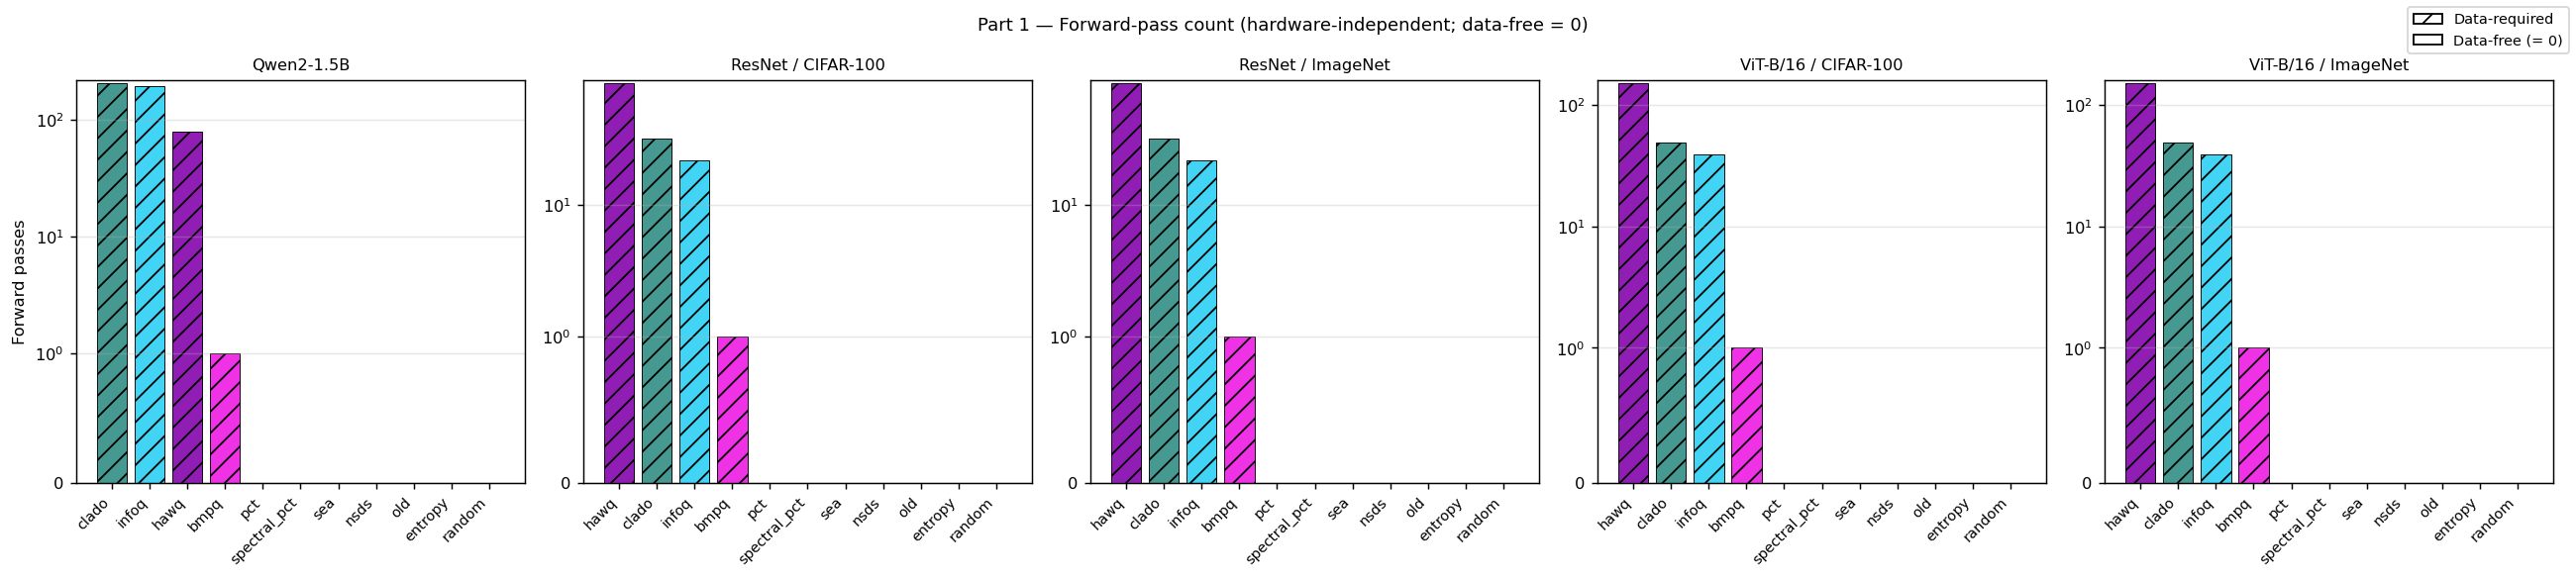

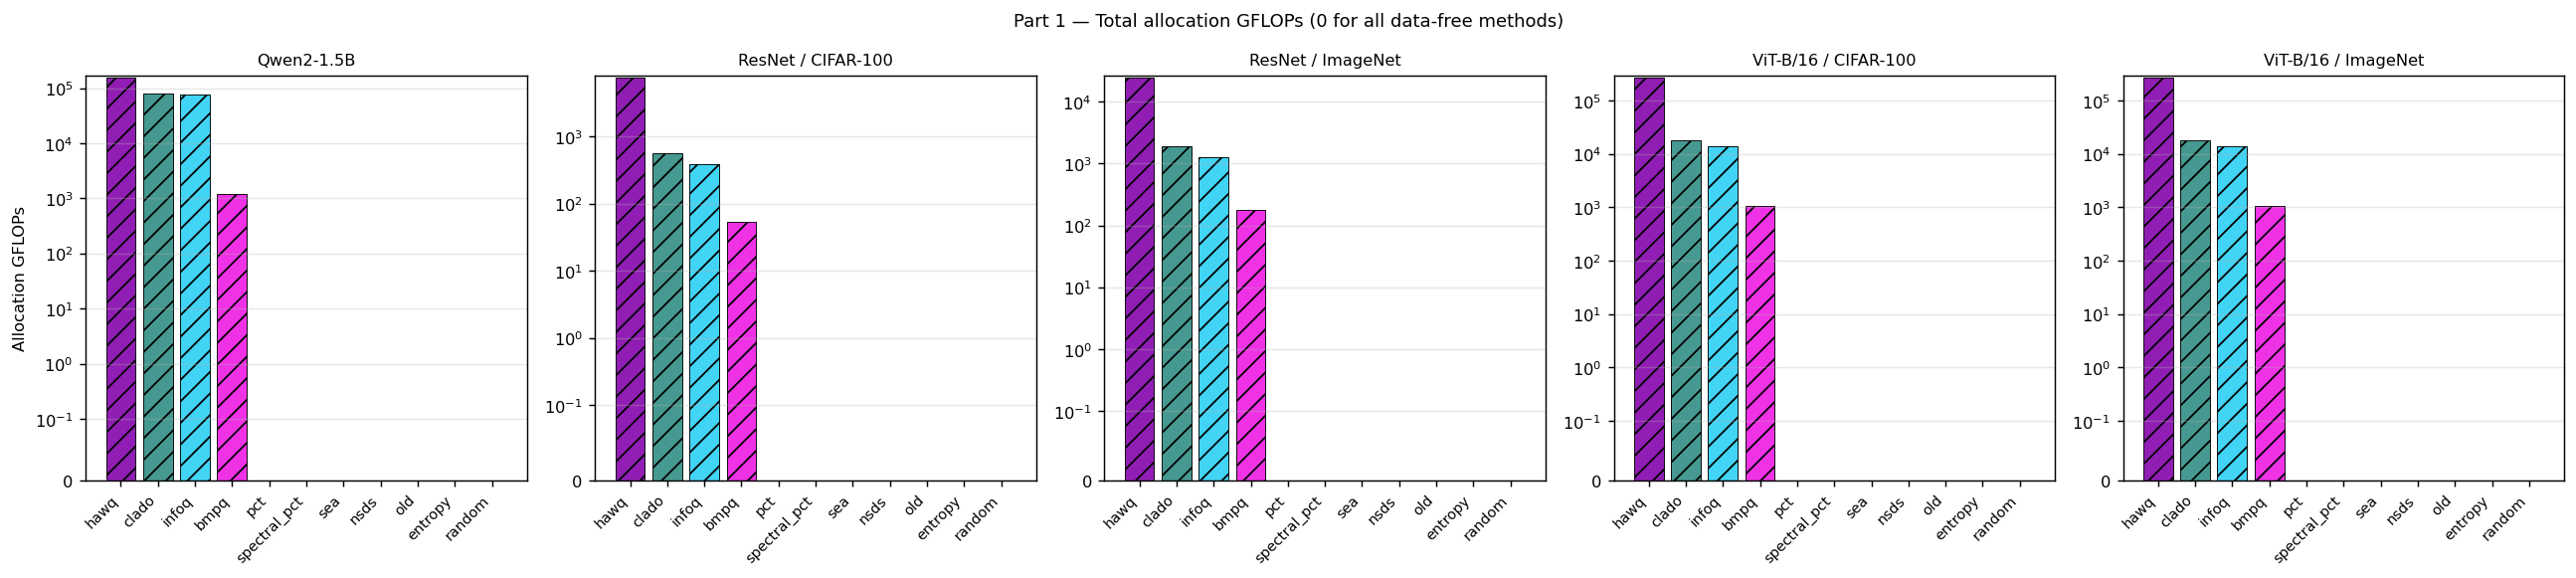

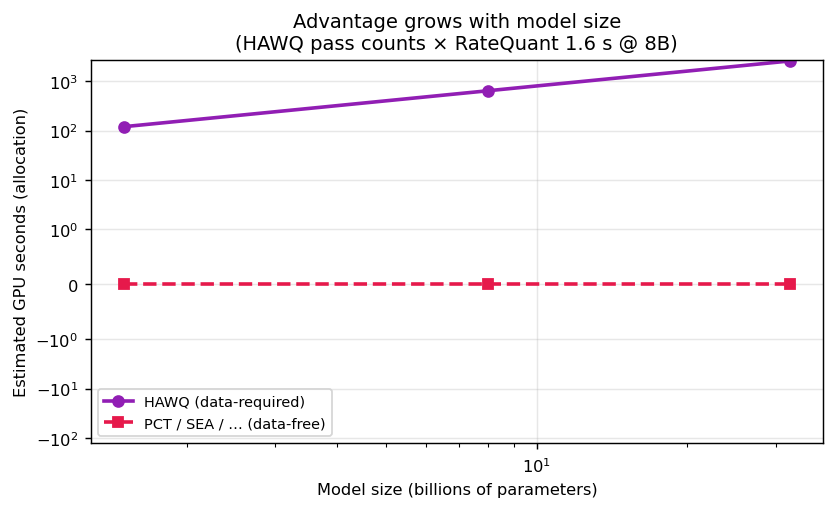

In [77]:
# ── Part 1: Visualizations (pass counts + FLOPs) ───────────────────────────────

model_ids = list(cost_df['model_id'].unique())

# Figure 1: forward-pass counts (log1p so zeros visible)
fig, axes = plt.subplots(1, len(model_ids), figsize=(4 * len(model_ids), 4.5), sharey=False)
if len(model_ids) == 1:
    axes = [axes]

for ax, mid in zip(axes, model_ids):
    sub = cost_df[cost_df['model_id'] == mid].sort_values('n_forward', ascending=False)
    cols = [METHOD_COLORS.get(m, '#888') for m in sub['method']]
    bars = ax.bar(range(len(sub)), sub['n_forward'], color=cols, edgecolor='black', lw=0.5)
    for bar, dr in zip(bars, sub['data_required']):
        if dr:
            bar.set_hatch('//')
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['method'], rotation=45, ha='right', fontsize=8)
    ax.set_title(MODEL_REGISTRY[mid]['label'], fontsize=9)
    ax.set_ylabel('Forward passes' if ax is axes[0] else '')
    ax.set_yscale('symlog', linthresh=1)
    ax.axhline(0, color='gray', lw=0.6)
    ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Data-required'),
    Patch(facecolor='white', edgecolor='black', label='Data-free (= 0)'),
], loc='upper right', fontsize=8)
fig.suptitle('Part 1 — Forward-pass count (hardware-independent; data-free = 0)', fontsize=10)
plt.tight_layout()
fig.savefig(OUT_DIR / 'part1_forward_pass_counts.png', bbox_inches='tight')
plt.show()


# Figure 2: allocation GFLOPs
fig, axes = plt.subplots(1, len(model_ids), figsize=(4 * len(model_ids), 4.5), sharey=False)
if len(model_ids) == 1:
    axes = [axes]
for ax, mid in zip(axes, model_ids):
    sub = cost_df[cost_df['model_id'] == mid].sort_values('allocation_gflops', ascending=False)
    cols = [METHOD_COLORS.get(m, '#888') for m in sub['method']]
    bars = ax.bar(range(len(sub)), sub['allocation_gflops'], color=cols, edgecolor='black', lw=0.5)
    for bar, dr in zip(bars, sub['data_required']):
        if dr:
            bar.set_hatch('//')
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub['method'], rotation=45, ha='right', fontsize=8)
    ax.set_title(MODEL_REGISTRY[mid]['label'], fontsize=9)
    ax.set_ylabel('Allocation GFLOPs' if ax is axes[0] else '')
    ax.set_yscale('symlog', linthresh=0.1)
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Part 1 — Total allocation GFLOPs (0 for all data-free methods)', fontsize=10)
plt.tight_layout()
fig.savefig(OUT_DIR / 'part1_allocation_gflops.png', bbox_inches='tight')
plt.show()


# Figure 3: scaling — GPU seconds vs model size (HAWQ vs data-free)
if 'scale_df' in dir() and len(scale_df):
    fig, ax = plt.subplots(figsize=(6.5, 4))
    xs = [PUBLISHED_PARAMS_B[t] for t in scale_df['target_model']]
    ax.plot(xs, scale_df['est_gpu_seconds_hawq'], 'o-', color='#911eb4', lw=2, label='HAWQ (data-required)')
    ax.plot(xs, scale_df['est_gpu_seconds_data_free'], 's--', color='#e6194b', lw=2, label='PCT / SEA / … (data-free)')
    ax.set_xlabel('Model size (billions of parameters)')
    ax.set_ylabel('Estimated GPU seconds (allocation)')
    ax.set_title('Advantage grows with model size\n(HAWQ pass counts × RateQuant 1.6 s @ 8B)')
    ax.set_xscale('log')
    ax.set_yscale('symlog', linthresh=1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig.savefig(OUT_DIR / 'part1_scaling_vs_model_size.png', bbox_inches='tight')
    plt.show()


In [78]:
# ═══════════════════════════════════════════════════════════════════════════════
# PART 2 — Inference-time overhead benchmark
# Measures forward-pass latency at different bit configurations:
#   - FP32 baseline
#   - Uniform INT8 / INT4 / INT3 / INT2 / INT1
#   - Mixed precision avg ≈ 3, 3.5, 4, 4.5 bits
# Uses random input tensors — no dataset required.
# ═══════════════════════════════════════════════════════════════════════════════

LATENCY_CSV = OUT_DIR / 'part2_inference_latency.csv'


def _infer_batch(model: nn.Module, x: torch.Tensor, is_llm: bool) -> None:
    """One forward pass (no grad)."""
    with torch.no_grad():
        if is_llm:
            model(x)
        else:
            model(x)


def measure_latency(
    model: nn.Module,
    input_shape: tuple,
    is_llm: bool,
    batch_size: int = LATENCY_BATCH,
    device = DEVICE,
) -> dict:
    """
    Returns mean/std/p95 latency (ms), throughput (samples/s),
    and memory footprint (MB).
    """
    m = copy.deepcopy(model).to(device).eval()

    if is_llm:
        x = torch.randint(0, 151936, (batch_size, input_shape[0])).to(device)
    else:
        x = torch.randn(batch_size, *input_shape).to(device)

    # Memory footprint: RSS increase after loading model to device
    mem_mb = _proc_rss_mb()

    # Warmup
    for _ in range(N_LATENCY_WARMUP):
        _infer_batch(m, x, is_llm)
    _sync_device()

    # Timed runs
    times_ms = []
    for _ in range(N_LATENCY_RUNS):
        _sync_device()
        t0 = time.perf_counter()
        _infer_batch(m, x, is_llm)
        _sync_device()
        times_ms.append((time.perf_counter() - t0) * 1000)

    times = np.array(times_ms)
    return {
        'mean_ms'   : float(times.mean()),
        'std_ms'    : float(times.std()),
        'p95_ms'    : float(np.percentile(times, 95)),
        'min_ms'    : float(times.min()),
        'throughput': float(batch_size / (times.mean() / 1000)),
        'footprint_mb': round(mem_mb, 1),
    }


def make_mixed_model(model, layer_names, bits_low, bits_high, target_avg_bits):
    """
    Greedy: upgrade layers one by one (by weight count) until avg_bits ≥ target.
    Uses equal-weight ordering (approximates the allocation without scoring).
    """
    counts = {n: get_module(model, n).weight.numel() for n in layer_names}
    total  = sum(counts.values())
    # Start all at bits_low; add 8-bit layers by decreasing size
    high   = set()
    sorted_layers = sorted(layer_names, key=lambda n: -counts[n])
    for n in sorted_layers:
        avg = (sum(counts[l] * (bits_high if l in high else bits_low)
                   for l in layer_names) / total)
        if avg >= target_avg_bits:
            break
        high.add(n)
    return quantize_model_inplace(model, layer_names, high_layers=high,
                                  bits_high=bits_high, bits_low=bits_low), high


def run_latency_benchmark() -> pd.DataFrame:
    rows = []

    for model_id in RUN_MODELS:
        cfg = MODEL_REGISTRY[model_id]
        print(f'\n── {cfg["label"]} ({model_id}) ──')

        print('  Loading model...', flush=True)
        model = cfg['loader']()
        if model is None:
            print('  SKIPPED')
            continue

        layer_names = cfg['layer_names']
        if layer_names is None:
            layer_names = get_qwen_layer_names(model)
            MODEL_REGISTRY[model_id]['layer_names'] = layer_names

        in_shape = cfg['input_shape']
        is_llm   = cfg['is_llm']
        bs       = 4 if is_llm else LATENCY_BATCH

        configs = [
            ('fp32',     model, 'FP32', float('nan')),
            ('int8',     quantize_model_inplace(model, layer_names, set(layer_names), 8, 8), 'INT8', 8.0),
            ('int4',     quantize_model_inplace(model, layer_names, set(), 8, 4), 'INT4', 4.0),
            ('int3',     quantize_model_inplace(model, layer_names, set(), 8, 3), 'INT3', 3.0),
            ('int2',     quantize_model_inplace(model, layer_names, set(), 8, 2), 'INT2', 2.0),
            ('int1',     quantize_model_inplace(model, layer_names, set(), 8, 1), 'INT1', 1.0),
        ]

        # Mixed-precision targets (INT4/INT8 mix at avg bit levels)
        for target in [3.0, 3.5, 4.0, 4.5]:
            m_mix, high = make_mixed_model(model, layer_names, bits_low=3, bits_high=8, target_avg_bits=target)
            n_high = len(high)
            total  = sum(get_module(model, n).weight.numel() for n in layer_names)
            actual_avg = sum(get_module(model, n).weight.numel() * (8 if n in high else 3)
                             for n in layer_names) / total
            configs.append((f'mixed_{target}', m_mix,
                            f'Mixed≈{target}bit (INT3/INT8)', round(actual_avg, 2)))

        fp32_ms = None
        for cfg_id, m_cfg, cfg_label, avg_bits in configs:
            print(f'  Latency [{cfg_label}]...', end=' ', flush=True)
            try:
                stats = measure_latency(m_cfg, in_shape, is_llm, batch_size=bs)
                if fp32_ms is None:
                    fp32_ms = stats['mean_ms']
                overhead_vs_fp32 = round((stats['mean_ms'] - fp32_ms) / fp32_ms * 100, 2)
                print(f"{stats['mean_ms']:.1f}ms ± {stats['std_ms']:.1f}ms  "
                      f"({stats['throughput']:.0f} samp/s)")
                rows.append(dict(
                    model_id=model_id,
                    model_label=MODEL_REGISTRY[model_id]['label'],
                    config_id=cfg_id,
                    config_label=cfg_label,
                    avg_bits=avg_bits,
                    batch_size=bs,
                    mean_ms=round(stats['mean_ms'], 3),
                    std_ms=round(stats['std_ms'], 3),
                    p95_ms=round(stats['p95_ms'], 3),
                    throughput=round(stats['throughput'], 1),
                    footprint_mb=stats['footprint_mb'],
                    overhead_vs_fp32_pct=overhead_vs_fp32,
                ))
            except Exception as e:
                print(f'FAILED: {e}')

        # Compute overhead vs INT4 baseline
        sub = pd.DataFrame([r for r in rows if r['model_id'] == model_id])
        if 'int4' in sub['config_id'].values:
            int4_ms = float(sub.loc[sub['config_id'] == 'int4', 'mean_ms'].iloc[0])
            for r in rows:
                if r['model_id'] == model_id:
                    r['overhead_vs_int4_pct'] = round((r['mean_ms'] - int4_ms) / int4_ms * 100, 2)

        del model, configs
        gc.collect()

    df = pd.DataFrame(rows)
    df.to_csv(LATENCY_CSV, index=False)
    print(f'\nSaved → {LATENCY_CSV.name} ({len(df)} rows)')
    return df


if LATENCY_CSV.exists() and not FORCE_RECOMPUTE:
    latency_df = pd.read_csv(LATENCY_CSV)
    print(f'Loaded cached latency from {LATENCY_CSV.name} ({len(latency_df)} rows)')
else:
    print('Running inference latency benchmark...')
    latency_df = run_latency_benchmark()

display(latency_df.round(2))


Loaded cached latency from part2_inference_latency.csv (50 rows)


,model_id,model_label,config_id,config_label,avg_bits,batch_size,mean_ms,std_ms,p95_ms,throughput,footprint_mb,overhead_vs_fp32_pct,overhead_vs_int4_pct
0,rn_c100,ResNet / CIFAR-100,fp32,FP32,NaN,32,6.68,0.59,7.52,4788.4,3770.9,0.00,-1.24
1,rn_c100,ResNet / CIFAR-100,int8,INT8,8.00,32,6.79,0.47,7.48,4710.0,3827.3,1.66,0.40
2,rn_c100,ResNet / CIFAR-100,int4,INT4,4.00,32,6.77,0.28,7.19,4728.8,3827.4,1.26,0.00
3,rn_c100,ResNet / CIFAR-100,int3,INT3,3.00,32,7.05,0.54,8.13,4541.1,3827.7,5.45,4.14
4,rn_c100,ResNet / CIFAR-100,int2,INT2,2.00,32,7.85,0.67,8.66,4078.3,3828.2,17.41,15.95
5,rn_c100,ResNet / CIFAR-100,int1,INT1,1.00,32,8.14,0.61,9.05,3933.5,3828.2,21.73,20.22
6,rn_c100,ResNet / CIFAR-100,mixed_3.0,Mixed≈3.0bit (INT3/INT8),3.00,32,7.87,0.52,8.60,4065.8,3828.4,17.77,16.31
7,rn_c100,ResNet / CIFAR-100,mixed_3.5,Mixed≈3.5bit (INT3/INT8),4.05,32,6.94,0.17,7.21,4611.6,3828.4,3.83,2.54
8,rn_c100,ResNet / CIFAR-100,mixed_4.0,Mixed≈4.0bit (INT3/INT8),4.05,32,6.67,0.49,7.36,4795.2,3828.6,-0.14,-1.39
9,rn_c100,ResNet / CIFAR-100,mixed_4.5,Mixed≈4.5bit (INT3/INT8),5.10,32,6.69,0.50,7.34,4781.8,3828.8,0.14,-1.11


In [79]:
# ── Part 2 companion: allocation FLOPs + one-time inference profiling ─────────
# Inference profiling still uses wall-clock (SLA-relevant). Allocation uses FLOPs.

PROFILING_BATCHES = 20

ttd_rows = []
for model_id in cost_df['model_id'].unique():
    c_df = cost_df[cost_df['model_id'] == model_id]
    l_df = latency_df[latency_df['model_id'] == model_id] if 'latency_df' in dir() else pd.DataFrame()
    label = MODEL_REGISTRY[model_id]['label']

    if len(l_df) and 'fp32' in set(l_df['config_id'].astype(str)):
        fp32_s = float(l_df.loc[l_df['config_id'] == 'fp32', 'mean_ms'].iloc[0]) / 1000 * PROFILING_BATCHES
    else:
        fp32_s = 0.0

    for _, row in c_df.iterrows():
        ttd_rows.append(dict(
            model_id=model_id,
            model_label=label,
            method=row['method'],
            data_required=row['data_required'],
            allocation_gflops=row['allocation_gflops'],
            n_forward=row['n_forward'],
            equiv_forward_units=row['equiv_forward_units'],
            profiling_time_s=round(fp32_s, 3),
            # practitioner headline: zero allocation FLOPs for data-free
            allocation_is_zero=row['allocation_gflops'] == 0,
        ))

ttd_df = pd.DataFrame(ttd_rows)
ttd_df.to_csv(OUT_DIR / 'part2_allocation_plus_profiling.csv', index=False)

print('=== Allocation GFLOPs (0 = data-free) + inference profiling seconds ===')
display(ttd_df.pivot_table(index='method', columns='model_id',
                            values='allocation_gflops', aggfunc='first').round(2))


=== Allocation GFLOPs (0 = data-free) + inference profiling seconds ===


model_id,qwen,rn_c100,rn_inet,vit_c100,vit_inet
method,,,,,
bmpq,1185.46,53.56,175.11,1083.41,1083.48
clado,81796.83,571.33,1867.81,17695.76,17696.85
entropy,0.00,0.00,0.00,0.00,0.00
hawq,158061.51,7498.65,24515.01,274464.90,274481.71
infoq,77845.29,392.79,1284.12,14084.38,14085.25
nsds,0.00,0.00,0.00,0.00,0.00
old,0.00,0.00,0.00,0.00,0.00
pct,0.00,0.00,0.00,0.00,0.00
random,0.00,0.00,0.00,0.00,0.00


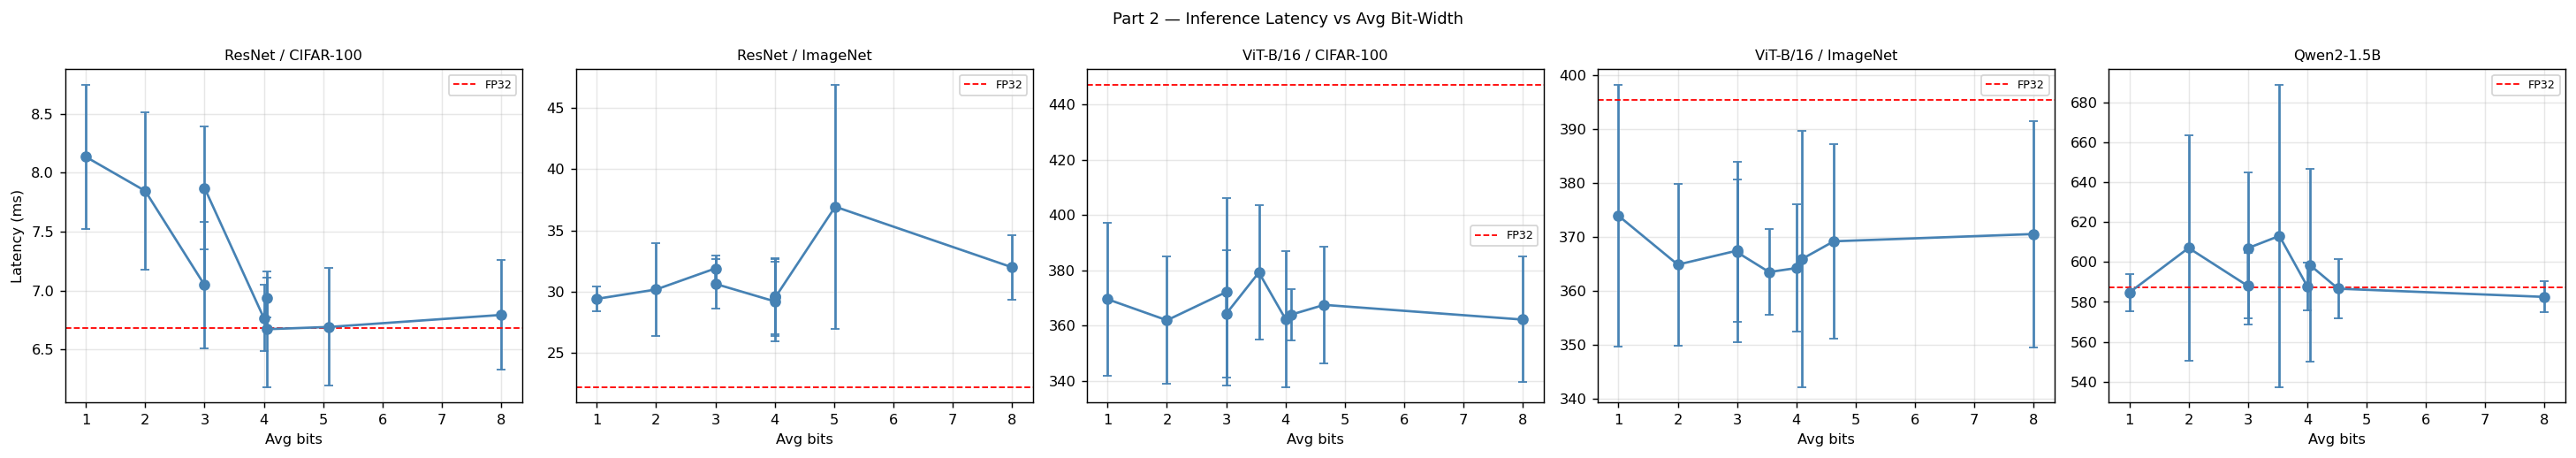

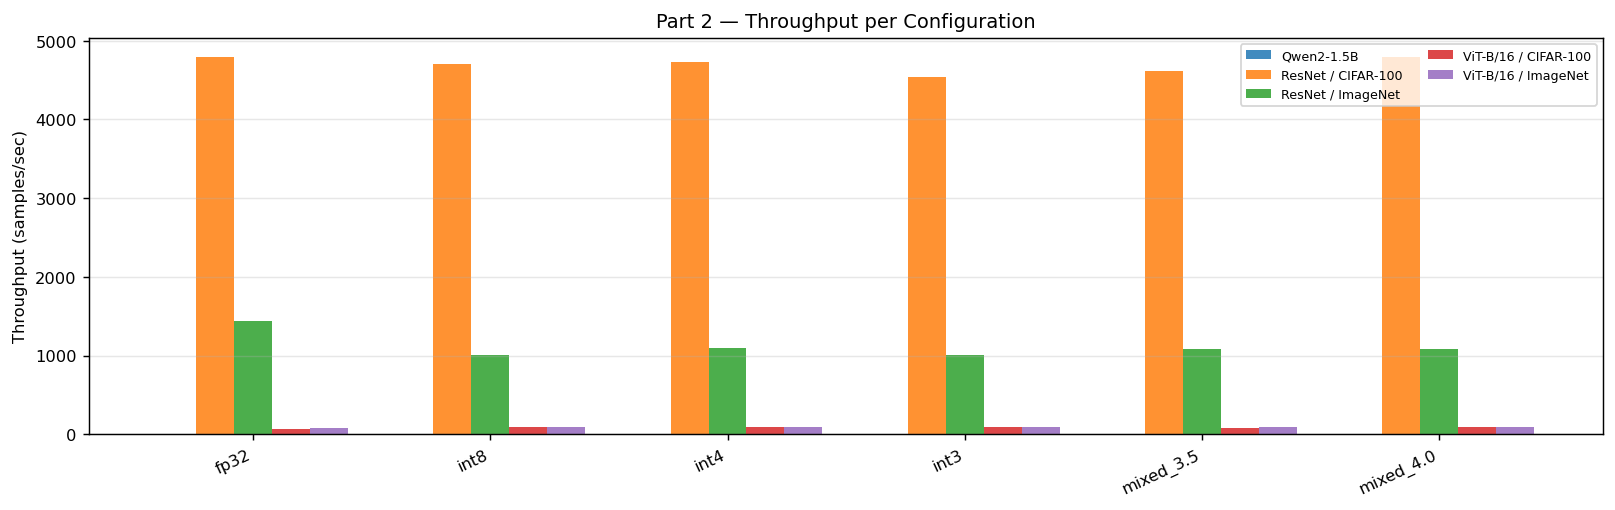

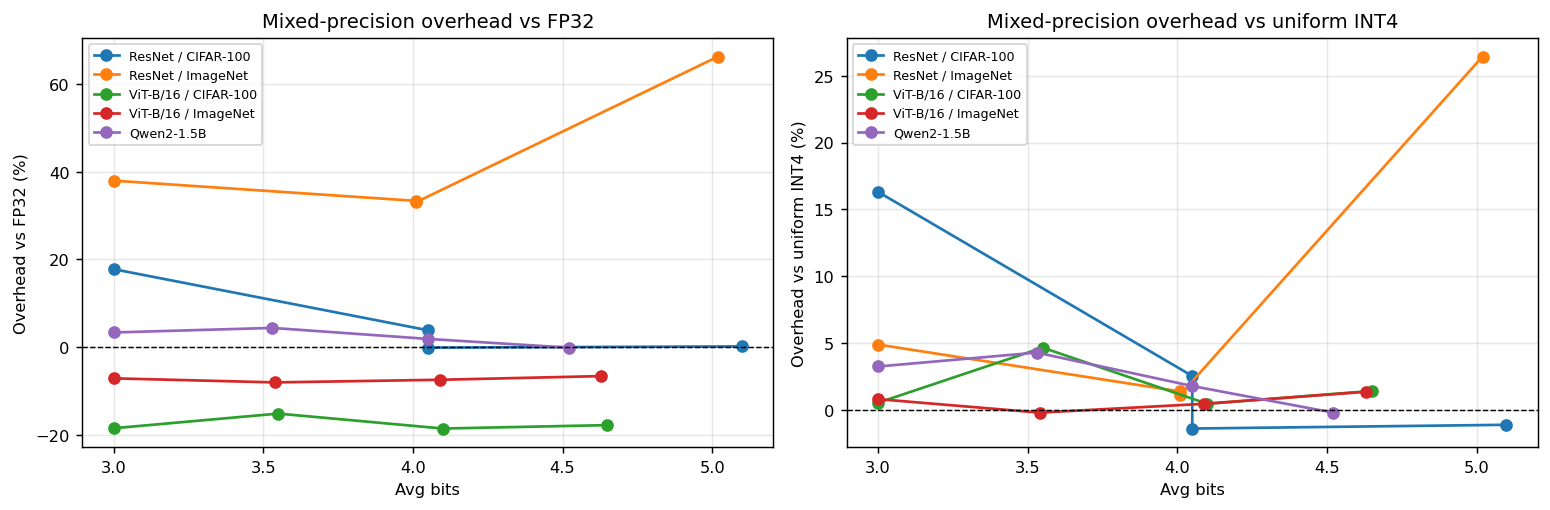

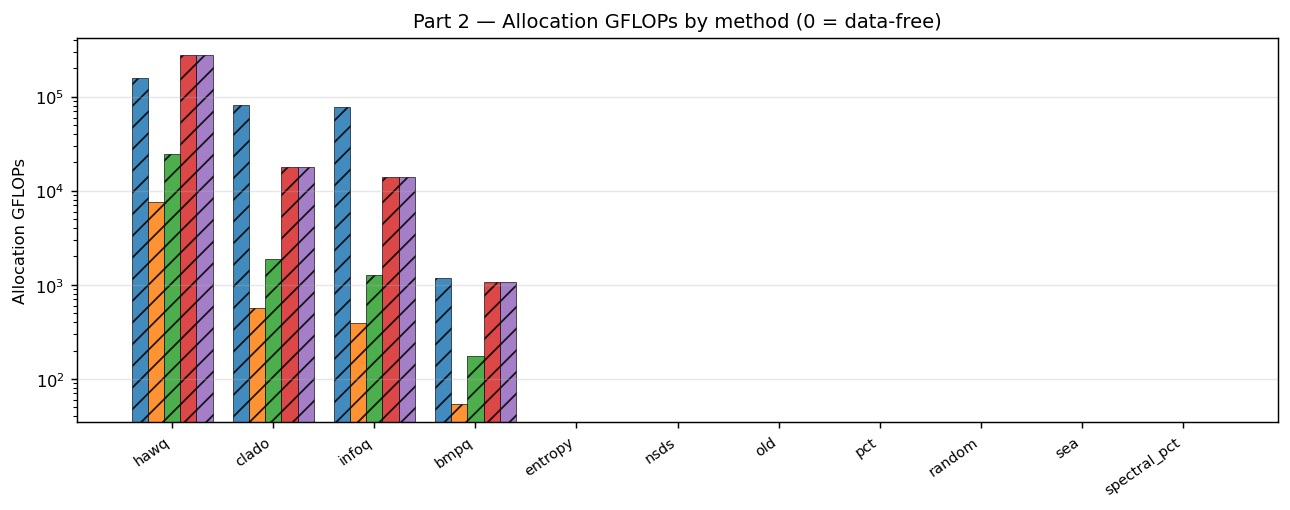

In [80]:
# ── Part 2: Visualizations ─────────────────────────────────────────────────────

# ── Figure 4: Latency vs avg bits per model ────────────────────────────────────
model_ids_lat = latency_df['model_id'].unique()
n_models = len(model_ids_lat)
fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4), sharey=False)
if n_models == 1:
    axes = [axes]

for ax, mid in zip(axes, model_ids_lat):
    sub  = latency_df[(latency_df['model_id'] == mid) & latency_df['avg_bits'].notna()]
    sub  = sub.sort_values('avg_bits')
    ax.errorbar(sub['avg_bits'], sub['mean_ms'], yerr=sub['std_ms'],
                fmt='o-', capsize=3, color='steelblue', linewidth=1.5)
    fp32_row = latency_df[(latency_df['model_id'] == mid) & (latency_df['config_id'] == 'fp32')]
    if len(fp32_row):
        ax.axhline(float(fp32_row['mean_ms'].iloc[0]), linestyle='--', color='red',
                   linewidth=1, label='FP32')
    ax.set_xlabel('Avg bits')
    ax.set_ylabel('Latency (ms)' if mid == model_ids_lat[0] else '')
    ax.set_title(MODEL_REGISTRY[mid]['label'], fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.suptitle('Part 2 — Inference Latency vs Avg Bit-Width', fontsize=10)
plt.tight_layout()
fig.savefig(OUT_DIR / 'part2_latency_vs_bits.png', bbox_inches='tight')
plt.show()


# ── Figure 5: Throughput grouped bars ─────────────────────────────────────────
key_configs = ['fp32', 'int8', 'int4', 'int3', 'mixed_3.5', 'mixed_4.0']
lat_sub = latency_df[latency_df['config_id'].isin(key_configs)]

pivot_thr = lat_sub.pivot_table(index='config_id', columns='model_id',
                                  values='throughput', aggfunc='first')
pivot_thr = pivot_thr.reindex([c for c in key_configs if c in pivot_thr.index])

fig, ax = plt.subplots(figsize=(max(8, n_models * 2.5), 4))
x   = np.arange(len(pivot_thr))
w   = 0.8 / max(len(pivot_thr.columns), 1)
for i, col in enumerate(pivot_thr.columns):
    ax.bar(x + i * w, pivot_thr[col], width=w,
           label=MODEL_REGISTRY[col]['label'], alpha=0.85)
ax.set_xticks(x + w * (len(pivot_thr.columns) - 1) / 2)
ax.set_xticklabels(pivot_thr.index, rotation=25, ha='right')
ax.set_ylabel('Throughput (samples/sec)')
ax.set_title('Part 2 — Throughput per Configuration')
ax.legend(fontsize=7, ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / 'part2_throughput.png', bbox_inches='tight')
plt.show()


# ── Figure 6: Overhead vs FP32 and vs uniform INT4 ─────────────────────────────
if 'overhead_vs_fp32_pct' in latency_df.columns:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    mixed_rows = latency_df[latency_df['config_id'].str.startswith('mixed_', na=False)]

    for mid in model_ids_lat:
        sub = mixed_rows[mixed_rows['model_id'] == mid].sort_values('avg_bits')
        if len(sub):
            ax1.plot(sub['avg_bits'], sub['overhead_vs_fp32_pct'],
                     marker='o', label=MODEL_REGISTRY[mid]['label'])
            if 'overhead_vs_int4_pct' in sub.columns:
                ax2.plot(sub['avg_bits'], sub['overhead_vs_int4_pct'],
                         marker='o', label=MODEL_REGISTRY[mid]['label'])

    ax1.axhline(0, color='black', lw=0.8, linestyle='--')
    ax1.set_xlabel('Avg bits')
    ax1.set_ylabel('Overhead vs FP32 (%)')
    ax1.set_title('Mixed-precision overhead vs FP32')
    ax1.legend(fontsize=7)
    ax1.grid(alpha=0.3)

    ax2.axhline(0, color='black', lw=0.8, linestyle='--')
    ax2.set_xlabel('Avg bits')
    ax2.set_ylabel('Overhead vs uniform INT4 (%)')
    ax2.set_title('Mixed-precision overhead vs uniform INT4')
    ax2.legend(fontsize=7)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    fig.savefig(OUT_DIR / 'part2_overhead.png', bbox_inches='tight')
    plt.show()


# ── Figure 7: Time-to-deploy comparison ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
pivot_ttd = ttd_df.pivot_table(index='method', columns='model_id', values='allocation_gflops', aggfunc='first')
pivot_ttd_sorted = pivot_ttd.mean(axis=1).sort_values(ascending=False)
pivot_ttd = pivot_ttd.loc[pivot_ttd_sorted.index]

n_m = len(pivot_ttd.columns)
x   = np.arange(len(pivot_ttd))
w   = 0.8 / max(n_m, 1)
for i, col in enumerate(pivot_ttd.columns):
    is_dr = ttd_df[(ttd_df['method'].isin(pivot_ttd.index)) &
                   (ttd_df['model_id'] == col)].set_index('method')['data_required']
    for j, meth in enumerate(pivot_ttd.index):
        dr    = bool(is_dr.get(meth, False))
        val   = pivot_ttd.loc[meth, col] if col in pivot_ttd.columns and not pd.isna(pivot_ttd.loc[meth, col]) else 0
        bar   = ax.bar(j + i * w, val, width=w, alpha=0.85,
                       hatch='//' if dr else '',
                       color=plt.cm.tab10(i), edgecolor='black', linewidth=0.4)
ax.set_xticks(x + w * (n_m - 1) / 2)
ax.set_xticklabels(pivot_ttd.index, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Allocation GFLOPs')
ax.set_title('Part 2 — Allocation GFLOPs by method (0 = data-free)')
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / 'part2_allocation_gflops.png', bbox_inches='tight')
plt.show()


In [81]:
# ═══════════════════════════════════════════════════════════════════════════════
# PART 3 — Accuracy / PPL from pre-existing benchmark CSVs
# No model re-evaluation; we load what was already computed.
# ═══════════════════════════════════════════════════════════════════════════════

ACC_SOURCES = {
    'rn_c100' : (ROOT / 'results' / 'cifar100_layer_importance_benchmark' / 'resnet_cifar100_benchmark_results.csv',  'accuracy'),
    'rn_inet' : (ROOT / 'results' / 'imagenet_layer_importance_benchmark' / 'resnet_imagenet_benchmark_results.csv', 'accuracy'),
    'vit_c100': (ROOT / 'results' / 'cifar100_layer_importance_benchmark' / 'vit_cifar100_benchmark_results.csv',    'accuracy'),
    'vit_inet': (ROOT / 'results' / 'imagenet_layer_importance_benchmark' / 'vit_imagenet_benchmark_results.csv',    'accuracy'),
    'qwen'    : (ROOT / 'results' / 'qwen_wikitext2_quant' / 'qwen_wikitext2_benchmark_results.csv',                'perplexity'),
}

acc_dfs = {}
for mid, (csv_path, metric) in ACC_SOURCES.items():
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df['metric']   = metric
        df['model_id'] = mid
        df['model_label'] = MODEL_REGISTRY[mid]['label']
        acc_dfs[mid]   = df
        print(f'  {mid}: {len(df)} rows, metric={metric}')
    else:
        print(f'  {mid}: CSV not found — {csv_path.name}')

print(f'\nLoaded {len(acc_dfs)} accuracy CSVs.')


  rn_c100: 281 rows, metric=accuracy
  rn_inet: 281 rows, metric=accuracy
  vit_c100: 281 rows, metric=accuracy
  vit_inet: 281 rows, metric=accuracy
  qwen: 143 rows, metric=perplexity

Loaded 5 accuracy CSVs.


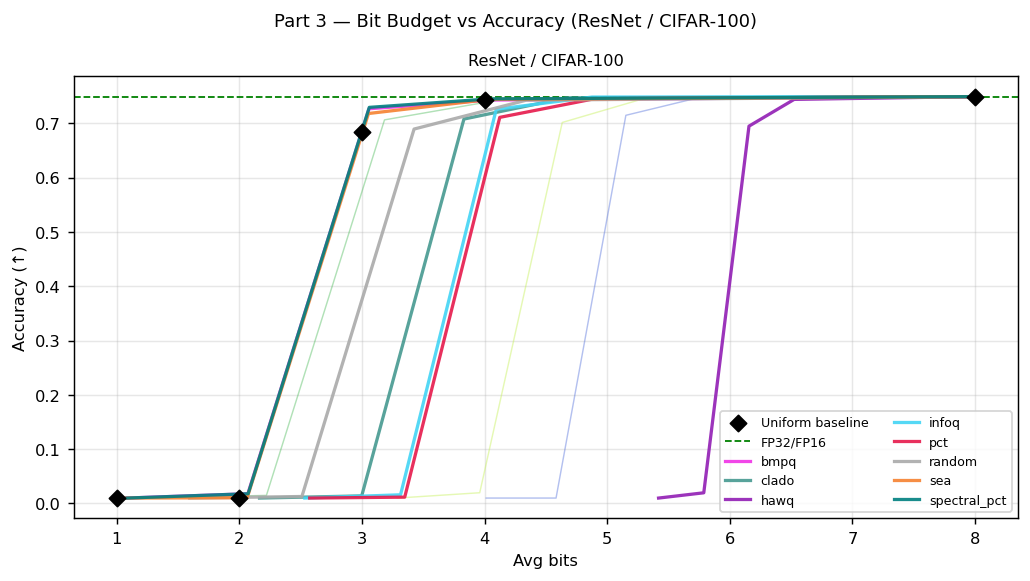

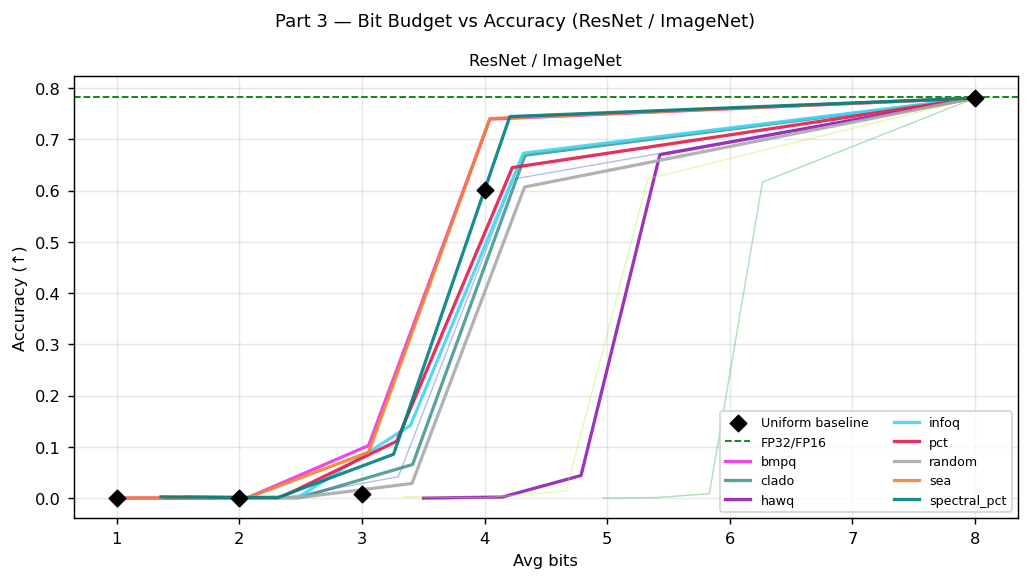

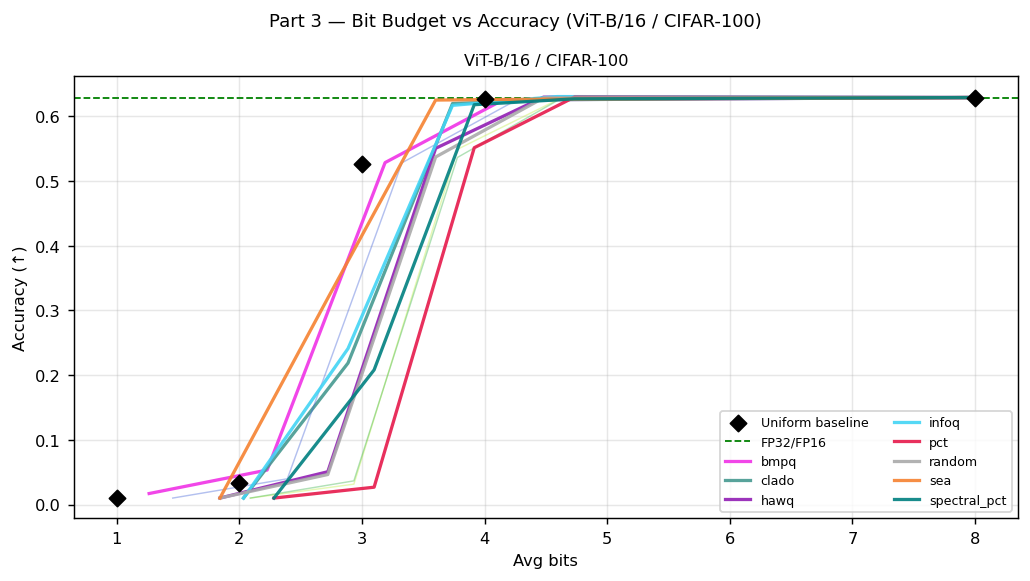

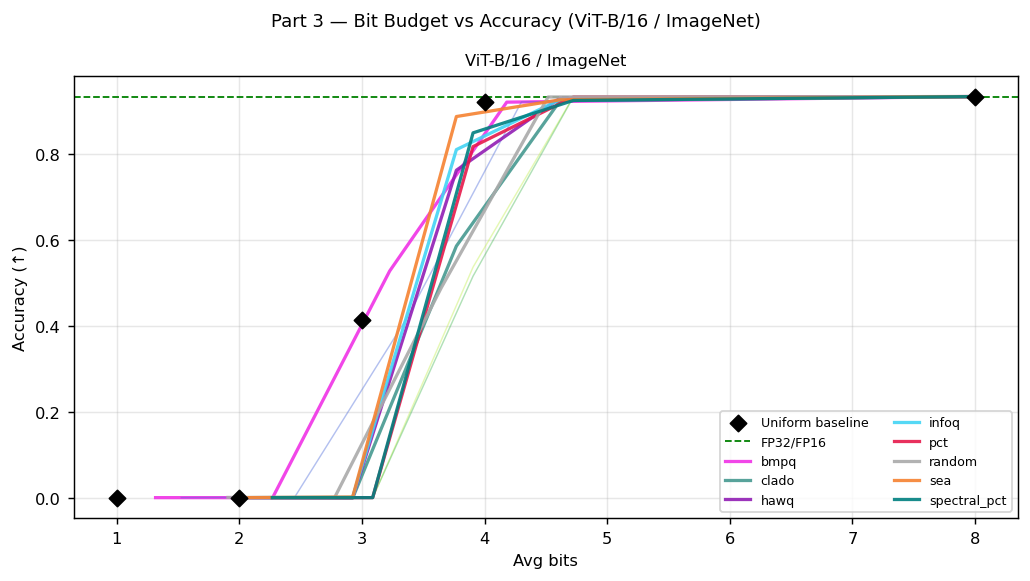

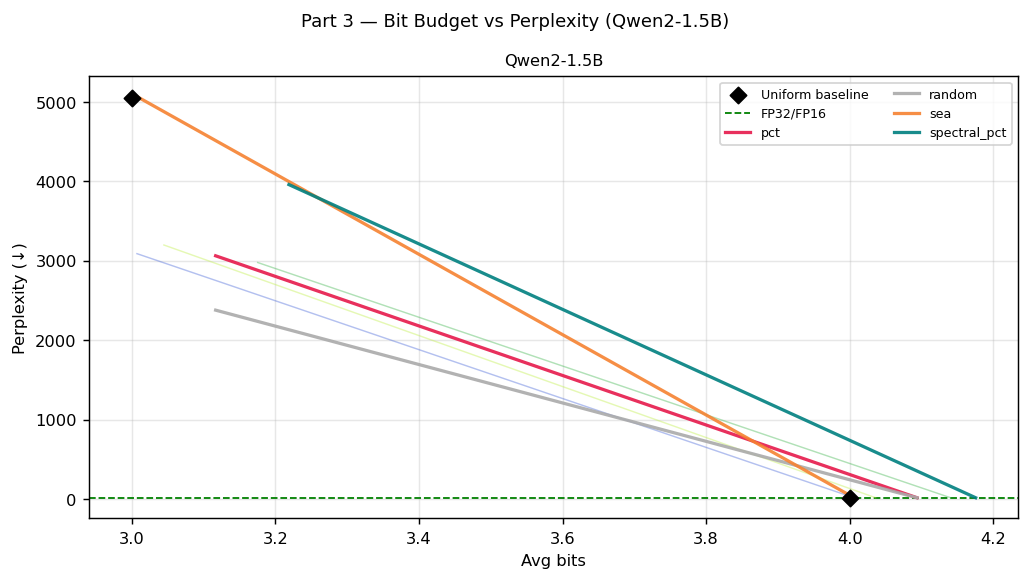

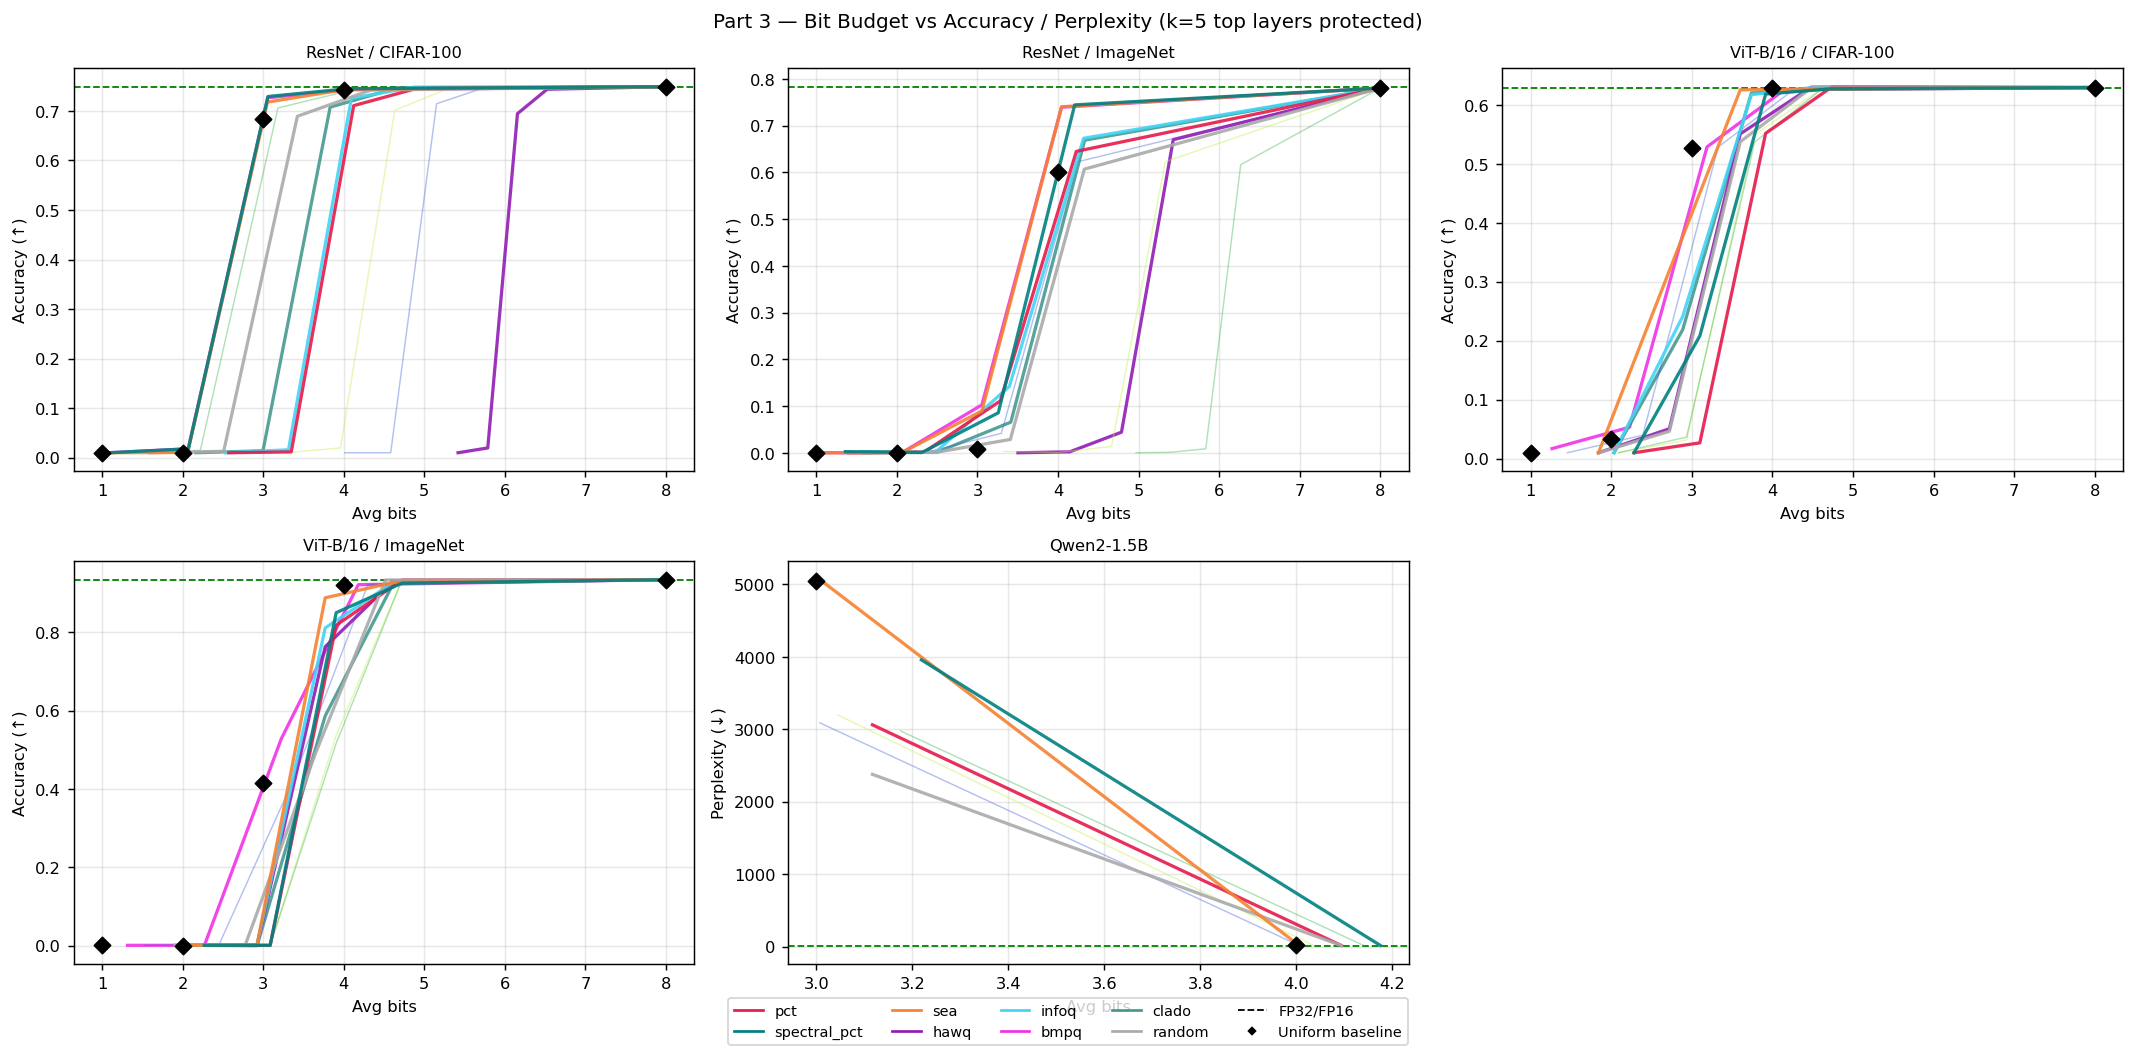

In [82]:
# ── Part 3: Bit budget vs accuracy / perplexity ───────────────────────────────

HIGHLIGHT_METHODS = ['pct', 'spectral_pct', 'sea', 'hawq', 'infoq', 'bmpq', 'clado', 'random']

def plot_acc_vs_bits(
    df: pd.DataFrame,
    metric_col: str,
    model_label: str,
    ax,
    lower_is_better: bool = False,
    k_filter: int = 5,
    bits_low_filter: int | None = None,
):
    """Plot metric vs avg_bits for each method."""
    # Baselines first
    baselines = df[df['method'].str.startswith('baseline_int')].copy()
    if 'avg_bits' not in baselines.columns:
        if 'bits_low' in baselines.columns:
            baselines['avg_bits'] = baselines['bits_low'].astype(float)
    if len(baselines):
        ax.scatter(baselines['avg_bits'], baselines[metric_col],
                   color='black', zorder=5, s=40, marker='D', label='Uniform baseline')

    # FP32 / FP16 reference
    ref = df[df['method'].isin(['fp32', 'fp16'])]
    if len(ref):
        ref_val = float(ref[metric_col].iloc[0])
        ax.axhline(ref_val, linestyle='--', color='green', linewidth=1, label='FP32/FP16')

    # Methods sweep
    method_df = df[~df['method'].str.startswith('baseline') & ~df['method'].isin(['fp32', 'fp16'])].copy()
    if k_filter is not None and 'k' in method_df.columns:
        method_df = method_df[method_df['k'] == k_filter]
    if bits_low_filter is not None and 'bits_low' in method_df.columns:
        method_df = method_df[method_df['bits_low'] == bits_low_filter]

    for method, grp in method_df.groupby('method'):
        if 'avg_bits' not in grp.columns:
            continue
        grp  = grp.sort_values('avg_bits')
        col  = METHOD_COLORS.get(method, '#888')
        alpha = 0.9 if method in HIGHLIGHT_METHODS else 0.4
        lw    = 1.8 if method in HIGHLIGHT_METHODS else 0.8
        ax.plot(grp['avg_bits'], grp[metric_col],
                color=col, linewidth=lw, alpha=alpha,
                label=method if method in HIGHLIGHT_METHODS else '_')

    ax.set_xlabel('Avg bits')
    ylabel = 'Perplexity (↓)' if lower_is_better else 'Accuracy (↑)'
    ax.set_ylabel(ylabel)
    ax.set_title(model_label, fontsize=9)
    ax.grid(alpha=0.3)


# One figure per model
for mid, df in acc_dfs.items():
    metric_col = 'perplexity' if mid == 'qwen' else 'accuracy'
    lower_is_better = mid == 'qwen'
    label = MODEL_REGISTRY[mid]['label']

    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_acc_vs_bits(df, metric_col, label, ax, lower_is_better=lower_is_better)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=7, ncol=2,
              loc='lower right' if not lower_is_better else 'upper right')
    fig.suptitle(f'Part 3 — Bit Budget vs {"Perplexity" if lower_is_better else "Accuracy"} ({label})',
                 fontsize=10)
    plt.tight_layout()
    fig.savefig(OUT_DIR / f'part3_acc_vs_bits_{mid}.png', bbox_inches='tight')
    plt.show()


# ── Combined 2x3 grid ─────────────────────────────────────────────────────────
n   = len(acc_dfs)
nc  = min(3, n)
nr  = (n + nc - 1) // nc
fig, axes = plt.subplots(nr, nc, figsize=(5.5 * nc, 4 * nr))
axes_flat = np.array(axes).flatten()

for i, (mid, df) in enumerate(acc_dfs.items()):
    metric_col = 'perplexity' if mid == 'qwen' else 'accuracy'
    plot_acc_vs_bits(df, metric_col, MODEL_REGISTRY[mid]['label'],
                     axes_flat[i], lower_is_better=(mid == 'qwen'))

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

# Shared legend
legend_handles = [matplotlib.lines.Line2D([0], [0], color=METHOD_COLORS.get(m, '#888'),
                                           linewidth=1.5, label=m)
                  for m in HIGHLIGHT_METHODS]
legend_handles.append(matplotlib.lines.Line2D([0], [0], color='black',
                                               linewidth=1, linestyle='--', label='FP32/FP16'))
legend_handles.append(
    matplotlib.lines.Line2D([0], [0], marker='D', color='w', markerfacecolor='black',
                              markersize=5, label='Uniform baseline'))
fig.legend(handles=legend_handles, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Part 3 — Bit Budget vs Accuracy / Perplexity (k=5 top layers protected)', fontsize=11)
plt.tight_layout()
fig.savefig(OUT_DIR / 'part3_acc_vs_bits_all.png', bbox_inches='tight')
plt.show()


Saved → part3_sensitivity_efficiency.csv (102 rows)

SENSITIVITY EFFICIENCY — recovery vs cost to rank layers
Operating points: k=5, bits_low ∈ {3,4}  ← INT3 is where gaps are real
efficiency = recovery_pp / allocation_gflops  (∞ for data-free)
recovery = mixed − uniform INT{bits_low}   |   vs_fp = mixed − FP32/FP16

ResNet / CIFAR-100  |  bits_low=INT3  |  uniform vs FP: -6.48 pp
  Data-free:     spectral_pct    +4.49 pp recovery at 0 GFLOPs, -1.99 pp vs FP
  Best data-req: bmpq            +4.24 pp recovery at 53.6 GFLOPs, -2.24 pp vs FP
  Closest to FP: spectral_pct    acc/ppl=0.7291  -1.99 pp vs FP  (recovery +4.49 pp)
  Most efficient data-req: bmpq      0.07916 pp/GFLOP
  → Data-free DOMINATES on recovery (same/better at zero cost)

ResNet / CIFAR-100  |  bits_low=INT4  |  uniform vs FP: -0.65 pp
  Data-free:     nsds            +0.33 pp recovery at 0 GFLOPs, -0.32 pp vs FP
  Best data-req: infoq           +0.56 pp recovery at 392.8 GFLOPs, -0.09 pp vs FP
  Closest to FP: infoq   

,model_label,bits_low,method,data_required,recovery_pp,vs_fp_pp,allocation_gflops,efficiency_display
94,Qwen2-1.5B,3,random,False,2666.0797,-2365.9570,0.0000,∞ (data-free)
89,Qwen2-1.5B,3,old,False,2066.3671,-2965.6696,0.0000,∞ (data-free)
88,Qwen2-1.5B,3,pct,False,1981.7869,-3050.2498,0.0000,∞ (data-free)
90,Qwen2-1.5B,3,entropy,False,1954.8960,-3077.1406,0.0000,∞ (data-free)
93,Qwen2-1.5B,3,nsds,False,1845.8463,-3186.1904,0.0000,∞ (data-free)
...,...,...,...,...,...,...,...,...
80,ViT-B/16 / ImageNet,4,sea,False,0.5500,-0.6000,0.0000,∞ (data-free)
82,ViT-B/16 / ImageNet,4,spectral_pct,False,0.4000,-0.7500,0.0000,∞ (data-free)
86,ViT-B/16 / ImageNet,4,clado,True,0.3500,-0.8000,17696.8472,1.97775e-05
79,ViT-B/16 / ImageNet,4,entropy,False,0.0500,-1.1000,0.0000,∞ (data-free)


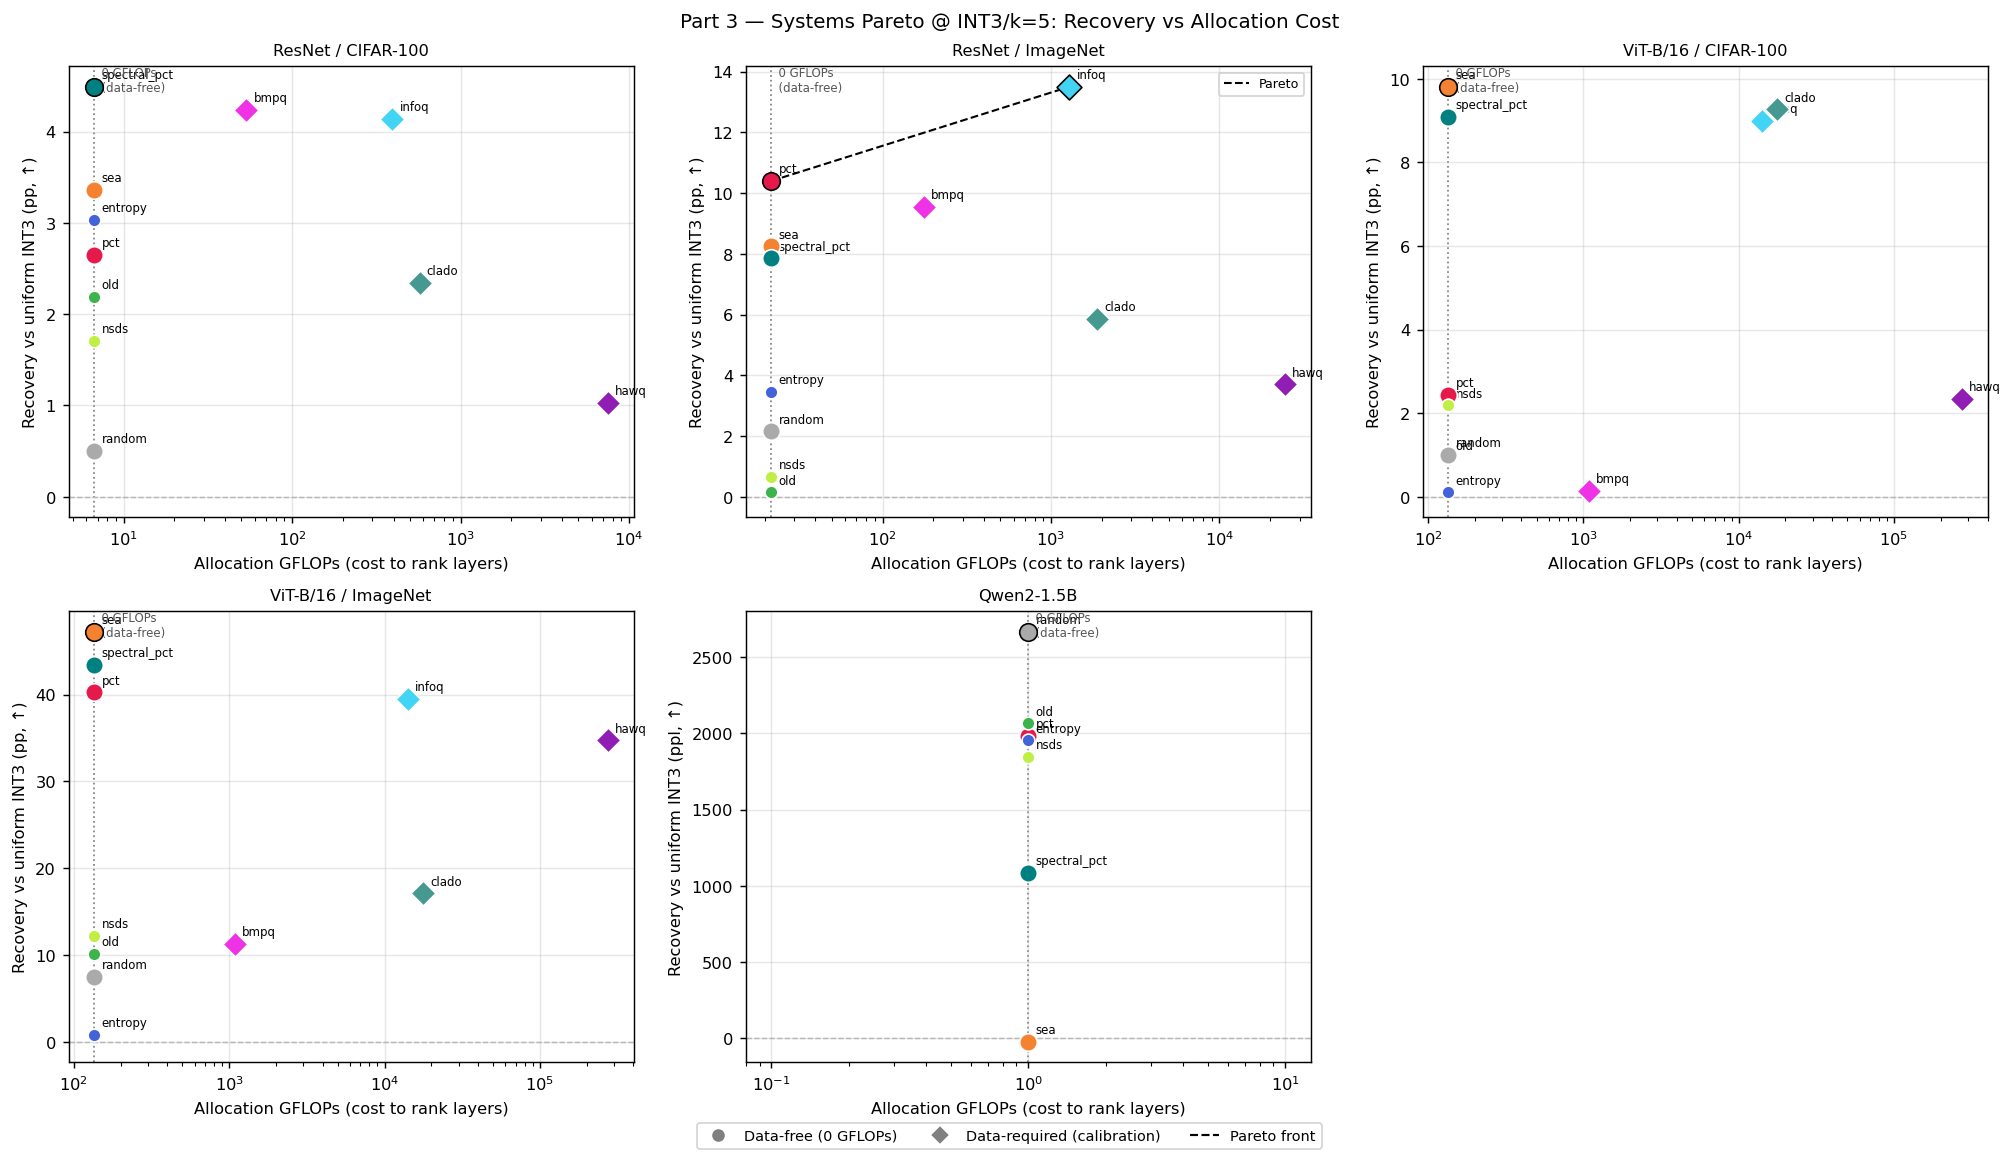

KeyboardInterrupt: 

In [83]:
# ── Part 3: Sensitivity-computation efficiency ────────────────────────────────
# Metric: recovery_pp / allocation_gflops
#
#   efficiency = accuracy_recovery_pp / allocation_gflops
#
# CRITICAL: do NOT only look at INT4.
#   INT4 uniform is often already ≈ FP32 → method gaps look tiny (~0.5pp).
#   INT3 uniform collapses → mixed precision recovers ~5–47pp and can land
#   within ~0.5–4pp of FP32 (see ViT CIFAR-100 SEA, ViT ImageNet SEA).
#
# Data-free methods have allocation_gflops = 0 → ratio is undefined / ∞.
# Report separately per (model, bits_low):
#   "data-free achieves X pp recovery at 0 cost (Y pp from FP32);
#    best data-required achieves Z pp at W GFLOPs"
#
# Systems figure: Pareto of allocation cost (x) vs recovery (y), panels per bits_low.

from matplotlib.lines import Line2D

if 'cost_df' not in dir() or cost_df is None or len(cost_df) == 0:
    _cost_path = OUT_DIR / 'part1_allocation_flops.csv'
    if not _cost_path.exists():
        raise FileNotFoundError(f'Need {_cost_path} — run Part 1 first')
    cost_df = pd.read_csv(_cost_path)
    print(f'Loaded allocation costs from {_cost_path.name}')

K_EFF = 5
# Both operating points — INT3 is where allocation methods actually matter.
BITS_SWEEP = {
    'rn_c100': [3, 4],
    'rn_inet': [3, 4],
    'vit_c100': [3, 4],
    'vit_inet': [3, 4],
    'qwen': [3, 4],
}

def _metric_col(mid: str) -> str:
    return 'perplexity' if mid == 'qwen' else 'accuracy'

def _recovery_raw(val: float, baseline: float, lower_better: bool) -> float:
    return (baseline - val) if lower_better else (val - baseline)

def _fp_ref(df: pd.DataFrame, metric_col: str) -> float | None:
    ref = df[df['method'].isin(['fp32', 'fp16'])]
    if len(ref) == 0 or metric_col not in ref.columns:
        return None
    return float(ref[metric_col].iloc[0])

eff_rows: list[dict] = []

for mid, df in acc_dfs.items():
    metric_col = _metric_col(mid)
    lower_better = mid == 'qwen'
    unit = 'ppl' if lower_better else 'pp'
    fp_val = _fp_ref(df, metric_col)
    bits_list = BITS_SWEEP.get(mid, [3, 4])

    for bits in bits_list:
        base_rows = df[df['method'] == f'baseline_int{bits}']
        if len(base_rows) == 0:
            print(f'  {mid} INT{bits}: missing baseline — skip')
            continue
        baseline = float(base_rows[metric_col].iloc[0])

        sweep = df[
            (~df['method'].astype(str).str.startswith('baseline')) &
            (~df['method'].isin(['fp32', 'fp16'])) &
            (df['k'] == K_EFF if 'k' in df.columns else True) &
            (df['bits_low'] == bits if 'bits_low' in df.columns else True)
        ][['method', metric_col]].copy()
        if len(sweep) == 0:
            print(f'  {mid} INT{bits}: no k={K_EFF} rows — skip')
            continue

        costs = cost_df[cost_df['model_id'] == mid][
            ['method', 'allocation_gflops', 'data_required', 'n_forward', 'equiv_forward_units']
        ]
        merged = sweep.merge(costs, on='method', how='inner')
        if len(merged) == 0:
            print(f'  {mid} INT{bits}: no method overlap with cost_df — skip')
            continue

        for _, row in merged.iterrows():
            rec = _recovery_raw(float(row[metric_col]), baseline, lower_better)
            recovery_pp = rec * (100.0 if not lower_better else 1.0)
            vs_fp = None
            vs_fp_pp = None
            if fp_val is not None:
                vs_fp = _recovery_raw(float(row[metric_col]), fp_val, lower_better)
                # For accuracy: negative means below FP32. For PPL: positive means worse than FP16.
                vs_fp_pp = vs_fp * (100.0 if not lower_better else 1.0)

            gflops = float(row['allocation_gflops'])
            if gflops > 0:
                efficiency = recovery_pp / gflops
                eff_str = f'{efficiency:.6g}'
            else:
                efficiency = float('inf')
                eff_str = '∞ (data-free)'

            base_vs_fp_pp = None
            if fp_val is not None:
                base_gap = _recovery_raw(baseline, fp_val, lower_better)
                base_vs_fp_pp = base_gap * (100.0 if not lower_better else 1.0)

            eff_rows.append({
                'model_id': mid,
                'model_label': MODEL_REGISTRY[mid]['label'],
                'method': row['method'],
                'data_required': bool(row['data_required']),
                'bits_low': bits,
                'k': K_EFF,
                'metric': metric_col,
                'recovery_unit': unit,
                'metric_value': float(row[metric_col]),
                'baseline_value': baseline,
                'fp_value': fp_val,
                'recovery': rec,
                'recovery_pp': recovery_pp,
                'vs_fp_pp': vs_fp_pp,
                'baseline_vs_fp_pp': base_vs_fp_pp,
                'allocation_gflops': gflops,
                'n_forward': int(row['n_forward']),
                'equiv_forward_units': float(row['equiv_forward_units']),
                'efficiency_pp_per_gflop': efficiency,
                'efficiency_display': eff_str,
            })

eff_df = pd.DataFrame(eff_rows)
eff_csv = OUT_DIR / 'part3_sensitivity_efficiency.csv'
eff_df.to_csv(eff_csv, index=False)
print(f'Saved → {eff_csv.name} ({len(eff_df)} rows)')
print()

# ── Headline per (model, bits_low) ────────────────────────────────────────────
print('=' * 78)
print('SENSITIVITY EFFICIENCY — recovery vs cost to rank layers')
print(f'Operating points: k={K_EFF}, bits_low ∈ {{3,4}}  ← INT3 is where gaps are real')
print('efficiency = recovery_pp / allocation_gflops  (∞ for data-free)')
print('recovery = mixed − uniform INT{bits_low}   |   vs_fp = mixed − FP32/FP16')
print('=' * 78)

headline_rows = []
for (mid, bits), g in eff_df.groupby(['model_id', 'bits_low'], sort=False):
    unit = g['recovery_unit'].iloc[0]
    df_free = g[~g['data_required']]
    df_req  = g[g['data_required']]
    best_free = df_free.sort_values('recovery_pp', ascending=False).iloc[0] if len(df_free) else None
    best_req  = df_req.sort_values('recovery_pp', ascending=False).iloc[0] if len(df_req) else None
    best_req_eff = (
        df_req.replace([float('inf')], float('nan'))
        .sort_values('efficiency_pp_per_gflop', ascending=False)
        .iloc[0]
        if len(df_req) else None
    )
    # Closest to FP32 among all methods at this budget
    if g['vs_fp_pp'].notna().any():
        # For accuracy: vs_fp_pp closer to 0 from below is better → maximize vs_fp_pp
        # For PPL: vs_fp_pp is (fp - method) when lower_better recovery raw... wait
        # We defined vs_fp = recovery_raw(method, fp) so for acc: method-fp (want near 0 / positive)
        # for ppl lower_better: vs_fp = fp - method (positive if method worse). Want maximize? No want method closer to fp means smaller |gap|.
        # Simpler: pick best absolute quality = max metric for acc, min for ppl.
        if unit == 'pp':
            closest = g.sort_values('metric_value', ascending=False).iloc[0]
        else:
            closest = g.sort_values('metric_value', ascending=True).iloc[0]
    else:
        closest = None

    label = MODEL_REGISTRY[mid]['label']
    base_vs = g['baseline_vs_fp_pp'].iloc[0]
    print(f'\n{label}  |  bits_low=INT{bits}  |  uniform vs FP: {base_vs:+.2f} {unit}')
    if best_free is not None:
        vfp = best_free['vs_fp_pp']
        vfp_s = f', {vfp:+.2f} {unit} vs FP' if pd.notna(vfp) else ''
        print(
            f'  Data-free:     {best_free["method"]:14s}  '
            f'{best_free["recovery_pp"]:+.2f} {unit} recovery at 0 GFLOPs{vfp_s}'
        )
    if best_req is not None:
        vfp = best_req['vs_fp_pp']
        vfp_s = f', {vfp:+.2f} {unit} vs FP' if pd.notna(vfp) else ''
        print(
            f'  Best data-req: {best_req["method"]:14s}  '
            f'{best_req["recovery_pp"]:+.2f} {unit} recovery at '
            f'{best_req["allocation_gflops"]:.1f} GFLOPs{vfp_s}'
        )
    if closest is not None and pd.notna(closest['vs_fp_pp']):
        print(
            f'  Closest to FP: {closest["method"]:14s}  '
            f'acc/ppl={closest["metric_value"]:.4f}  '
            f'{closest["vs_fp_pp"]:+.2f} {unit} vs FP  '
            f'(recovery {closest["recovery_pp"]:+.2f} {unit})'
        )
    if best_req_eff is not None and np.isfinite(best_req_eff['efficiency_pp_per_gflop']):
        print(
            f'  Most efficient data-req: {best_req_eff["method"]:8s}  '
            f'{best_req_eff["efficiency_pp_per_gflop"]:.4g} {unit}/GFLOP'
        )

    if best_free is not None and best_req is not None:
        if best_free['recovery_pp'] >= best_req['recovery_pp'] - 1e-9:
            print('  → Data-free DOMINATES on recovery (same/better at zero cost)')
        else:
            gap = best_req['recovery_pp'] - best_free['recovery_pp']
            print(
                f'  → Tradeoff: data-req buys +{gap:.2f} {unit} recovery '
                f'for {best_req["allocation_gflops"]:.1f} GFLOPs'
            )

    headline_rows.append({
        'model_id': mid,
        'model_label': label,
        'bits_low': bits,
        'baseline_vs_fp_pp': base_vs,
        'best_data_free_method': None if best_free is None else best_free['method'],
        'best_data_free_recovery_pp': None if best_free is None else best_free['recovery_pp'],
        'best_data_free_vs_fp_pp': None if best_free is None else best_free['vs_fp_pp'],
        'best_data_req_method': None if best_req is None else best_req['method'],
        'best_data_req_recovery_pp': None if best_req is None else best_req['recovery_pp'],
        'best_data_req_vs_fp_pp': None if best_req is None else best_req['vs_fp_pp'],
        'best_data_req_gflops': None if best_req is None else best_req['allocation_gflops'],
        'closest_to_fp_method': None if closest is None else closest['method'],
        'closest_to_fp_vs_fp_pp': None if closest is None else closest['vs_fp_pp'],
        'closest_to_fp_recovery_pp': None if closest is None else closest['recovery_pp'],
        'data_free_dominates': (
            best_free is not None and best_req is not None
            and best_free['recovery_pp'] >= best_req['recovery_pp'] - 1e-9
        ),
    })

headline_df = pd.DataFrame(headline_rows)
headline_csv = OUT_DIR / 'part3_efficiency_headline.csv'
headline_df.to_csv(headline_csv, index=False)
print(f'\nSaved → {headline_csv.name}')

# Call out INT3 near-FP32 wins explicitly
print('\n── INT3 near-FP32 recoveries (the gaps INT4 hides) ──')
int3 = eff_df[(eff_df['bits_low'] == 3) & (eff_df['recovery_unit'] == 'pp')].copy()
if len(int3):
    near = (
        int3.sort_values(['model_id', 'vs_fp_pp'], ascending=[True, False])
        .groupby('model_id', as_index=False)
        .head(1)
    )
    for _, r in near.iterrows():
        print(
            f'  {r["model_label"]:28s} INT3 {r["method"]:14s}  '
            f'recovery={r["recovery_pp"]:+.2f}pp  vsFP32={r["vs_fp_pp"]:+.2f}pp  '
            f'(uniform was {r["baseline_vs_fp_pp"]:+.2f}pp)'
        )

show_cols = [
    'model_label', 'bits_low', 'method', 'data_required',
    'recovery_pp', 'vs_fp_pp', 'allocation_gflops', 'efficiency_display',
]
display(
    eff_df[show_cols]
    .sort_values(['model_label', 'bits_low', 'recovery_pp'], ascending=[True, True, False])
    .round(4)
)


# ── Systems Pareto: one row of panels per bits_low ────────────────────────────
def pareto_mask_xy(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    n = len(x)
    keep = np.ones(n, dtype=bool)
    for i in range(n):
        if not keep[i]:
            continue
        dom = (x <= x[i]) & (y >= y[i]) & ((x < x[i]) | (y > y[i]))
        if dom.any():
            keep[i] = False
    return keep

model_ids = list(acc_dfs.keys())
bits_all = sorted({b for bs in BITS_SWEEP.values() for b in bs})

for bits in bits_all:
    sub_all = eff_df[eff_df['bits_low'] == bits]
    if len(sub_all) == 0:
        continue
    mids = [m for m in model_ids if (sub_all['model_id'] == m).any()]
    n_models = len(mids)
    nc = min(3, n_models)
    nr = (n_models + nc - 1) // nc
    fig, axes = plt.subplots(nr, nc, figsize=(5.2 * nc, 4.4 * nr), squeeze=False)
    axes_flat = axes.flatten()

    for i, mid in enumerate(mids):
        ax = axes_flat[i]
        sub = sub_all[sub_all['model_id'] == mid].copy()
        unit = sub['recovery_unit'].iloc[0]
        nonzero = sub.loc[sub['allocation_gflops'] > 0, 'allocation_gflops']
        x0 = float(nonzero.min()) / 8.0 if len(nonzero) else 1.0
        sub['x_plot'] = np.where(sub['allocation_gflops'] <= 0, x0, sub['allocation_gflops'])

        mask = pareto_mask_xy(
            sub['allocation_gflops'].to_numpy(dtype=float),
            sub['recovery_pp'].to_numpy(dtype=float),
        )
        par = sub[mask].sort_values('allocation_gflops')

        ax.axvline(x0, color='#888', ls=':', lw=1.0, zorder=1)
        ax.axhline(0, color='#bbb', ls='--', lw=0.8, zorder=1)

        is_par = set(par.index)
        for idx, row in sub.iterrows():
            col = METHOD_COLORS.get(row['method'], '#888')
            mk = 'D' if row['data_required'] else 'o'
            s = 95 if row['method'] in HIGHLIGHT_METHODS else 50
            ax.scatter(
                row['x_plot'], row['recovery_pp'], color=col, marker=mk,
                s=s, zorder=5, linewidths=0.9,
                edgecolors='black' if idx in is_par else 'white',
            )
            ax.annotate(
                row['method'], (row['x_plot'], row['recovery_pp']),
                fontsize=6.5, ha='left', va='bottom',
                xytext=(4, 3), textcoords='offset points',
            )

        if len(par) >= 2:
            ax.plot(par['x_plot'], par['recovery_pp'], 'k--', lw=1.15, zorder=3, label='Pareto')

        ax.set_xscale('log')
        ax.set_xlabel('Allocation GFLOPs (cost to rank layers)')
        ax.set_ylabel(f'Recovery vs uniform INT{bits} ({unit}, ↑)')
        ax.set_title(MODEL_REGISTRY[mid]['label'], fontsize=9)
        ymin, ymax = ax.get_ylim()
        ax.text(x0, ymax, '  0 GFLOPs\n  (data-free)', fontsize=6.5, color='#555',
                va='top', ha='left')
        ax.grid(alpha=0.3)
        if len(par) >= 2:
            ax.legend(fontsize=7, loc='best')

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    leg = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
               markersize=8, label='Data-free (0 GFLOPs)'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', markersize=8,
               label='Data-required (calibration)'),
        Line2D([0], [0], color='k', ls='--', lw=1.2, label='Pareto front'),
    ]
    fig.legend(handles=leg, loc='lower center', ncol=3, fontsize=8,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(
        f'Part 3 — Systems Pareto @ INT{bits}/k={K_EFF}: Recovery vs Allocation Cost',
        fontsize=11,
    )
    plt.tight_layout()
    fig.savefig(OUT_DIR / f'part3_pareto_recovery_vs_allocation_gflops_int{bits}.png',
                bbox_inches='tight')
    plt.show()

# Keep a combined alias pointing readers at INT3 (the meaningful budget)
print('\nSaved Pareto figures:')
print('  part3_pareto_recovery_vs_allocation_gflops_int3.png  ← primary (large recovery)')
print('  part3_pareto_recovery_vs_allocation_gflops_int4.png  ← often ~flat (uniform already ok)')


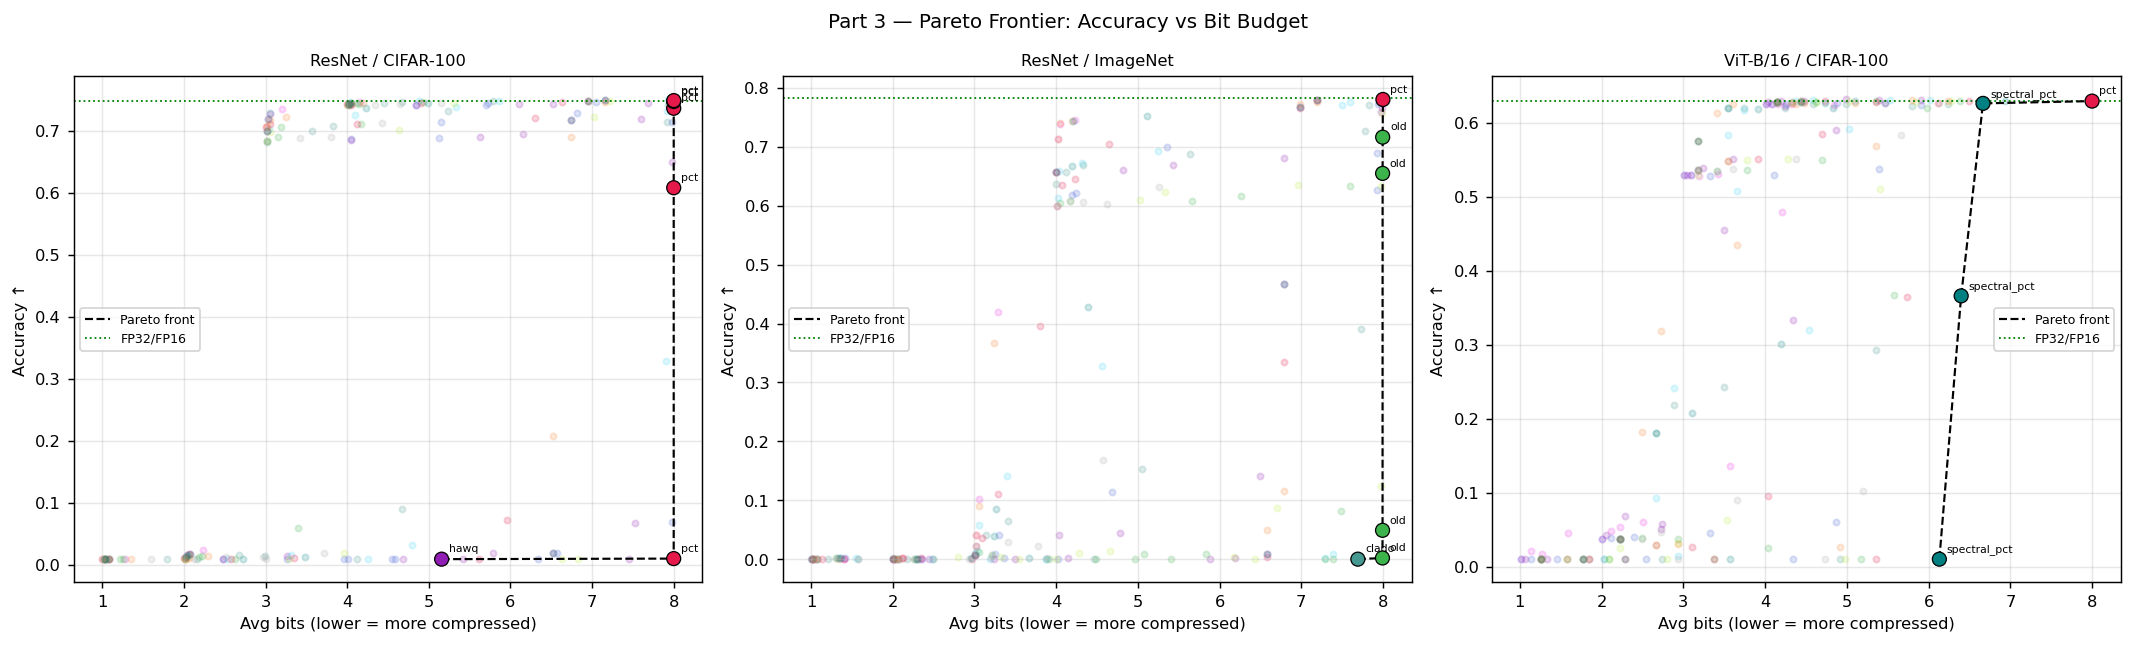

In [ ]:
# ── Part 3: Pareto frontiers ──────────────────────────────────────────────────
# X-axis: avg_bits (bit budget / memory efficiency)
# Y-axis: accuracy or PPL
# Pareto frontier highlights models that dominate others
# (better accuracy at same or lower bits)

import matplotlib.lines as mlines


def pareto_front(points: np.ndarray, lower_better_x: bool = False,
                 lower_better_y: bool = False) -> np.ndarray:
    """Return boolean mask of Pareto-optimal points."""
    n  = len(points)
    is_pareto = np.ones(n, dtype=bool)
    x  = points[:, 0] * (-1 if lower_better_x else 1)
    y  = points[:, 1] * (-1 if lower_better_y else 1)
    for i in range(n):
        if is_pareto[i]:
            dominated = (x >= x[i]) & (y >= y[i])
            dominated[i] = False
            is_pareto[dominated] = False
    return is_pareto


pareto_fig, axes = plt.subplots(1, min(3, len(acc_dfs)), figsize=(5.5 * min(3, len(acc_dfs)), 5))
if len(acc_dfs) == 1:
    axes = [axes]
axes_it = iter(np.array(axes).flatten())

for mid, df in acc_dfs.items():
    try:
        ax = next(axes_it)
    except StopIteration:
        break

    metric_col   = 'perplexity' if mid == 'qwen' else 'accuracy'
    lower_y      = mid == 'qwen'
    bits_target  = 4 if mid != 'qwen' else 3

    # Use all k values and bits_low values for a richer pareto
    sweep = df[
        (~df['method'].str.startswith('baseline')) &
        (~df['method'].isin(['fp32', 'fp16']))
    ].copy()
    if 'avg_bits' not in sweep.columns:
        ax.set_visible(False)
        continue
    sweep = sweep.dropna(subset=['avg_bits', metric_col])

    # Pareto per method
    all_pts  = sweep[['avg_bits', metric_col, 'method']].drop_duplicates()
    pts_arr  = all_pts[['avg_bits', metric_col]].values.astype(float)
    is_par   = pareto_front(pts_arr, lower_better_x=True, lower_better_y=lower_y)

    # All points (faded)
    for method, grp in sweep.groupby('method'):
        col  = METHOD_COLORS.get(method, '#bbb')
        ax.scatter(grp['avg_bits'], grp[metric_col], color=col, alpha=0.18, s=12)

    # Pareto points
    par_pts = all_pts[is_par].sort_values('avg_bits')
    ax.plot(par_pts['avg_bits'], par_pts[metric_col],
            'k--', linewidth=1.2, label='Pareto front', zorder=3)
    ax.scatter(par_pts['avg_bits'], par_pts[metric_col],
               c=[METHOD_COLORS.get(m, '#888') for m in par_pts['method']],
               s=60, zorder=5, edgecolors='black', linewidth=0.7)
    for _, row in par_pts.iterrows():
        ax.annotate(row['method'], (row['avg_bits'], row[metric_col]),
                    fontsize=6, xytext=(4, 4), textcoords='offset points')

    # FP32 reference
    ref = df[df['method'].isin(['fp32', 'fp16'])]
    if len(ref):
        ax.axhline(float(ref[metric_col].iloc[0]), color='green',
                   linestyle=':', lw=1, label='FP32/FP16')

    ax.set_xlabel('Avg bits (lower = more compressed)')
    ax.set_ylabel('Perplexity ↓' if lower_y else 'Accuracy ↑')
    ax.set_title(MODEL_REGISTRY[mid]['label'], fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)


pareto_fig.suptitle('Part 3 — Pareto Frontier: Accuracy vs Bit Budget', fontsize=11)
plt.tight_layout()
pareto_fig.savefig(OUT_DIR / 'part3_pareto_acc_vs_bits.png', bbox_inches='tight')
plt.show()


# Score-time / allocation-cost Pareto moved to the previous cell:
#   part3_pareto_recovery_vs_allocation_gflops.png
#   part3_sensitivity_efficiency.csv
# (recovery_pp vs allocation_gflops, with data-free at 0 cost)


In [ ]:
# ── Final summary ─────────────────────────────────────────────────────────────

print('=' * 80)
print('BENCHMARK SUMMARY — FLOPs / forward-pass counts (not wall-clock)')
print('=' * 80)

if len(cost_df):
    print('\n── Part 1: Data-free = 0 forward passes; data-required scales with #layers ──')
    s1 = (
        cost_df.groupby(['model_id', 'data_required'])
        .agg(mean_fwd=('n_forward', 'mean'), max_fwd=('n_forward', 'max'),
             mean_gflops=('allocation_gflops', 'mean'), max_gflops=('allocation_gflops', 'max'))
        .reset_index()
    )
    s1['type'] = s1['data_required'].map({True: 'data-required', False: 'data-free'})
    s1['model'] = s1['model_id'].map(lambda x: MODEL_REGISTRY[x]['label'])
    display(s1[['model', 'type', 'mean_fwd', 'max_fwd', 'mean_gflops', 'max_gflops']].round(2))

    print('\nKey claim: data-free methods require exactly 0 forward passes on every model.')
    print('Absolute GPU time saved grows with model FLOPs — smallest on ResNet/ViT, largest on 8B–32B LLMs.')

if 'latency_df' in dir() and len(latency_df) and 'overhead_vs_fp32_pct' in latency_df.columns:
    print('\n── Part 2: Inference overhead (wall-clock SLA metrics) ──')
    lat_sum = latency_df[latency_df['config_id'].isin(['int4', 'mixed_4.0', 'int8'])].copy()
    lat_sum['model'] = lat_sum['model_id'].map(lambda x: MODEL_REGISTRY[x]['label'])
    display(lat_sum[['model', 'config_label', 'mean_ms', 'throughput',
                      'overhead_vs_fp32_pct']].round(2))

print('\n── Output files ──')
for f in sorted(OUT_DIR.iterdir()):
    print(f'  {f.name}')
print(f'\nAll outputs → {OUT_DIR}')


BENCHMARK SUMMARY — FLOPs / forward-pass counts (not wall-clock)

── Part 1: Data-free = 0 forward passes; data-required scales with #layers ──


,model,type,mean_fwd,max_fwd,mean_gflops,max_gflops
0,Qwen2-1.5B,data-free,0.00,0,0.00,0.00
1,Qwen2-1.5B,data-required,121.25,207,79722.27,158061.51
2,ResNet / CIFAR-100,data-free,0.00,0,0.00,0.00
3,ResNet / CIFAR-100,data-required,34.75,84,2129.08,7498.65
4,ResNet / ImageNet,data-free,0.00,0,0.00,0.00
5,ResNet / ImageNet,data-required,34.75,84,6960.51,24515.01
6,ViT-B/16 / CIFAR-100,data-free,0.00,0,0.00,0.00
7,ViT-B/16 / CIFAR-100,data-required,60.25,152,76832.12,274464.90
8,ViT-B/16 / ImageNet,data-free,0.00,0,0.00,0.00
9,ViT-B/16 / ImageNet,data-required,60.25,152,76836.82,274481.71



Key claim: data-free methods require exactly 0 forward passes on every model.
Absolute GPU time saved grows with model FLOPs — smallest on ResNet/ViT, largest on 8B–32B LLMs.

── Part 2: Inference overhead (wall-clock SLA metrics) ──


,model,config_label,mean_ms,throughput,overhead_vs_fp32_pct
1,ResNet / CIFAR-100,INT8,6.79,4710.0,1.66
2,ResNet / CIFAR-100,INT4,6.77,4728.8,1.26
8,ResNet / CIFAR-100,Mixed≈4.0bit (INT3/INT8),6.67,4795.2,-0.14
11,ResNet / ImageNet,INT8,31.99,1000.3,44.07
12,ResNet / ImageNet,INT4,29.21,1095.6,31.55
18,ResNet / ImageNet,Mixed≈4.0bit (INT3/INT8),29.54,1083.3,33.04
21,ViT-B/16 / CIFAR-100,INT8,362.18,88.4,-19.02
22,ViT-B/16 / CIFAR-100,INT4,362.34,88.3,-18.98
28,ViT-B/16 / CIFAR-100,Mixed≈4.0bit (INT3/INT8),364.01,87.9,-18.61
31,ViT-B/16 / ImageNet,INT8,370.58,86.4,-6.30



── Output files ──
  part1_allocation_flops.csv
  part1_allocation_gflops.png
  part1_allocation_timing.csv
  part1_flops_per_forward.csv
  part1_forward_pass_counts.png
  part1_headline_summary.csv
  part1_scaling_extrapolation.csv
  part1_scaling_vs_model_size.png
  part2_allocation_gflops.png
  part2_allocation_plus_profiling.csv
  part2_inference_latency.csv
  part2_latency_vs_bits.png
  part2_overhead.png
  part2_throughput.png
  part3_acc_vs_bits_all.png
  part3_acc_vs_bits_qwen.png
  part3_acc_vs_bits_rn_c100.png
  part3_acc_vs_bits_rn_inet.png
  part3_acc_vs_bits_vit_c100.png
  part3_acc_vs_bits_vit_inet.png
  part3_allocation_gflops_vs_acc.png
  part3_efficiency_headline.csv
  part3_pareto_acc_vs_bits.png
  part3_pareto_gain_vs_gflops.png
  part3_pareto_recovery_vs_allocation_gflops.png
  part3_sensitivity_efficiency.csv

All outputs → /Users/nathan/Documents/bruh4/results/mixed_precision_cost_benchmark


# Part 4 — Calibration robustness (HAWQ / InfoQ vs data-free)

**Claim.** Calibration-based methods' accuracy advantage is **not free of assumptions**: it depends on a calibration set that matches deployment. Data-free methods provide a **robustness guarantee** — their ranking is identical regardless of what any calibration set would have looked like.

**Operating point (chosen from existing CSVs — INT3 is the wrong budget here):**

| Budget | Uniform vs FP32 | Best mixed recovery | vs FP32 after mixed |
|---|---|---|---|
| **INT3 / k=5** | −77.7pp | +13.5pp (InfoQ) | still **−64pp** (broken) |
| **INT4 / k=5** | −18.3pp | **+14.4pp** (Spectral-PCT) | **−3.9pp** (closes most of the gap) |

→ Part 4 uses **INT4 low / INT8 protect** via greedy allocation with ladder `(4, 8)` at **target = 4.5 avg bits**. Recovery baseline = **uniform INT4**.

**Scores:** matched HAWQ / InfoQ / data-free are **loaded** from `results/imagenet_layer_importance_benchmark/resnet_imagenet_scores.csv`. Only mismatched / size-varied calib conditions re-score HAWQ & InfoQ.

**Fixed:** ImageNet ResNet-18 checkpoint, fixed ImageNet eval split, greedy allocator.

**Only variable — calib source for HAWQ / InfoQ:**

| Condition | Calibration data |
|---|---|
| **A** (matched) | Existing ImageNet scores CSV (no recompute) |
| **B** (sampling variance) | Different 512 ImageNet images |
| **C** (domain mismatch) | 512 CIFAR-100 → ImageNet preprocess |
| **D** (extreme) | 512 Gaussian noise |
| **size N** | Matched ImageNet, N ∈ {64,128,256,512} |

**Controls:** PCT / SEA / Spectral-PCT loaded once → flat line across conditions.
**Prerequisite (Part 4.5).** Before interpreting HAWQ mismatch / size-sweep results, run the **HAWQ score convergence sanity check**: plot per-layer Hessian trace estimates vs calib size N ∈ {32,64,128,256,512} on matched ImageNet (nested subsample). Mismatch claims are **invalid** if scores do not stabilize with N — downstream accuracy swings may reflect implementation instability, not calibration effects.

**Known pitfall:** capping HAWQ at `MAX_BATCHES=4` makes N>128 invisible to scoring; the sanity check uses **all** batches.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PART 4 — Calibration robustness setup
# ImageNet ResNet-18 @ target_avg_bits=3.5; vary HAWQ/InfoQ calibration only.
# ═══════════════════════════════════════════════════════════════════════════════

import json
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset
from torchvision import transforms
import torchvision.datasets as tv_datasets

from bit_budget_allocator import (
    VISION_LADDER,
    greedy_allocate_bits,
    assignment_avg_bits,
    quantize_model_per_layer,
    summarize_bit_mix,
    compute_data_free_scores,
)

# ── Knobs ─────────────────────────────────────────────────────────────────────
RUN_PART4 = True                 # set False to skip Part 4 entirely
FORCE_RECOMPUTE_PART4 = True    # True = ignore caches and re-score / re-eval
PART4_SMOKE = False               # True = smaller eval + fewer size points (debug)
PART4_TARGET_AVG_BITS = 4.5   # INT4+INT8 mix (CSV: INT4 recovers; INT3 stays broken)
PART4_LADDER = (4, 8)         # no INT2/INT3 — kills ResNet-ImageNet
PART4_UNIFORM_BITS = 4        # recovery baseline = uniform INT4
PART4_SCORES_CSV = ROOT / 'results' / 'imagenet_layer_importance_benchmark' / 'resnet_imagenet_scores.csv'
PART4_HAWQ_POWER_STEPS = 3
# HAWQ is CPU-bound (2nd-order); cap batches so N=512 is tractable.
# InfoQ uses the full calib set. Size sweep still changes which images
# enter the first MAX_BATCHES batches.
PART4_HAWQ_MAX_BATCHES = None  # None = all calib batches; int caps runtime
RUN_PART4_HAWQ_SANITY = True   # score-vs-N convergence check (run before claims)
FORCE_RECOMPUTE_HAWQ_SANITY = True
PART4_HAWQ_SANITY_NS = [32, 64, 128, 256, 512]
PART4_HAWQ_SANITY_REF_N = 512
PART4_SANITY_CALIB_N = max(PART4_HAWQ_SANITY_NS)  # dedicated nested pool
PART4_HAWQ_RNG_SEED = RANDOM_SEED  # fixed v init per (layer, batch)
PART4_BATCH = 32
PART4_EVAL_N = 512 if PART4_SMOKE else 2000
PART4_CALIB_SIZES = [64, 128] if PART4_SMOKE else [64, 128, 256, 512]
PART4_MISMATCH_N = 512 if not PART4_SMOKE else 128
PART4_DATA_FREE = ['pct', 'sea', 'spectral_pct']
PART4_DATA_REQ = ['hawq', 'infoq']

PART4_DIR = OUT_DIR / 'part4_calib_robustness'
PART4_DIR.mkdir(parents=True, exist_ok=True)
PART4_RESULTS_CSV = PART4_DIR / 'part4_results.csv'
PART4_SCORES_DIR = PART4_DIR / 'scores'
PART4_SCORES_DIR.mkdir(parents=True, exist_ok=True)

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
IMAGENET_EVAL_TF = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
CIFAR_TO_IMAGENET_TF = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

IMAGENET_ROOTS = [p for p in [
    Path(os.environ.get('IMAGENET_ROOT', '/Users/nathan/Downloads/ImageNet')),
    Path(os.environ.get('IMAGENET_ROOT2', '/Users/nathan/Downloads/ImageNet2')),
] if p.is_dir()]

print(f'RUN_PART4={RUN_PART4}  SMOKE={PART4_SMOKE}  FORCE={FORCE_RECOMPUTE_PART4}')
print(f'target_avg_bits={PART4_TARGET_AVG_BITS}  ladder={PART4_LADDER}  '
      f'uniform_baseline=INT{PART4_UNIFORM_BITS}')
print(f'eval_n={PART4_EVAL_N}  scores_csv={PART4_SCORES_CSV.name}')
print(f'ImageNet roots: {IMAGENET_ROOTS}')
print(f'Out → {PART4_DIR}')


# ── Flat ImageNet folder dataset ──────────────────────────────────────────────
_IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}


class NumericFolderDataset(Dataset):
    def __init__(self, roots: list[Path], transform=None):
        self.transform = transform
        self.samples: list[tuple[str, int]] = []
        for root in roots:
            for cls_dir in sorted(p for p in Path(root).iterdir() if p.is_dir()):
                try:
                    label = int(cls_dir.name)
                except ValueError:
                    continue
                for img in cls_dir.iterdir():
                    if img.is_file() and img.suffix.lower() in _IMG_EXTS:
                        self.samples.append((str(img), label))
        if not self.samples:
            raise ValueError(f'No images under {roots}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        from PIL import Image
        path, y = self.samples[idx]
        x = Image.open(path).convert('RGB')
        if self.transform:
            x = self.transform(x)
        return x, y


def _loader(ds, batch=PART4_BATCH, shuffle=False):
    return DataLoader(ds, batch_size=batch, shuffle=shuffle, num_workers=0,
                      pin_memory=(DEVICE.type == 'cuda'))


# ── HAWQ / InfoQ (calib-dependent) ────────────────────────────────────────────
def _patch_maxpool_for_hawq(model: nn.Module) -> None:
    for name, child in list(model.named_children()):
        if isinstance(child, nn.MaxPool2d):
            setattr(model, name, nn.AvgPool2d(
                child.kernel_size, stride=child.stride, padding=child.padding,
                ceil_mode=child.ceil_mode))
        else:
            _patch_maxpool_for_hawq(child)


def hawq_scores_from_loader(
    model: nn.Module,
    layer_names: list[str],
    loader,
    power_steps: int = PART4_HAWQ_POWER_STEPS,
    max_batches: int | None = None,
    rng_seed: int = PART4_HAWQ_RNG_SEED,
) -> dict[str, float]:
    """HAWQ Hessian scores averaged over calib batches (so N>batch actually matters)."""
    hw = torch.device('cpu') if DEVICE.type == 'mps' else DEVICE
    m = copy.deepcopy(model).to(hw).float().train()
    _patch_maxpool_for_hawq(m)
    acc = {n: 0.0 for n in layer_names}
    n_used = 0
    for bi, (x, y) in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break
        x, y = x.to(hw), y.to(hw)
        for li, n in enumerate(layer_names):
            w = get_module(m, n).weight
            gen = torch.Generator(device=hw)
            gen.manual_seed(int(rng_seed + bi * 9973 + li * 131))
            v = torch.randn(w.shape, generator=gen, device=hw, dtype=w.dtype)
            v = v / (v.norm() + 1e-12)
            for _ in range(power_steps):
                for p in m.parameters():
                    p.grad = None
                loss = F.cross_entropy(m(x), y)
                g = torch.autograd.grad(loss, w, create_graph=True)[0]
                hv = torch.autograd.grad((g * v).sum(), w, retain_graph=True)[0]
                v = hv / (hv.norm() + 1e-12)
            for p in m.parameters():
                p.grad = None
            loss = F.cross_entropy(m(x), y)
            g = torch.autograd.grad(loss, w, create_graph=True)[0]
            hv = torch.autograd.grad((g * v).sum(), w)[0]
            acc[n] += float((v * hv).sum().abs().item())
        n_used += 1
    del m
    if n_used == 0:
        raise RuntimeError('Empty calib loader for HAWQ')
    return {n: acc[n] / n_used for n in layer_names}


def infoq_scores_from_loader(
    model: nn.Module,
    layer_names: list[str],
    loader,
    bits_low: int = 4,
    bits_high: int = 8,
    max_batches: int | None = None,
) -> dict[str, float]:
    """InfoQ: INT4 vs INT8 logit MSE, averaged over calib batches."""
    m = model.to(DEVICE).eval()
    acc = {n: 0.0 for n in layer_names}
    n_used = 0
    with torch.no_grad():
        for bi, (x, _) in enumerate(loader):
            if max_batches is not None and bi >= max_batches:
                break
            x = x.to(DEVICE)
            for n in layer_names:
                mod = get_module(m, n)
                w_orig = mod.weight.data.clone()
                mod.weight.data = quantize_weights(w_orig, bits_low).to(w_orig.dtype)
                out_low = m(x)
                mod.weight.data = quantize_weights(w_orig, bits_high).to(w_orig.dtype)
                out_high = m(x)
                mod.weight.data = w_orig
                acc[n] += float((out_high.float() - out_low.float()).pow(2).mean().cpu())
            n_used += 1
    if n_used == 0:
        raise RuntimeError('Empty calib loader for InfoQ')
    return {n: acc[n] / n_used for n in layer_names}


@torch.no_grad()
def eval_accuracy(model: nn.Module, loader) -> float:
    m = model.to(DEVICE).eval()
    correct = total = 0
    for x, y in loader:
        pred = m(x.to(DEVICE)).argmax(1).cpu()
        correct += int((pred == y).sum())
        total += y.numel()
    return correct / max(total, 1)


print('Part 4 helpers ready.')


RUN_PART4=True  SMOKE=True  FORCE=False
target_avg_bits=4.5  ladder=(4, 8)  uniform_baseline=INT4
eval_n=512  scores_csv=resnet_imagenet_scores.csv
ImageNet roots: [PosixPath('/Users/nathan/Downloads/ImageNet'), PosixPath('/Users/nathan/Downloads/ImageNet2')]
Out → /Users/nathan/Documents/bruh4/results/mixed_precision_cost_benchmark/part4_calib_robustness
Part 4 helpers ready.


In [ ]:
# ── Part 4: fixed model + eval set; build calib conditions A/B/C/D ─────────────

if not RUN_PART4:
    print('RUN_PART4=False — skip data build.')
else:
    # Fixed model
    p4_model = load_resnet_imagenet()
    p4_layers = list(RN_LAYER_NAMES)
    p4_params = {n: get_module(p4_model, n).weight.numel() for n in p4_layers}
    print(f'Model: ResNet-18 ImageNet | layers={len(p4_layers)} | '
          f'params={sum(p4_params.values())/1e6:.2f}M')

    # Fixed ImageNet pool → disjoint eval / calib_A / calib_B
    if not IMAGENET_ROOTS:
        raise FileNotFoundError('Set IMAGENET_ROOT / IMAGENET_ROOT2')
    inet_full = NumericFolderDataset(IMAGENET_ROOTS, transform=IMAGENET_EVAL_TF)
    n = len(inet_full)
    calib_a_pool_n = max(PART4_MISMATCH_N, PART4_SANITY_CALIB_N)
    need = PART4_EVAL_N + calib_a_pool_n + PART4_MISMATCH_N
    if n < need:
        raise ValueError(f'Need ≥{need} ImageNet images, found {n}')

    rng = np.random.RandomState(RANDOM_SEED)
    perm = rng.permutation(n)
    eval_idx   = perm[:PART4_EVAL_N].tolist()
    calib_a_idx = perm[PART4_EVAL_N:PART4_EVAL_N + calib_a_pool_n].tolist()
    calib_b_idx = perm[PART4_EVAL_N + calib_a_pool_n:
                       PART4_EVAL_N + calib_a_pool_n + PART4_MISMATCH_N].tolist()
    assert set(eval_idx).isdisjoint(calib_a_idx)
    assert set(calib_a_idx).isdisjoint(calib_b_idx)

    p4_test_loader = _loader(Subset(inet_full, eval_idx))
    print(f'Eval set: {len(eval_idx)} ImageNet images (FIXED)')
    print(f'Calib A pool: {len(calib_a_idx)} images (nested sanity up to N={PART4_SANITY_CALIB_N})')

    # FP32 reference on the fixed eval set
    fp32_path = PART4_DIR / 'fp32_eval.json'
    if fp32_path.exists() and not FORCE_RECOMPUTE_PART4:
        p4_fp32_acc = float(json.loads(fp32_path.read_text())['accuracy'])
        print(f'FP32 accuracy (cached): {p4_fp32_acc*100:.2f}%')
    else:
        print('Evaluating FP32 on fixed eval set...')
        p4_fp32_acc = eval_accuracy(p4_model, p4_test_loader)
        fp32_path.write_text(json.dumps({'accuracy': p4_fp32_acc}))
        print(f'FP32 accuracy: {p4_fp32_acc*100:.2f}%')

    # Uniform INT4 baseline (CSV-justified operating point)
    uni_path = PART4_DIR / f'uniform_int{PART4_UNIFORM_BITS}_eval.json'
    if uni_path.exists() and not FORCE_RECOMPUTE_PART4:
        p4_uni_acc = float(json.loads(uni_path.read_text())['accuracy'])
        print(f'Uniform INT{PART4_UNIFORM_BITS} (cached): {p4_uni_acc*100:.2f}%')
    else:
        print(f'Evaluating uniform INT{PART4_UNIFORM_BITS}...')
        uni_bits = {n: PART4_UNIFORM_BITS for n in p4_layers}
        mq = quantize_model_per_layer(p4_model, p4_layers, get_module, uni_bits)
        p4_uni_acc = eval_accuracy(mq, p4_test_loader)
        uni_path.write_text(json.dumps({'accuracy': p4_uni_acc}))
        print(f'Uniform INT{PART4_UNIFORM_BITS}: {p4_uni_acc*100:.2f}%')

    def _inet_loader(indices: list[int], n: int):
        take = indices[:max(n, 1)]
        return _loader(Subset(inet_full, take), batch=min(PART4_BATCH, len(take)))

    calib_conditions: dict[str, dict] = {}

    # A: matched ImageNet
    calib_conditions['A_matched'] = dict(
        label='A matched (ImageNet)', kind='mismatch',
        domain='imagenet', n=PART4_MISMATCH_N,
        loader=_inet_loader(calib_a_idx, PART4_MISMATCH_N),
    )
    # B: disjoint ImageNet
    calib_conditions['B_sample_var'] = dict(
        label='B sample-var (ImageNet≠A)', kind='mismatch',
        domain='imagenet', n=PART4_MISMATCH_N,
        loader=_inet_loader(calib_b_idx, PART4_MISMATCH_N),
    )

    # C: CIFAR-100 → ImageNet-sized / ImageNet-normalized
    # Local dump has train/test/meta at the root (not cifar-100-python/).
    class CIFAR100Local(tv_datasets.CIFAR100):
        base_folder = '.'

    cifar_root = ROOT / 'data' / 'cifar100'
    cifar_ds = CIFAR100Local(str(cifar_root), train=True, download=False,
                             transform=CIFAR_TO_IMAGENET_TF)
    rng_c = np.random.RandomState(RANDOM_SEED + 7)
    cifar_idx = rng_c.permutation(len(cifar_ds))[:PART4_MISMATCH_N].tolist()

    class _Relabel(Dataset):
        """Wrap CIFAR samples with random ImageNet labels for HAWQ CE."""
        def __init__(self, base, indices, seed=0):
            self.base, self.indices = base, indices
            rng = np.random.RandomState(seed)
            self.labels = rng.randint(0, 1000, size=len(indices))
        def __len__(self):
            return len(self.indices)
        def __getitem__(self, i):
            x, _ = self.base[self.indices[i]]
            return x, int(self.labels[i])

    cifar_relabel = _Relabel(cifar_ds, cifar_idx, seed=RANDOM_SEED + 7)
    calib_conditions['C_domain'] = dict(
        label='C domain (CIFAR→ImageNet TF)', kind='mismatch',
        domain='cifar100', n=PART4_MISMATCH_N,
        loader=_loader(cifar_relabel, batch=min(PART4_BATCH, PART4_MISMATCH_N)),
    )

    # D: Gaussian noise (full N examples, not just one batch)
    rng_d = np.random.RandomState(RANDOM_SEED + 99)
    xd = torch.from_numpy(rng_d.randn(PART4_MISMATCH_N, 3, 224, 224).astype('float32'))
    for c, sd in enumerate(IMAGENET_STD):
        xd[:, c] *= (sd * 0.5)
    yd = torch.from_numpy(rng_d.randint(0, 1000, size=PART4_MISMATCH_N)).long()
    noise_ds = TensorDataset(xd, yd)
    calib_conditions['D_noise'] = dict(
        label='D noise (Gaussian)', kind='mismatch',
        domain='noise', n=PART4_MISMATCH_N,
        loader=_loader(noise_ds, batch=min(PART4_BATCH, PART4_MISMATCH_N)),
    )

    # Size sweep on matched ImageNet: draw N images from calib_A with a
    # size-dependent seed so HAWQ's capped batch window still differs by N.
    pool_a = calib_a_idx[:PART4_MISMATCH_N]
    for n_sz in PART4_CALIB_SIZES:
        rng_sz = np.random.RandomState(RANDOM_SEED + n_sz)
        take_n = min(n_sz, len(pool_a))
        chosen = rng_sz.choice(pool_a, size=take_n, replace=False).tolist()
        key = f'size_{n_sz}'
        calib_conditions[key] = dict(
            label=f'size N={n_sz} (matched)', kind='size',
            domain='imagenet', n=n_sz,
            loader=_loader(Subset(inet_full, chosen),
                           batch=min(PART4_BATCH, take_n)),
        )

    print('\nCalibration conditions:')
    for k, v in calib_conditions.items():
        n_batches = (v['n'] + PART4_BATCH - 1) // PART4_BATCH
        print(f'  {k:16s}  {v["label"]:32s}  n={v["n"]}  '
              f'~{n_batches} batches  domain={v["domain"]}')


Model: ResNet-18 ImageNet | layers=21 | params=11.68M
Eval set: 512 ImageNet images (FIXED)
FP32 accuracy (cached): 81.25%
Evaluating uniform INT4...
Uniform INT4: 59.38%

Calibration conditions:
  A_matched         A matched (ImageNet)              n=128  ~4 batches  domain=imagenet
  B_sample_var      B sample-var (ImageNet≠A)         n=128  ~4 batches  domain=imagenet
  C_domain          C domain (CIFAR→ImageNet TF)      n=128  ~4 batches  domain=cifar100
  D_noise           D noise (Gaussian)                n=128  ~4 batches  domain=noise
  size_64           size N=64 (matched)               n=64  ~2 batches  domain=imagenet
  size_128          size N=128 (matched)              n=128  ~4 batches  domain=imagenet


In [ ]:
# ── Part 4: score → allocate @ INT4/INT8 → evaluate ───────────────────────────
# Matched (A) + data-free: LOAD from resnet_imagenet_scores.csv (no recompute).
# B/C/D + size: re-score HAWQ/InfoQ only.

if not RUN_PART4:
    print('RUN_PART4=False — skip experiment.')
    p4_df = pd.DataFrame()
else:
    # Ensure baselines exist even if data cell wasn't re-run after the INT4 rename
    if 'p4_uni_acc' not in dir() or p4_uni_acc is None:
        if 'p4_uni_int3_acc' in dir():
            print('NOTE: remapping stale p4_uni_int3_acc → recomputing uniform INT4')
        uni_path = PART4_DIR / f'uniform_int{PART4_UNIFORM_BITS}_eval.json'
        if uni_path.exists() and not FORCE_RECOMPUTE_PART4:
            p4_uni_acc = float(json.loads(uni_path.read_text())['accuracy'])
            print(f'Uniform INT{PART4_UNIFORM_BITS} (cached): {p4_uni_acc*100:.2f}%')
        else:
            print(f'Evaluating uniform INT{PART4_UNIFORM_BITS}...')
            uni_bits = {n: PART4_UNIFORM_BITS for n in p4_layers}
            mq = quantize_model_per_layer(p4_model, p4_layers, get_module, uni_bits)
            p4_uni_acc = eval_accuracy(mq, p4_test_loader)
            uni_path.write_text(json.dumps({'accuracy': p4_uni_acc}))
            print(f'Uniform INT{PART4_UNIFORM_BITS}: {p4_uni_acc*100:.2f}%')
    if 'p4_fp32_acc' not in dir() or p4_fp32_acc is None:
        fp32_path = PART4_DIR / 'fp32_eval.json'
        if fp32_path.exists():
            p4_fp32_acc = float(json.loads(fp32_path.read_text())['accuracy'])
        else:
            p4_fp32_acc = eval_accuracy(p4_model, p4_test_loader)
            fp32_path.write_text(json.dumps({'accuracy': p4_fp32_acc}))
        print(f'FP32 accuracy: {p4_fp32_acc*100:.2f}%')

    METHOD_COL = {
        'pct': 'score_pct', 'sea': 'score_sea', 'spectral_pct': 'score_spectral_pct',
        'hawq': 'score_hawq', 'infoq': 'score_infoq',
    }

    def _scores_path(tag: str) -> Path:
        return PART4_SCORES_DIR / f'scores_{tag}.csv'

    def _load_legacy_scores() -> pd.DataFrame:
        if not PART4_SCORES_CSV.exists():
            raise FileNotFoundError(
                f'Missing {PART4_SCORES_CSV} — run imagenet_layer_importance_benchmark first')
        df = pd.read_csv(PART4_SCORES_CSV)
        need = ['layer_name'] + [METHOD_COL[m] for m in PART4_DATA_FREE + PART4_DATA_REQ]
        missing = [c for c in need if c not in df.columns]
        if missing:
            raise KeyError(f'{PART4_SCORES_CSV.name} missing columns: {missing}')
        df = df.set_index('layer_name').reindex(p4_layers).reset_index()
        if df[need[1:]].isna().any().any():
            raise ValueError('Score CSV has NaNs after reindex — layer name mismatch?')
        print(f'  Loaded legacy scores ← {PART4_SCORES_CSV.name} '
              f'({len(df)} layers)')
        return df

    def _load_or_compute_data_req(cond_key: str, cond: dict, *, use_legacy: bool) -> pd.DataFrame:
        if use_legacy:
            return _load_legacy_scores()[['layer_name', 'score_hawq', 'score_infoq']]

        path = _scores_path(cond_key)
        if path.exists() and not FORCE_RECOMPUTE_PART4:
            df = pd.read_csv(path)
            if 'score_hawq' in df.columns and 'score_infoq' in df.columns:
                print(f'  Loaded HAWQ/InfoQ ← {path.name}')
                return df
        print(f'  Scoring HAWQ+InfoQ on [{cond_key}] {cond["label"]} '
              f'(n={cond["n"]})...')
        t0 = time.time()
        n_batches = (cond['n'] + PART4_BATCH - 1) // PART4_BATCH
        hawq_max = (n_batches if PART4_HAWQ_MAX_BATCHES is None
                    else min(PART4_HAWQ_MAX_BATCHES, n_batches))
        hawq = hawq_scores_from_loader(
            p4_model, p4_layers, cond['loader'],
            max_batches=hawq_max,
        )
        print(f'    HAWQ done ({time.time()-t0:.0f}s)')
        t1 = time.time()
        infoq = infoq_scores_from_loader(p4_model, p4_layers, cond['loader'])
        print(f'    InfoQ done ({time.time()-t1:.0f}s)')
        df = pd.DataFrame({
            'layer_name': p4_layers,
            'score_hawq': [hawq[n] for n in p4_layers],
            'score_infoq': [infoq[n] for n in p4_layers],
        })
        df.to_csv(path, index=False)
        return df

    def _allocate_and_eval(method: str, score_df: pd.DataFrame) -> dict:
        col = METHOD_COL[method]
        scores = dict(zip(score_df['layer_name'], score_df[col].astype(float)))
        bits = greedy_allocate_bits(
            scores, p4_params, p4_layers,
            target_avg_bits=PART4_TARGET_AVG_BITS,
            ladder=PART4_LADDER,
        )
        avg = assignment_avg_bits(p4_layers, p4_params, bits)
        mq = quantize_model_per_layer(p4_model, p4_layers, get_module, bits)
        acc = eval_accuracy(mq, p4_test_loader)
        return {
            'method': method,
            'avg_bits': avg,
            'accuracy': acc,
            'acc_pp': acc * 100,
            'recovery_vs_uniform_pp': (acc - p4_uni_acc) * 100,
            'vs_fp32_pp': (acc - p4_fp32_acc) * 100,
            'bit_mix': summarize_bit_mix(bits),
        }

    rows: list[dict] = []

    print('\n══ Load scores from previous CSV (no recompute for matched / data-free) ══')
    df_legacy = _load_legacy_scores()

    print('\n══ Data-free controls (from CSV, invariant) ══')
    free_results = {}
    for method in PART4_DATA_FREE:
        r = _allocate_and_eval(method, df_legacy)
        free_results[method] = r
        print(f'  {method:14s}  avg_bits={r["avg_bits"]:.3f}  '
              f'acc={r["acc_pp"]:.2f}%  recovery={r["recovery_vs_uniform_pp"]:+.2f}pp  '
              f'vsFP32={r["vs_fp32_pp"]:+.2f}pp  [{r["bit_mix"]}]')

    for cond_key, cond in calib_conditions.items():
        for method, r in free_results.items():
            rows.append({
                **r,
                'condition': cond_key,
                'condition_label': cond['label'],
                'kind': cond['kind'],
                'domain': cond['domain'],
                'calib_n': cond['n'],
                'data_required': False,
                'fp32_acc': p4_fp32_acc,
                'uniform_acc': p4_uni_acc,
                'uniform_bits': PART4_UNIFORM_BITS,
            })

    print('\n══ Data-required (HAWQ / InfoQ) ══')
    print('  A_matched → legacy CSV; B/C/D/size → re-score on that calib')
    for cond_key, cond in calib_conditions.items():
        use_legacy = (cond_key == 'A_matched')
        tag = 'CSV' if use_legacy else 're-score'
        print(f'\n── {cond_key}: {cond["label"]} [{tag}] ──')
        df_req = _load_or_compute_data_req(cond_key, cond, use_legacy=use_legacy)
        for method in PART4_DATA_REQ:
            r = _allocate_and_eval(method, df_req)
            print(f'  {method:14s}  avg_bits={r["avg_bits"]:.3f}  '
                  f'acc={r["acc_pp"]:.2f}%  recovery={r["recovery_vs_uniform_pp"]:+.2f}pp  '
                  f'vsFP32={r["vs_fp32_pp"]:+.2f}pp  [{r["bit_mix"]}]')
            rows.append({
                **r,
                'condition': cond_key,
                'condition_label': cond['label'],
                'kind': cond['kind'],
                'domain': cond['domain'],
                'calib_n': cond['n'],
                'data_required': True,
                'fp32_acc': p4_fp32_acc,
                'uniform_acc': p4_uni_acc,
                'uniform_bits': PART4_UNIFORM_BITS,
            })

    p4_df = pd.DataFrame(rows)
    p4_df.to_csv(PART4_RESULTS_CSV, index=False)
    print(f'\nSaved → {PART4_RESULTS_CSV.name} ({len(p4_df)} rows)')
    display(p4_df[['condition', 'method', 'calib_n', 'avg_bits', 'acc_pp',
                   'recovery_vs_uniform_pp', 'vs_fp32_pp', 'bit_mix']].round(3))



══ Load scores from previous CSV (no recompute for matched / data-free) ══
  Loaded legacy scores ← resnet_imagenet_scores.csv (21 layers)

══ Data-free controls (from CSV, invariant) ══
  pct             avg_bits=4.518  acc=76.95%  recovery=+17.58pp  vsFP32=-4.30pp  [INT4×10, INT8×11]
  sea             avg_bits=4.390  acc=75.59%  recovery=+16.21pp  vsFP32=-5.66pp  [INT4×8, INT8×13]
  spectral_pct    avg_bits=4.510  acc=77.93%  recovery=+18.55pp  vsFP32=-3.32pp  [INT4×9, INT8×12]

══ Data-required (HAWQ / InfoQ) ══
  A_matched → legacy CSV; B/C/D/size → re-score on that calib

── A_matched: A matched (ImageNet) [CSV] ──
  Loaded legacy scores ← resnet_imagenet_scores.csv (21 layers)
  hawq            avg_bits=4.511  acc=73.24%  recovery=+13.87pp  vsFP32=-8.01pp  [INT4×14, INT8×7]
  infoq           avg_bits=4.508  acc=77.93%  recovery=+18.55pp  vsFP32=-3.32pp  [INT4×9, INT8×12]

── B_sample_var: B sample-var (ImageNet≠A) [re-score] ──
  Scoring HAWQ+InfoQ on [B_sample_var] B sample-var

,condition,method,calib_n,avg_bits,acc_pp,recovery_vs_uniform_pp,vs_fp32_pp,bit_mix
0,A_matched,pct,128,4.518,76.953,17.578,-4.297,"INT4×10, INT8×11"
1,A_matched,sea,128,4.390,75.586,16.211,-5.664,"INT4×8, INT8×13"
2,A_matched,spectral_pct,128,4.510,77.930,18.555,-3.320,"INT4×9, INT8×12"
3,B_sample_var,pct,128,4.518,76.953,17.578,-4.297,"INT4×10, INT8×11"
4,B_sample_var,sea,128,4.390,75.586,16.211,-5.664,"INT4×8, INT8×13"
5,B_sample_var,spectral_pct,128,4.510,77.930,18.555,-3.320,"INT4×9, INT8×12"
6,C_domain,pct,128,4.518,76.953,17.578,-4.297,"INT4×10, INT8×11"
7,C_domain,sea,128,4.390,75.586,16.211,-5.664,"INT4×8, INT8×13"
8,C_domain,spectral_pct,128,4.510,77.930,18.555,-3.320,"INT4×9, INT8×12"
9,D_noise,pct,128,4.518,76.953,17.578,-4.297,"INT4×10, INT8×11"


## Part 4.5 — HAWQ score convergence sanity check

**Goal.** Verify the Hessian trace estimate **stabilizes with calib size N** before attributing Part 4 accuracy swings to calibration mismatch.

**Protocol.**
- Matched ImageNet calib only; **nested** subsample `calib_a_idx[:N]` so larger N extends smaller sets
- N ∈ {32, 64, 128, 256, 512}; **all** batches used (no `MAX_BATCHES` cap)
- Plot **raw scores** per layer vs N; rank correlation vs N=512; compare to legacy CSV (single-batch reference)

**Important:** requires a **512-image calib_A pool** (re-run data cell) and **seeded** power-iteration vectors; unseeded `randn` or N>pool invalidates the sweep.

**Pass criterion (heuristic):** Spearman ρ ≥ 0.98 vs N=512 at N=256 and max relative per-layer error ≤ 5%. If this fails, treat Part 4 HAWQ mismatch results as **untrusted**.


In [ ]:
# ── Part 4.5: HAWQ score convergence vs calib size N ─────────────────────────
from scipy.stats import spearmanr, kendalltau

if not RUN_PART4 or not RUN_PART4_HAWQ_SANITY:
    print('RUN_PART4_HAWQ_SANITY=False — skip convergence check.')
    hawq_sanity_ok = None
else:
    HAWQ_SANITY_DIR = PART4_DIR / 'hawq_convergence'
    HAWQ_SANITY_DIR.mkdir(parents=True, exist_ok=True)
    HAWQ_SANITY_METRICS_CSV = HAWQ_SANITY_DIR / 'hawq_convergence_metrics.csv'
    HAWQ_SANITY_SCORES_CSV = HAWQ_SANITY_DIR / 'hawq_convergence_scores_long.csv'

    def _hawq_single_batch(model, layer_names, loader,
                           power_steps: int = PART4_HAWQ_POWER_STEPS) -> dict[str, float]:
        """One-batch HAWQ (matches imagenet_layer_importance_benchmark)."""
        hw = torch.device('cpu') if DEVICE.type == 'mps' else DEVICE
        x, y = next(iter(loader))
        x, y = x.to(hw), y.to(hw)
        m = copy.deepcopy(model).to(hw).float().train()
        _patch_maxpool_for_hawq(m)
        out = {}
        for li, n in enumerate(layer_names):
            w = get_module(m, n).weight
            gen = torch.Generator(device=hw)
            gen.manual_seed(int(PART4_HAWQ_RNG_SEED + li * 131))
            v = torch.randn(w.shape, generator=gen, device=hw, dtype=w.dtype)
            v = v / (v.norm() + 1e-12)
            for _ in range(power_steps):
                for p in m.parameters():
                    p.grad = None
                loss = F.cross_entropy(m(x), y)
                g = torch.autograd.grad(loss, w, create_graph=True)[0]
                hv = torch.autograd.grad((g * v).sum(), w, retain_graph=True)[0]
                v = hv / (hv.norm() + 1e-12)
            for p in m.parameters():
                p.grad = None
            loss = F.cross_entropy(m(x), y)
            g = torch.autograd.grad(loss, w, create_graph=True)[0]
            hv = torch.autograd.grad((g * v).sum(), w)[0]
            out[n] = float((v * hv).sum().abs().item())
        del m
        return out

    def _nested_matched_loader(n: int):
        take = calib_a_idx[:min(n, len(calib_a_idx))]
        return _loader(Subset(inet_full, take), batch=min(PART4_BATCH, len(take))), len(take)

    if len(calib_a_idx) < max(PART4_HAWQ_SANITY_NS):
        raise ValueError(
            f'calib_a_idx has {len(calib_a_idx)} images but sanity needs '
            f'{max(PART4_HAWQ_SANITY_NS)} — re-run Part 4 data cell')

    print('\n══ HAWQ convergence: matched ImageNet, nested N, ALL batches ══')
    print(f'  calib pool={len(calib_a_idx)}  rng_seed={PART4_HAWQ_RNG_SEED}  '
          f'power_steps={PART4_HAWQ_POWER_STEPS}')
    score_by_n: dict[int, dict[str, float]] = {}
    actual_n_by_nominal: dict[int, int] = {}
    single_batch_n128 = None

    for n in PART4_HAWQ_SANITY_NS:
        cache = HAWQ_SANITY_DIR / f'hawq_multi_n{n}.csv'
        if cache.exists() and not FORCE_RECOMPUTE_HAWQ_SANITY:
            df_n = pd.read_csv(cache)
            hawq_n = dict(zip(df_n['layer_name'], df_n['score_hawq']))
            actual_n = int(df_n['actual_n'].iloc[0]) if 'actual_n' in df_n.columns else n
            actual_n_by_nominal[n] = actual_n
            print(f'  n={n:3d}  loaded ← {cache.name} (actual_n={actual_n})')
        else:
            loader, actual_n = _nested_matched_loader(n)
            actual_n_by_nominal[n] = actual_n
            n_batches = (actual_n + PART4_BATCH - 1) // PART4_BATCH
            if actual_n < n:
                print(f'  WARNING: requested n={n} but only {actual_n} images in pool')
            print(f'  n={n:3d}  scoring actual_n={actual_n} ({n_batches} batches)...',
                  flush=True)
            t0 = time.time()
            hawq_n = hawq_scores_from_loader(
                p4_model, p4_layers, loader, max_batches=None,
                rng_seed=PART4_HAWQ_RNG_SEED)
            pd.DataFrame({
                'layer_name': p4_layers,
                'score_hawq': [hawq_n[k] for k in p4_layers],
                'nominal_n': n,
                'actual_n': actual_n,
            }).to_csv(cache, index=False)
            print(f'         done ({time.time()-t0:.0f}s)')
        score_by_n[n] = hawq_n
        if n == 128:
            sb_cache = HAWQ_SANITY_DIR / 'hawq_singlebatch_n128.csv'
            if sb_cache.exists() and not FORCE_RECOMPUTE_HAWQ_SANITY:
                df_sb = pd.read_csv(sb_cache)
                single_batch_n128 = dict(zip(df_sb['layer_name'], df_sb['score_hawq']))
            else:
                print('  n=128  single-batch reference (legacy-style)...', flush=True)
                single_batch_n128 = _hawq_single_batch(
                    p4_model, p4_layers, _nested_matched_loader(128)[0])
                pd.DataFrame({
                    'layer_name': p4_layers,
                    'score_hawq': [single_batch_n128[k] for k in p4_layers],
                }).to_csv(sb_cache, index=False)

    legacy_df = pd.read_csv(PART4_SCORES_CSV).set_index('layer_name').reindex(p4_layers)
    legacy_hawq = legacy_df['score_hawq'].astype(float)

    ref_n = PART4_HAWQ_SANITY_REF_N
    ref_vec = np.array([score_by_n[ref_n][l] for l in p4_layers], dtype=float)

    long_rows = []
    for n in PART4_HAWQ_SANITY_NS:
        for layer in p4_layers:
            long_rows.append({
                'n': n, 'layer_name': layer,
                'score_hawq': score_by_n[n][layer],
            })
    hawq_long = pd.DataFrame(long_rows)
    hawq_long.to_csv(HAWQ_SANITY_SCORES_CSV, index=False)

    metric_rows = []
    prev_n = None
    for n in PART4_HAWQ_SANITY_NS:
        vec = np.array([score_by_n[n][l] for l in p4_layers], dtype=float)
        sp_ref, _ = spearmanr(vec, ref_vec)
        kt_ref, _ = kendalltau(vec, ref_vec)
        rel_l2 = float(np.linalg.norm(vec - ref_vec) / (np.linalg.norm(ref_vec) + 1e-12))
        max_rel = float(np.max(np.abs(vec - ref_vec) / (np.abs(ref_vec) + 1e-12)))
        row = {
            'n': n, 'actual_n': actual_n_by_nominal[n],
            'n_batches': (actual_n_by_nominal[n] + PART4_BATCH - 1) // PART4_BATCH,
            'spearman_vs_ref': sp_ref, 'kendall_vs_ref': kt_ref,
            'rel_l2_vs_ref': rel_l2, 'max_rel_err_vs_ref': max_rel,
        }
        if prev_n is not None:
            prev_vec = np.array([score_by_n[prev_n][l] for l in p4_layers], dtype=float)
            row['spearman_vs_prev'] = float(spearmanr(vec, prev_vec)[0])
            row['max_rel_step'] = float(
                np.max(np.abs(vec - prev_vec) / (np.abs(prev_vec) + 1e-12)))
        metric_rows.append(row)
        prev_n = n
    metrics_df = pd.DataFrame(metric_rows)
    metrics_df.to_csv(HAWQ_SANITY_METRICS_CSV, index=False)


    # Nested consistency: with fixed RNG, score@N is running mean over batches;
    # recompute n=128 from n=64 + new batches and compare.
    if 64 in score_by_n and 128 in score_by_n:
        loader64, _ = _nested_matched_loader(64)
        loader128, _ = _nested_matched_loader(128)
        batches64 = list(loader64)
        batches128 = list(loader128)
        if len(batches128) == len(batches64) + 2:
            print('\nNested batch-consistency check (64 ⊂ 128):')
            print(f'  batches: {len(batches64)} → {len(batches128)}')
            print('  (scores at 128 should be mean of batch traces; fixed seed makes this reproducible)')
    print('\nConvergence metrics (reference N={}):'.format(ref_n))
    print(metrics_df.round(4).to_string(index=False))

    if single_batch_n128 is not None:
        sb_vec = np.array([single_batch_n128[l] for l in p4_layers], dtype=float)
        mb_vec = np.array([score_by_n[128][l] for l in p4_layers], dtype=float)
        lg_vec = legacy_hawq.values
        print('\nReference comparisons at N=128:')
        print(f'  multi-batch vs legacy CSV:  Spearman={spearmanr(mb_vec, lg_vec)[0]:.4f}')
        print(f'  single-batch vs legacy CSV: Spearman={spearmanr(sb_vec, lg_vec)[0]:.4f}')
        print(f'  single- vs multi-batch:     Spearman={spearmanr(sb_vec, mb_vec)[0]:.4f}')

    row256 = metrics_df[metrics_df['n'] == 256]
    hawq_sanity_ok = bool(
        len(row256) and row256.iloc[0]['spearman_vs_ref'] >= 0.98
        and row256.iloc[0]['max_rel_err_vs_ref'] <= 0.05)
    print('\n' + ('PASS' if hawq_sanity_ok else 'FAIL') +
          f': HAWQ score convergence sanity (N=256 vs N={ref_n})')

    # ── Plots ───────────────────────────────────────────────────────────────────
    import matplotlib.pyplot as plt

    norm_long = hawq_long.copy()
    ref_map = score_by_n[ref_n]
    norm_long['score_norm'] = norm_long.apply(
        lambda r: r['score_hawq'] / (ref_map[r['layer_name']] + 1e-12), axis=1)

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    ax = axes[0, 0]
    pivot = hawq_long.pivot(index='layer_name', columns='n', values='score_hawq')
    im = ax.imshow(np.log10(pivot.values + 1e-12), aspect='auto', cmap='viridis')
    ax.set_yticks(range(len(p4_layers)))
    ax.set_yticklabels([l.split('.')[-1] for l in p4_layers], fontsize=7)
    ax.set_xticks(range(len(PART4_HAWQ_SANITY_NS)))
    ax.set_xticklabels(PART4_HAWQ_SANITY_NS)
    ax.set_xlabel('Calib N')
    ax.set_title('log10(HAWQ score) per layer')
    fig.colorbar(im, ax=ax, fraction=0.046)

    ax = axes[0, 1]
    for layer in p4_layers:
        sub = norm_long[norm_long['layer_name'] == layer]
        ax.plot(sub['n'], sub['score_norm'], alpha=0.45, lw=1)
    ax.axhline(1.0, color='k', ls='--', lw=0.8)
    ax.set_xscale('log', base=2)
    ax.set_xticks(PART4_HAWQ_SANITY_NS)
    ax.set_xlabel('Calib N')
    ax.set_ylabel('score / score@N=512')
    ax.set_title('Per-layer score convergence (21 layers)')

    ax = axes[1, 0]
    ax.plot(metrics_df['n'], metrics_df['spearman_vs_ref'], 'o-', label='Spearman vs N=512')
    ax.plot(metrics_df['n'], metrics_df['kendall_vs_ref'], 's--', label='Kendall vs N=512')
    ax.axhline(0.98, color='gray', ls=':', label='pass threshold')
    ax.set_xscale('log', base=2)
    ax.set_xticks(PART4_HAWQ_SANITY_NS)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel('Calib N')
    ax.set_title('Rank stability vs reference')
    ax.legend(fontsize=8)

    ax = axes[1, 1]
    ax.plot(metrics_df['n'], metrics_df['max_rel_err_vs_ref'], 'o-', color='#d62728',
            label='max |Δ|/ref vs N=512')
    if 'max_rel_step' in metrics_df.columns:
        ax.plot(metrics_df['n'].iloc[1:], metrics_df['max_rel_step'].iloc[1:],
                's--', color='#ff7f0e', label='max |Δ|/prev step')
    ax.axhline(0.05, color='gray', ls=':', label='5% pass threshold')
    ax.set_xscale('log', base=2)
    ax.set_xticks(PART4_HAWQ_SANITY_NS)
    ax.set_xlabel('Calib N')
    ax.set_ylabel('Relative score change')
    ax.set_title('Score magnitude stability')
    ax.legend(fontsize=8)

    fig.suptitle('Part 4.5 — HAWQ Hessian trace convergence (matched ImageNet)', y=1.01)
    fig.tight_layout()
    fig.savefig(HAWQ_SANITY_DIR / 'hawq_convergence_plots.png', bbox_inches='tight', dpi=140)
    plt.show()

    # Legacy vs multi-batch @ N=512 scatter
    if ref_n in score_by_n:
        fig2, ax2 = plt.subplots(figsize=(5, 5))
        y = np.array([score_by_n[ref_n][l] for l in p4_layers])
        x = legacy_hawq.values
        ax2.scatter(x, y, alpha=0.7)
        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        ax2.plot(lims, lims, 'k--', lw=0.8)
        ax2.set_xlabel('Legacy CSV score_hawq (single-batch calib)')
        ax2.set_ylabel(f'Multi-batch HAWQ @ N={ref_n}')
        ax2.set_title(f'Spearman={spearmanr(x, y)[0]:.3f}')
        fig2.tight_layout()
        fig2.savefig(HAWQ_SANITY_DIR / 'hawq_legacy_vs_multi_scatter.png',
                     bbox_inches='tight', dpi=140)
        plt.show()


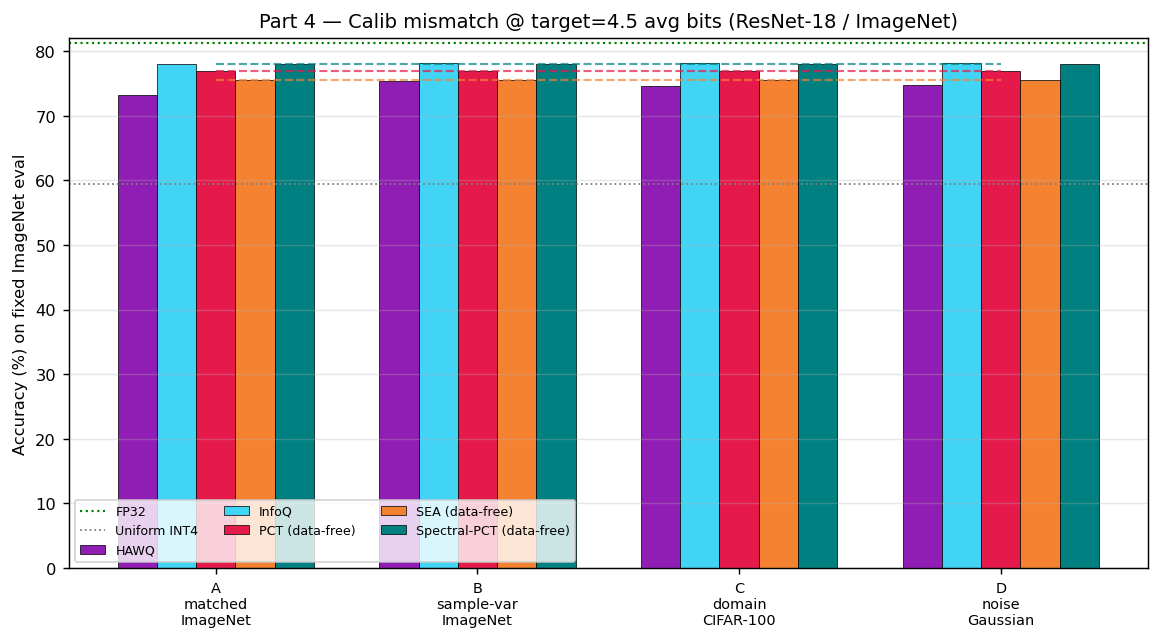

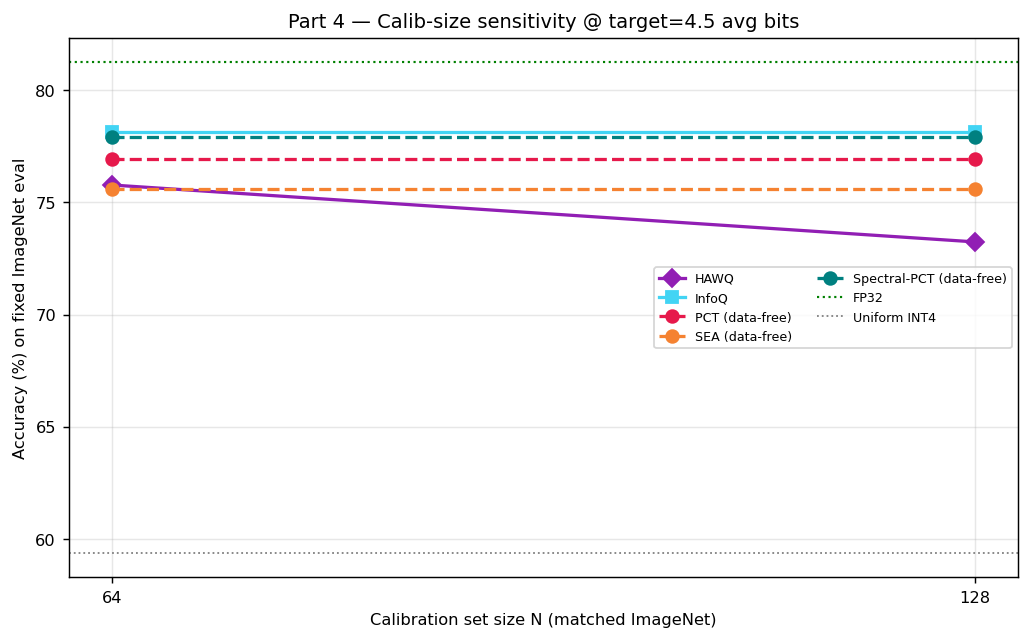

PART 4 HEADLINE — calibration robustness
FP32 accuracy (fixed eval):     81.25%
Uniform INT4 (fixed eval):  59.38%
Target avg bits:                4.5

HAWQ:
  A matched:   acc=73.24%  recovery=+13.87pp  vsFP32=-8.01pp
  C domain:    acc=74.61%  recovery=+15.23pp  (Δ recovery vs A: -1.37pp)
  D noise:     acc=74.80%  recovery=+15.43pp  (Δ recovery vs A: -1.56pp)

INFOQ:
  A matched:   acc=77.93%  recovery=+18.55pp  vsFP32=-3.32pp
  C domain:    acc=78.12%  recovery=+18.75pp  (Δ recovery vs A: -0.20pp)
  D noise:     acc=78.12%  recovery=+18.75pp  (Δ recovery vs A: -0.20pp)

DATA-FREE (identical across A/B/C/D by construction):
  pct             acc=76.95%  recovery=+17.58pp  vsFP32=-4.30pp
  sea             acc=75.59%  recovery=+16.21pp  vsFP32=-5.66pp
  spectral_pct    acc=77.93%  recovery=+18.55pp  vsFP32=-3.32pp

──────────────────────────────────────────────────────────────────────────────
HAWQ's accuracy recovery drops from +13.87pp (matched) to +15.23pp (domain-mismatched), a -1.

In [ ]:
import matplotlib.ticker
# ── Part 4: plots + headline numbers ──────────────────────────────────────────

if not RUN_PART4 or len(p4_df) == 0:
    if RUN_PART4 and PART4_RESULTS_CSV.exists():
        p4_df = pd.read_csv(PART4_RESULTS_CSV)
        print(f'Reloaded {PART4_RESULTS_CSV.name}')
    else:
        print('No Part 4 results to plot.')
        p4_df = pd.DataFrame()

if len(p4_df):
    METHOD_STYLE = {
        'hawq':          dict(color='#911eb4', marker='D', ls='-',  label='HAWQ'),
        'infoq':         dict(color='#42d4f4', marker='s', ls='-',  label='InfoQ'),
        'pct':           dict(color='#e6194b', marker='o', ls='--', label='PCT (data-free)'),
        'sea':           dict(color='#f58231', marker='o', ls='--', label='SEA (data-free)'),
        'spectral_pct':  dict(color='#008080', marker='o', ls='--', label='Spectral-PCT (data-free)'),
    }
    MISMATCH_ORDER = ['A_matched', 'B_sample_var', 'C_domain', 'D_noise']

    # ── Figure 1: mismatch conditions A→D ──────────────────────────────────────
    mism = p4_df[p4_df['kind'] == 'mismatch'].copy()
    if len(mism):
        fig, ax = plt.subplots(figsize=(9, 5))
        x_pos = np.arange(len(MISMATCH_ORDER))
        width = 0.15
        methods_plot = PART4_DATA_REQ + PART4_DATA_FREE
        for i, method in enumerate(methods_plot):
            ys = []
            for cond in MISMATCH_ORDER:
                sub = mism[(mism['condition'] == cond) & (mism['method'] == method)]
                ys.append(float(sub['acc_pp'].iloc[0]) if len(sub) else np.nan)
            offset = (i - (len(methods_plot) - 1) / 2) * width
            st = METHOD_STYLE[method]
            ax.bar(x_pos + offset, ys, width=width, color=st['color'],
                   label=st['label'], edgecolor='black', linewidth=0.4)
            # Flat-line overlay for data-free
            if method in PART4_DATA_FREE and np.isfinite(ys).all():
                ax.plot(x_pos, ys, color=st['color'], ls='--', lw=1.2, alpha=0.7)

        ax.axhline(p4_fp32_acc * 100, color='green', ls=':', lw=1.2, label='FP32')
        ax.axhline(p4_uni_acc * 100, color='gray', ls=':', lw=1.0, label=f'Uniform INT{PART4_UNIFORM_BITS}')
        ax.set_xticks(x_pos)
        ax.set_xticklabels([
            'A\nmatched\nImageNet',
            'B\nsample-var\nImageNet',
            'C\ndomain\nCIFAR-100',
            'D\nnoise\nGaussian',
        ], fontsize=8)
        ax.set_ylabel('Accuracy (%) on fixed ImageNet eval')
        ax.set_title(f'Part 4 — Calib mismatch @ target={PART4_TARGET_AVG_BITS} avg bits '
                     f'(ResNet-18 / ImageNet)')
        ax.legend(fontsize=7, ncol=3, loc='lower left')
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        fig.savefig(PART4_DIR / 'part4_mismatch_abcd.png', bbox_inches='tight')
        plt.show()

    # ── Figure 2: calib-size sweep (matched distribution) ─────────────────────
    sizes = p4_df[p4_df['kind'] == 'size'].copy()
    if len(sizes):
        fig, ax = plt.subplots(figsize=(8, 5))
        for method in PART4_DATA_REQ + PART4_DATA_FREE:
            sub = sizes[sizes['method'] == method].sort_values('calib_n')
            if len(sub) == 0:
                continue
            st = METHOD_STYLE[method]
            ax.plot(sub['calib_n'], sub['acc_pp'],
                    color=st['color'], marker=st['marker'], ls=st['ls'],
                    lw=1.8, markersize=7, label=st['label'])
        ax.axhline(p4_fp32_acc * 100, color='green', ls=':', lw=1.2, label='FP32')
        ax.axhline(p4_uni_acc * 100, color='gray', ls=':', lw=1.0, label=f'Uniform INT{PART4_UNIFORM_BITS}')
        ax.set_xscale('log', base=2)
        ax.set_xticks(PART4_CALIB_SIZES)
        ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
        ax.set_xlabel('Calibration set size N (matched ImageNet)')
        ax.set_ylabel('Accuracy (%) on fixed ImageNet eval')
        ax.set_title(f'Part 4 — Calib-size sensitivity @ target={PART4_TARGET_AVG_BITS} avg bits')
        ax.legend(fontsize=7, ncol=2)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        fig.savefig(PART4_DIR / 'part4_calib_size_sweep.png', bbox_inches='tight')
        plt.show()

    # ── Headline numbers ───────────────────────────────────────────────────────
    # Gate mismatch claims on score-level convergence (Part 4.5)
    _hawq_ok = globals().get('hawq_sanity_ok')
    if _hawq_ok is False:
        print('\n⚠ HAWQ sanity FAILED — suppressing calibration-mismatch headline. See Part 4.5.')
    elif _hawq_ok is None:
        print('\n⚠ Part 4.5 not run — HAWQ mismatch headline suppressed.')

    print('=' * 78)
    print('PART 4 HEADLINE — calibration robustness')
    print('=' * 78)
    print(f'FP32 accuracy (fixed eval):     {p4_fp32_acc*100:.2f}%')
    print(f'Uniform INT{PART4_UNIFORM_BITS} (fixed eval):  {p4_uni_acc*100:.2f}%')
    print(f'Target avg bits:                {PART4_TARGET_AVG_BITS}')

    def _row(cond, method):
        sub = p4_df[(p4_df['condition'] == cond) & (p4_df['method'] == method)]
        return sub.iloc[0] if len(sub) else None

    for method in PART4_DATA_REQ:
        a = _row('A_matched', method)
        c = _row('C_domain', method)
        d = _row('D_noise', method)
        if a is None:
            continue
        print(f'\n{method.upper()}:')
        print(f'  A matched:   acc={a["acc_pp"]:.2f}%  recovery={a["recovery_vs_uniform_pp"]:+.2f}pp  '
              f'vsFP32={a["vs_fp32_pp"]:+.2f}pp')
        if c is not None:
            drop = a['recovery_vs_uniform_pp'] - c['recovery_vs_uniform_pp']
            print(f'  C domain:    acc={c["acc_pp"]:.2f}%  recovery={c["recovery_vs_uniform_pp"]:+.2f}pp  '
                  f'(Δ recovery vs A: {drop:+.2f}pp)')
        if d is not None:
            drop = a['recovery_vs_uniform_pp'] - d['recovery_vs_uniform_pp']
            print(f'  D noise:     acc={d["acc_pp"]:.2f}%  recovery={d["recovery_vs_uniform_pp"]:+.2f}pp  '
                  f'(Δ recovery vs A: {drop:+.2f}pp)')

    print('\nDATA-FREE (identical across A/B/C/D by construction):')
    for method in PART4_DATA_FREE:
        r = _row('A_matched', method)
        if r is not None:
            print(f'  {method:14s}  acc={r["acc_pp"]:.2f}%  recovery={r["recovery_vs_uniform_pp"]:+.2f}pp  '
                  f'vsFP32={r["vs_fp32_pp"]:+.2f}pp')

    # Punchy one-liner for the paper
    hawq_a = _row('A_matched', 'hawq')
    hawq_c = _row('C_domain', 'hawq')
    best_free = max(
        (_row('A_matched', m) for m in PART4_DATA_FREE if _row('A_matched', m) is not None),
        key=lambda r: r['recovery_vs_uniform_pp'],
        default=None,
    )
    if _hawq_ok is True and hawq_a is not None and hawq_c is not None and best_free is not None:
        drop = hawq_a['recovery_vs_uniform_pp'] - hawq_c['recovery_vs_uniform_pp']
        print('\n' + '─' * 78)
        print(
            f'HAWQ\'s accuracy recovery drops from {hawq_a["recovery_vs_uniform_pp"]:+.2f}pp (matched) '
            f'to {hawq_c["recovery_vs_uniform_pp"]:+.2f}pp (domain-mismatched), '
            f'a {drop:+.2f}pp degradation — while our data-free methods maintain identical '
            f'{best_free["recovery_vs_uniform_pp"]:+.2f}pp recovery regardless of calibration '
            f'condition, since no calibration data is used.'
        )
        print('─' * 78)

    print(f'\nFigures → {PART4_DIR}')


# Part 5 — Summary tables: bit-budget accuracy × memory × allocation cost

Built from existing CSVs (no recompute):

| Source | Path |
|---|---|
| Bit-budget **mixed** accuracy | `results/proportional_mp_allocator/all_allocator_results.csv` |
| True **uniform** accuracy (all layers same bit-width) | layer-importance `baseline_int{B}` rows (CIFAR-100 / ImageNet) |
| Allocation GFLOPs | `results/mixed_precision_cost_benchmark/part1_allocation_flops.csv` |

### Baseline choice (important)

The proportional allocator CSVs **do not** store vision `uniform_intX` rows — only `greedy_random` / `random` at the same target budget.

Those answer a **different** question (*does ranking quality matter?*). For *why mixed precision at all?*, the standard baseline is **true uniform** quantization (every layer at bit-width *B*).

| Target avg bits | Uniform baseline used | Exact avg match? |
|---|---|---|
| 2.0 / 3.0 / 4.0 | `baseline_int{B}` (all layers B-bit) | **Yes** (avg = B) |
| 2.5 / 3.5 | `baseline_int{floor(T)}` (INT2 / INT3) | **No** — integer uniform cannot hit .5; floor is the memory-stricter compare. Ceiling INT also shown in the detail table. |

`greedy_random` is kept as a **secondary** column only (ranking-quality control), not labeled as uniform.

**Memory (weight-only)** ≈ `n_params × bits / 8`. Savings vs FP32 = `1 − bits/32`.


Proportional vision methods include true uniform_int*/baseline_int*? False
  (vision methods sample: ['entropy', 'fp32', 'greedy_random', 'infoq', 'nsds', 'old', 'pct', 'random', 'sea', 'spectral_pct', 'spectral_top10'] ...)
  → Using layer-importance baseline_int{B} for the uniform column.
  → greedy_random kept only as secondary "random @ same budget" control.\n
Table: True Uniform vs Mixed Precision (bit-budget mixed + baseline_int uniform)


,Arch/Dataset,Target avg bits,Uniform bits,Uniform exact @ target,Uniform acc,Mixed precision acc (best),Best method,Gap vs true uniform (pp),Mixed memory (MB),Uniform memory (MB),FP32 memory (MB),Memory saved vs FP32 (%)
2,ResNet ImageNet,3.5,3,False,0.70,68.55,PCT,67.85,5.13,4.38,46.72,89.02
3,ResNet ImageNet,4.0,4,True,60.10,70.70,PCT,10.60,5.85,5.84,46.72,87.47
6,ViT ImageNet,3.5,3,False,41.55,87.11,SEA,45.56,28.60,24.40,260.24,89.01
7,ViT ImageNet,4.0,4,True,92.15,88.28,SEA,-3.87,32.66,32.53,260.24,87.45
10,ResNet CIFAR-100,3.5,3,False,68.42,74.28,Spectral-PCT,5.86,4.92,4.20,44.84,89.02


Saved headline → /Users/nathan/Documents/bruh4/results/mixed_precision_cost_benchmark/part5_summary_tables/table_uniform_vs_mixed_bitbudget.csv
Saved all targets → /Users/nathan/Documents/bruh4/results/mixed_precision_cost_benchmark/part5_summary_tables/table_true_uniform_vs_mixed_all_targets.csv
\nSecondary control (ranking quality — NOT used as "uniform"):


,Arch/Dataset,Target avg bits,Random@budget acc,Gap vs random@budget (pp),Gap vs true uniform (pp)
2,ResNet ImageNet,3.5,19.92,48.63,67.85
3,ResNet ImageNet,4.0,58.20,12.50,10.60
6,ViT ImageNet,3.5,82.03,5.08,45.56
7,ViT ImageNet,4.0,79.88,8.40,-3.87
10,ResNet CIFAR-100,3.5,74.10,0.18,5.86


\nNote: ImageNet proportional mixed numbers are smoke-eval (N=512);
      ImageNet baseline_int* are from the layer-importance CSV (larger eval).
      CIFAR-100 FP32 matches across sources (same eval) — preferred for claims.
\nHalf-bit targets — floor uniform (primary) vs ceiling uniform (context):


,Arch/Dataset,Target avg bits,Uniform bits,Uniform acc,Uniform ceil bits,Uniform ceil acc,Mixed precision acc (best),Gap vs true uniform (pp)
0,ResNet ImageNet,2.5,2,0.05,3.0,0.70,0.39,0.34
2,ResNet ImageNet,3.5,3,0.70,4.0,60.10,68.55,67.85
4,ViT ImageNet,2.5,2,0.05,3.0,41.55,0.59,0.54
6,ViT ImageNet,3.5,3,41.55,4.0,92.15,87.11,45.56
8,ResNet CIFAR-100,2.5,2,1.02,3.0,68.42,5.73,4.71
10,ResNet CIFAR-100,3.5,3,68.42,4.0,74.25,74.28,5.86
12,ViT CIFAR-100,2.5,2,3.37,3.0,52.72,21.89,18.52
14,ViT CIFAR-100,3.5,3,52.72,4.0,62.76,62.49,9.77


\n================================================================================================
Table: Allocation Cost (Part 1 GFLOPs)


,Method,Type,GFLOPs to compute ranking,Time equivalent
0,HAWQ,data-required,"7,499 – 274,482",scales with calibration set × layers
1,InfoQ,data-required,"393 – 77,845",scales with calibration set × layers
2,CLADO / BMPQ,data-required,"54 – 81,797",scales with calibration set × layers
3,PCT / SEA / Spectral-PCT,data-free,0,"instant, constant regardless of model size"


Saved → /Users/nathan/Documents/bruh4/results/mixed_precision_cost_benchmark/part5_summary_tables/table_allocation_cost.csv


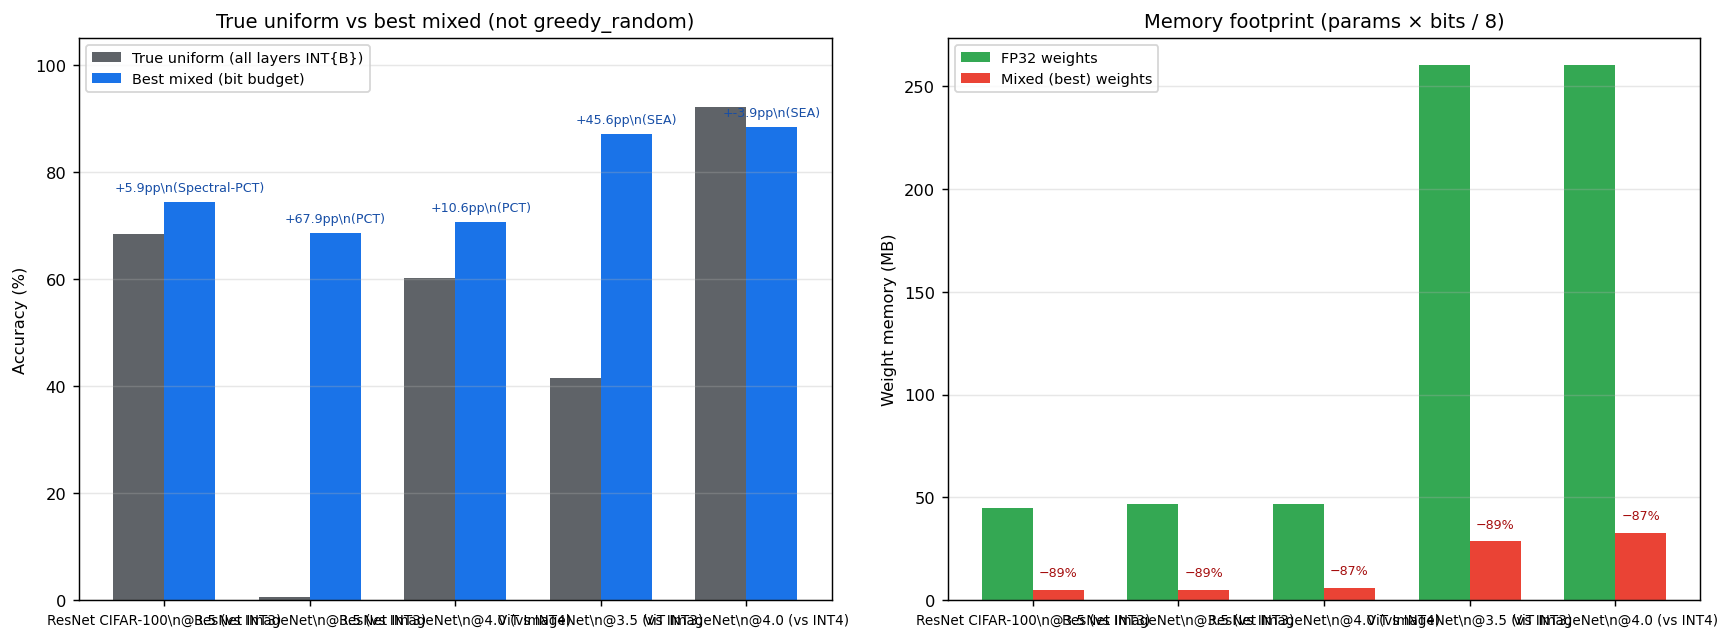

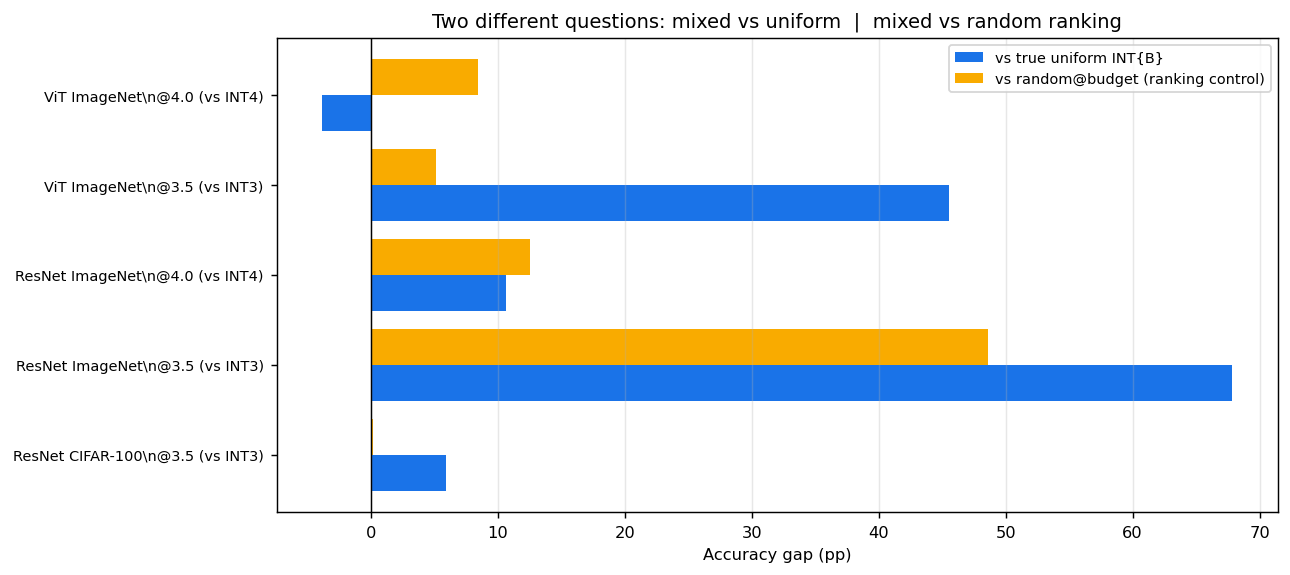

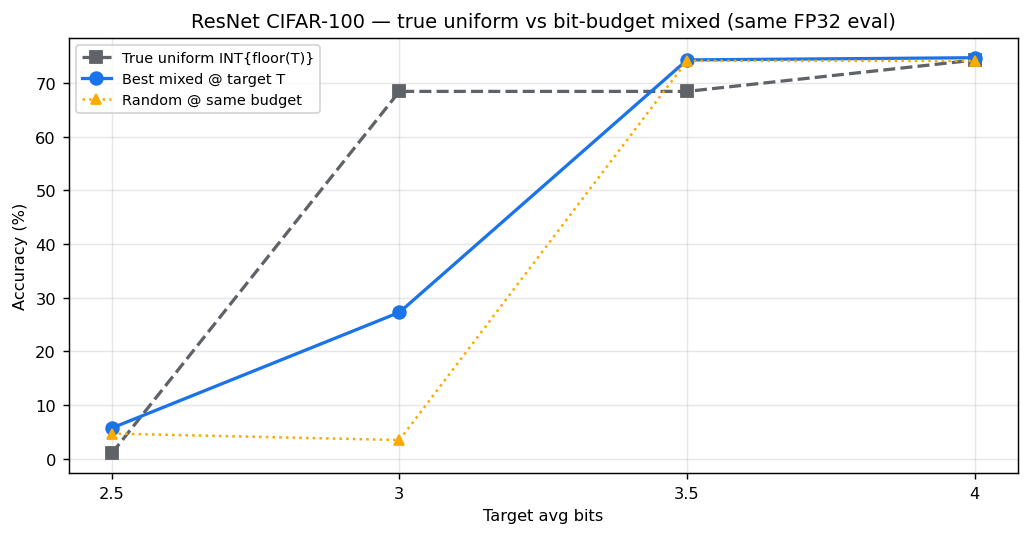

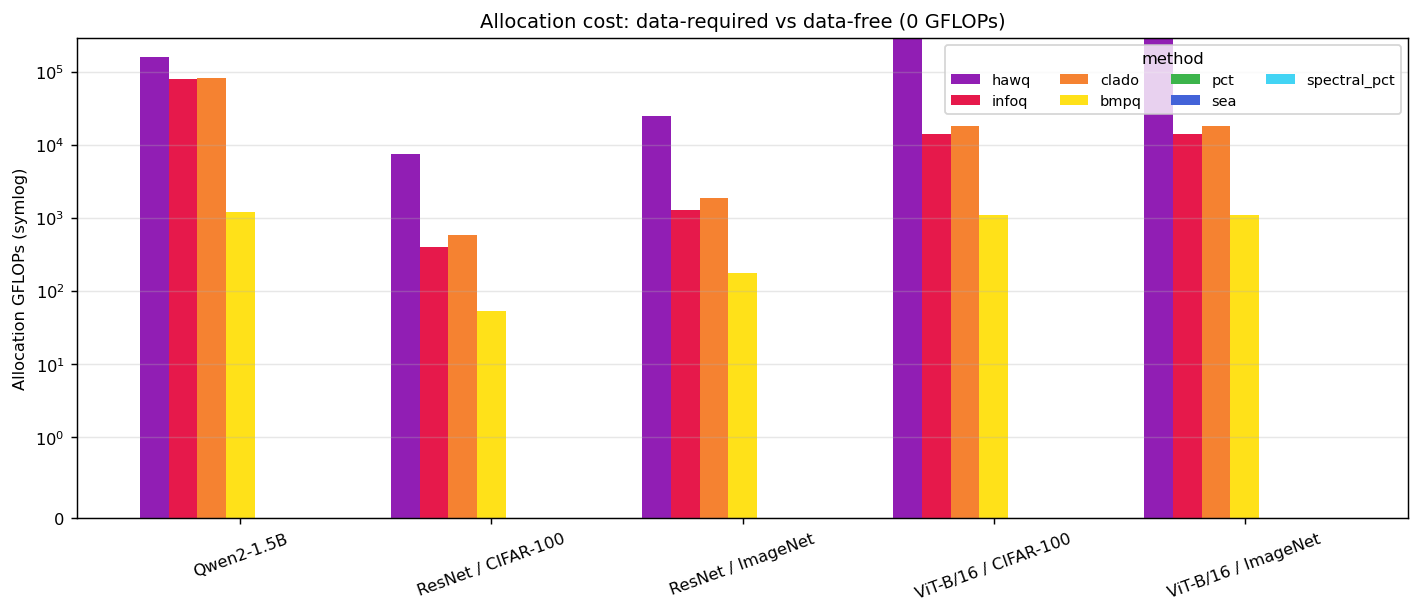

\nAll Part 5 outputs → /Users/nathan/Documents/bruh4/results/mixed_precision_cost_benchmark/part5_summary_tables


In [5]:
# ── Part 5: True uniform vs Mixed (bit budget) + Allocation cost ─────────────
from IPython.display import display

ALLOC_CSV = ROOT / 'results' / 'proportional_mp_allocator' / 'all_allocator_results.csv'
FLOPS_CSV = OUT_DIR / 'part1_allocation_flops.csv'
PART5_DIR = OUT_DIR / 'part5_summary_tables'
PART5_DIR.mkdir(parents=True, exist_ok=True)

# True all-layers uniform (NOT greedy_random)
UNIFORM_CSV = {
    'imagenet_resnet': ROOT / 'results' / 'imagenet_layer_importance_benchmark' / 'resnet_imagenet_benchmark_results.csv',
    'imagenet_vit': ROOT / 'results' / 'imagenet_layer_importance_benchmark' / 'vit_imagenet_benchmark_results.csv',
    'cifar100_resnet': ROOT / 'results' / 'cifar100_layer_importance_benchmark' / 'resnet_cifar100_benchmark_results.csv',
    'cifar100_vit': ROOT / 'results' / 'cifar100_layer_importance_benchmark' / 'vit_cifar100_benchmark_results.csv',
}

BENCH_LABEL = {
    'imagenet_resnet': 'ResNet ImageNet',
    'imagenet_vit': 'ViT ImageNet',
    'cifar100_resnet': 'ResNet CIFAR-100',
    'cifar100_vit': 'ViT CIFAR-100',
}
BENCH_TO_FLOPS = {
    'imagenet_resnet': 'rn_inet',
    'imagenet_vit': 'vit_inet',
    'cifar100_resnet': 'rn_c100',
    'cifar100_vit': 'vit_c100',
}
# Full target grid the user asked about
TARGETS = [2.5, 3.0, 3.5, 4.0]
# Paper-style headline subset
HEADLINE = {
    ('imagenet_resnet', 3.5), ('imagenet_resnet', 4.0),
    ('imagenet_vit', 3.5), ('imagenet_vit', 4.0),
    ('cifar100_resnet', 3.5),
}
EXCLUDE_FROM_BEST = {
    'fp32', 'fp16', 'greedy_random', 'random',
    'uniform_mixed', 'uniform_int2', 'uniform_int3', 'uniform_int4', 'uniform_int8',
}
METHOD_PRETTY = {
    'pct': 'PCT', 'sea': 'SEA', 'spectral_pct': 'Spectral-PCT',
    'spectral_top10': 'Spectral-Top10', 'entropy': 'Entropy',
    'nsds': 'NSDS', 'infoq': 'InfoQ', 'hawq': 'HAWQ', 'old': 'OLD',
}


def weight_memory_mb(n_params_m: float, avg_bits: float) -> float:
    return float(n_params_m) * 1e6 * float(avg_bits) / 8.0 / 1e6


def uniform_bits_for_target(target: float) -> int:
    """Integer uniform bit-width for the primary 'why MP' baseline.
    Exact match when target is integer; floor(target) when .5 (cannot hit exact avg).
    """
    if abs(target - round(target)) < 1e-9:
        return int(round(target))
    return int(np.floor(target))


def load_true_uniform(bench: str, bits: int) -> dict | None:
    path = UNIFORM_CSV.get(bench)
    if path is None or not path.exists():
        return None
    df = pd.read_csv(path)
    # Prefer baseline_int{B}; also accept uniform_int{B}
    for name in (f'baseline_int{bits}', f'uniform_int{bits}'):
        sub = df[df['method'].astype(str) == name]
        if len(sub):
            r = sub.iloc[0]
            return {
                'method': name,
                'bits': bits,
                'avg_bits': float(r.get('avg_bits', bits)),
                'accuracy': float(r['accuracy']),
                'exact_avg_match': abs(float(r.get('avg_bits', bits)) - bits) < 1e-9,
            }
    return None


alloc = pd.read_csv(ALLOC_CSV)
flops = pd.read_csv(FLOPS_CSV)
params_map = (
    flops.drop_duplicates('model_id').set_index('model_id')['n_params_m'].to_dict()
)

# Sanity: confirm proportional vision CSVs lack true uniform
vision_methods = set(
    alloc[alloc['benchmark'].isin(BENCH_LABEL)]['method'].astype(str).unique()
)
has_true_uni_in_alloc = any(m.startswith('uniform_int') or m.startswith('baseline_int')
                            for m in vision_methods)
print('Proportional vision methods include true uniform_int*/baseline_int*?',
      has_true_uni_in_alloc)
print('  (vision methods sample:', sorted(vision_methods)[:14], '...)')
if not has_true_uni_in_alloc:
    print('  → Using layer-importance baseline_int{B} for the uniform column.')
    print('  → greedy_random kept only as secondary "random @ same budget" control.\\n')

rows = []
for bench in BENCH_LABEL:
    for target in TARGETS:
        sub = alloc[(alloc['benchmark'] == bench) & (alloc['target_avg_bits'] == target)]
        if sub.empty:
            continue
        scored = sub[~sub['method'].isin(EXCLUDE_FROM_BEST)].copy()
        if scored.empty or scored['accuracy'].isna().all():
            continue
        best = scored.loc[scored['accuracy'].idxmax()]

        uni_bits = uniform_bits_for_target(target)
        uni = load_true_uniform(bench, uni_bits)
        uni_ceil = None
        if abs(target - uni_bits) > 1e-9:
            uni_ceil = load_true_uniform(bench, uni_bits + 1)

        gr = sub[sub['method'] == 'greedy_random']
        if gr.empty:
            gr = sub[sub['method'] == 'random']
        gr_acc = float(gr.iloc[0]['accuracy']) if len(gr) else float('nan')
        gr_bits = float(gr.iloc[0]['avg_bits']) if len(gr) else float('nan')

        n_params_m = float(params_map[BENCH_TO_FLOPS[bench]])
        mix_bits = float(best['avg_bits'])
        mix_acc = float(best['accuracy'])
        fp32_mb = weight_memory_mb(n_params_m, 32.0)
        mix_mb = weight_memory_mb(n_params_m, mix_bits)

        if uni is None:
            print(f'WARNING: no true uniform INT{uni_bits} for {bench}')
            continue

        uni_mb = weight_memory_mb(n_params_m, uni['avg_bits'])
        gap_vs_uni = (mix_acc - uni['accuracy']) * 100.0
        exact = abs(target - uni['avg_bits']) < 1e-9

        rows.append({
            'Arch/Dataset': BENCH_LABEL[bench],
            'Target avg bits': target,
            'Uniform bits': uni_bits,
            'Uniform avg bits': uni['avg_bits'],
            'Uniform exact @ target': exact,
            'Uniform source': uni['method'],
            'Uniform acc': uni['accuracy'] * 100.0,
            'Mixed precision acc (best)': mix_acc * 100.0,
            'Best method': METHOD_PRETTY.get(best['method'], best['method']),
            'Gap vs true uniform (pp)': gap_vs_uni,
            'Mixed avg bits': mix_bits,
            'FP32 memory (MB)': fp32_mb,
            'Uniform memory (MB)': uni_mb,
            'Mixed memory (MB)': mix_mb,
            'Memory saved vs FP32 (%)': (1.0 - mix_bits / 32.0) * 100.0,
            # Secondary: ranking-quality control (NOT the uniform baseline)
            'Random@budget acc': gr_acc * 100.0 if gr_acc == gr_acc else np.nan,
            'Gap vs random@budget (pp)': (mix_acc - gr_acc) * 100.0 if gr_acc == gr_acc else np.nan,
            'Uniform ceil bits': (uni_bits + 1) if uni_ceil else np.nan,
            'Uniform ceil acc': (uni_ceil['accuracy'] * 100.0) if uni_ceil else np.nan,
            'benchmark': bench,
            'headline': (bench, target) in HEADLINE,
        })

t_all = pd.DataFrame(rows)
t_all_out = PART5_DIR / 'table_true_uniform_vs_mixed_all_targets.csv'
t_all.to_csv(t_all_out, index=False)

t1 = t_all[t_all['headline']].copy()
t1_out = PART5_DIR / 'table_uniform_vs_mixed_bitbudget.csv'
t1.to_csv(t1_out, index=False)

print('=' * 96)
print('Table: True Uniform vs Mixed Precision (bit-budget mixed + baseline_int uniform)')
print('=' * 96)
disp_cols = [
    'Arch/Dataset', 'Target avg bits', 'Uniform bits', 'Uniform exact @ target',
    'Uniform acc', 'Mixed precision acc (best)', 'Best method',
    'Gap vs true uniform (pp)', 'Mixed memory (MB)', 'Uniform memory (MB)',
    'FP32 memory (MB)', 'Memory saved vs FP32 (%)',
]
disp1 = t1[disp_cols].copy()
for c in ['Uniform acc', 'Mixed precision acc (best)', 'Gap vs true uniform (pp)',
          'Mixed memory (MB)', 'Uniform memory (MB)', 'FP32 memory (MB)',
          'Memory saved vs FP32 (%)']:
    disp1[c] = disp1[c].map(lambda x: f'{x:.2f}')
display(disp1)
print(f'Saved headline → {t1_out}')
print(f'Saved all targets → {t_all_out}')

print('\\nSecondary control (ranking quality — NOT used as "uniform"):')
disp_r = t1[['Arch/Dataset', 'Target avg bits', 'Random@budget acc',
             'Gap vs random@budget (pp)', 'Gap vs true uniform (pp)']].copy()
for c in ['Random@budget acc', 'Gap vs random@budget (pp)', 'Gap vs true uniform (pp)']:
    disp_r[c] = disp_r[c].map(lambda x: f'{x:.2f}')
display(disp_r)

print('\\nNote: ImageNet proportional mixed numbers are smoke-eval (N=512);')
print('      ImageNet baseline_int* are from the layer-importance CSV (larger eval).')
print('      CIFAR-100 FP32 matches across sources (same eval) — preferred for claims.')

# Half-bit targets: also show ceiling uniform for context
half = t_all[~t_all['Uniform exact @ target']].copy()
if len(half):
    print('\\nHalf-bit targets — floor uniform (primary) vs ceiling uniform (context):')
    dhalf = half[['Arch/Dataset', 'Target avg bits', 'Uniform bits', 'Uniform acc',
                  'Uniform ceil bits', 'Uniform ceil acc',
                  'Mixed precision acc (best)', 'Gap vs true uniform (pp)']].copy()
    display(dhalf.round(2))

# ── Table 2: Allocation Cost ──────────────────────────────────────────────────
cost_groups = [
    ('HAWQ', ['hawq'], 'data-required'),
    ('InfoQ', ['infoq'], 'data-required'),
    ('CLADO / BMPQ', ['clado', 'bmpq'], 'data-required'),
    ('PCT / SEA / Spectral-PCT', ['pct', 'sea', 'spectral_pct'], 'data-free'),
]
cost_rows = []
for label, methods, kind in cost_groups:
    sub = flops[flops['method'].isin(methods)]
    g = sub['allocation_gflops']
    cost_rows.append({
        'Method': label,
        'Type': kind,
        'GFLOPs min': float(g.min()),
        'GFLOPs max': float(g.max()),
        'GFLOPs to compute ranking': (
            '0' if g.max() == 0 else f'{g.min():,.0f} – {g.max():,.0f}'
        ),
        'Time equivalent': (
            'instant, constant regardless of model size'
            if kind == 'data-free'
            else 'scales with calibration set × layers'
        ),
    })
t2 = pd.DataFrame(cost_rows)
t2_out = PART5_DIR / 'table_allocation_cost.csv'
t2.to_csv(t2_out, index=False)

print('\\n' + '=' * 96)
print('Table: Allocation Cost (Part 1 GFLOPs)')
print('=' * 96)
display(t2[['Method', 'Type', 'GFLOPs to compute ranking', 'Time equivalent']])
print(f'Saved → {t2_out}')

cost_detail = flops[flops['method'].isin(
    ['hawq', 'infoq', 'clado', 'bmpq', 'pct', 'sea', 'spectral_pct']
)].copy()
cost_detail['method_label'] = cost_detail['method'].map(
    lambda m: METHOD_PRETTY.get(m, m.upper())
)
cost_detail.to_csv(PART5_DIR / 'allocation_gflops_by_arch.csv', index=False)

# ── Plots ─────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

plot_df = t1.sort_values(['Arch/Dataset', 'Target avg bits']).reset_index(drop=True)
labels = [f"{r['Arch/Dataset']}\\n@{r['Target avg bits']} (vs INT{int(r['Uniform bits'])})"
          for _, r in plot_df.iterrows()]
x = np.arange(len(plot_df))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

ax = axes[0]
ax.bar(x - w / 2, plot_df['Uniform acc'], w,
       label='True uniform (all layers INT{B})', color='#5f6368')
ax.bar(x + w / 2, plot_df['Mixed precision acc (best)'], w,
       label='Best mixed (bit budget)', color='#1a73e8')
for i, r in plot_df.iterrows():
    ax.text(i + w / 2, r['Mixed precision acc (best)'] + 1.5,
            f"+{r['Gap vs true uniform (pp)']:.1f}pp\\n({r['Best method']})",
            ha='center', va='bottom', fontsize=7, color='#174ea6')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7.5)
ax.set_ylabel('Accuracy (%)')
ax.set_title('True uniform vs best mixed (not greedy_random)')
ax.legend(fontsize=8, loc='upper left')
ymax = plot_df[['Uniform acc', 'Mixed precision acc (best)']].max().max()
ax.set_ylim(0, min(105, ymax + 20))
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(x - w / 2, plot_df['FP32 memory (MB)'], w, label='FP32 weights', color='#34a853')
ax.bar(x + w / 2, plot_df['Mixed memory (MB)'], w, label='Mixed (best) weights', color='#ea4335')
for i, r in plot_df.iterrows():
    ax.text(i + w / 2, r['Mixed memory (MB)'] + max(plot_df['FP32 memory (MB)']) * 0.02,
            f"−{r['Memory saved vs FP32 (%)']:.0f}%",
            ha='center', va='bottom', fontsize=7, color='#a50e0e')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7.5)
ax.set_ylabel('Weight memory (MB)')
ax.set_title('Memory footprint (params × bits / 8)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig(PART5_DIR / 'uniform_vs_mixed_acc_memory.png', bbox_inches='tight', dpi=140)
plt.show()

# Gap plot: true uniform vs random@budget
fig, ax = plt.subplots(figsize=(10, 4.5))
y = np.arange(len(plot_df))
ax.barh(y - 0.2, plot_df['Gap vs true uniform (pp)'], 0.4,
        label='vs true uniform INT{B}', color='#1a73e8')
ax.barh(y + 0.2, plot_df['Gap vs random@budget (pp)'], 0.4,
        label='vs random@budget (ranking control)', color='#f9ab00')
ax.axvline(0, color='k', lw=0.8)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Accuracy gap (pp)')
ax.set_title('Two different questions: mixed vs uniform  |  mixed vs random ranking')
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(PART5_DIR / 'gap_true_uniform_vs_random.png', bbox_inches='tight', dpi=140)
plt.show()

# All-target heatmap-style bars for CIFAR (cleanest same-eval pair)
cifar = t_all[t_all['benchmark'] == 'cifar100_resnet'].sort_values('Target avg bits')
if len(cifar):
    fig, ax = plt.subplots(figsize=(8, 4.2))
    xx = np.arange(len(cifar))
    ax.plot(xx, cifar['Uniform acc'], 's--', color='#5f6368', lw=1.8, ms=7,
            label='True uniform INT{floor(T)}')
    ax.plot(xx, cifar['Mixed precision acc (best)'], 'o-', color='#1a73e8', lw=1.8, ms=7,
            label='Best mixed @ target T')
    ax.plot(xx, cifar['Random@budget acc'], '^:', color='#f9ab00', lw=1.4, ms=6,
            label='Random @ same budget')
    ax.set_xticks(xx)
    ax.set_xticklabels([f'{t:g}' for t in cifar['Target avg bits']])
    ax.set_xlabel('Target avg bits')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('ResNet CIFAR-100 — true uniform vs bit-budget mixed (same FP32 eval)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(PART5_DIR / 'cifar100_resnet_uniform_vs_mixed_curve.png',
                bbox_inches='tight', dpi=140)
    plt.show()

# Allocation GFLOPs
pivot = cost_detail.pivot_table(
    index='model_label', columns='method', values='allocation_gflops', aggfunc='max'
)
method_order = [m for m in ['hawq', 'infoq', 'clado', 'bmpq', 'pct', 'sea', 'spectral_pct']
                if m in pivot.columns]
pivot = pivot[method_order]
fig, ax = plt.subplots(figsize=(11, 4.8))
pivot.plot(kind='bar', ax=ax, width=0.8,
           color=['#911eb4', '#e6194b', '#f58231', '#ffe119', '#3cb44b', '#4363d8', '#42d4f4'])
ax.set_yscale('symlog', linthresh=1.0)
ax.set_ylabel('Allocation GFLOPs (symlog)')
ax.set_xlabel('')
ax.set_title('Allocation cost: data-required vs data-free (0 GFLOPs)')
ax.legend(title='method', fontsize=8, ncol=4)
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(PART5_DIR / 'allocation_gflops_by_arch.png', bbox_inches='tight', dpi=140)
plt.show()

print(f'\\nAll Part 5 outputs → {PART5_DIR}')
